In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from data_processing.functions.klines_dataloader import KlinesDataLoader
from data_processing.functions.transform_indicators import transform_indicators_df
from data_processing.functions.rolling_z_score_clip import rolling_z_score_clip_df
from data_processing.functions.stream_indicators import stream_TA_lib

In [2]:
ALL_SYMBOLS = ['BTCUSDT', 'DOGEUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT']

INTERVAL = 240

DATA_PATH = f"data/klines_data/crypto_{INTERVAL}m_bybit_TEST.parquet"

loader = KlinesDataLoader(symbols=ALL_SYMBOLS)

ohlcv_data = loader.load_data(
    download_path=DATA_PATH,
    analyse_data=True,
    cleaning=True
)

			Статистика без фильтрации

Количество строк: 51672
Количество столбцов: 8
Количество пропущенных значений: 0

Название столбцов: timestamp, open, high, low, close, volume, turnover, symbol
Название активов: BTCUSDT, DOGEUSDT, ETHUSDT, SOLUSDT, XRPUSDT

Длина временного ряда актива BTCUSDT: 10549
Длина временного ряда актива DOGEUSDT: 10209
Длина временного ряда актива ETHUSDT: 10549
Длина временного ряда актива SOLUSDT: 9903
Длина временного ряда актива XRPUSDT: 10462

Временные рамки ряда каждого актива:
BTCUSDT: 2021-07-05 12:00:00+00:00 - 2026-04-28 12:00:00+00:00
DOGEUSDT: 2021-08-31 04:00:00+00:00 - 2026-04-28 12:00:00+00:00
ETHUSDT: 2021-07-05 12:00:00+00:00 - 2026-04-28 12:00:00+00:00
SOLUSDT: 2021-10-21 04:00:00+00:00 - 2026-04-28 12:00:00+00:00
XRPUSDT: 2021-07-20 00:00:00+00:00 - 2026-04-28 12:00:00+00:00


			Статистика после фильтрации (удаление столбца 'turnover' и выравнивание временных рядов по активам)

Количество строк: 49515
Количество столбцов: 7
Количество пропущ

In [3]:
# Legacy convenience column for plotting/debugging only.
# Важно: эта колонка НЕ используется как target для feature selection/correlation.
# Target'ы ниже строятся отдельно, строго внутри train/symbol через add_targets_grouped().
ohlcv_data["future_close_price"] = (
    ohlcv_data
    .groupby("symbol")["close"]
    .shift(-1)
)

ohlcv_data = (
    ohlcv_data
    .sort_values(["symbol", "timestamp"])
    .reset_index(drop=True)
)

meta_cols = [
    "timestamp",
    "symbol",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "future_close_price",
]

display(ohlcv_data.head())
print(f"Мета-колонки: {meta_cols}")
print("OHLCV shape:", ohlcv_data.shape)
print(ohlcv_data["timestamp"].min(), "->", ohlcv_data["timestamp"].max())
display(ohlcv_data["symbol"].value_counts())


,timestamp,open,high,low,close,volume,symbol,future_close_price
0,2021-10-21 04:00:00+00:00,65070.85,65247.18,64176.50,65125.25,132.123083,BTCUSDT,64852.19
1,2021-10-21 08:00:00+00:00,65125.25,66645.39,64259.27,64852.19,175.523964,BTCUSDT,63029.47
2,2021-10-21 12:00:00+00:00,64852.19,65622.69,62128.53,63029.47,226.384309,BTCUSDT,62828.36
3,2021-10-21 16:00:00+00:00,63029.47,63659.56,62463.64,62828.36,154.019616,BTCUSDT,62228.43
4,2021-10-21 20:00:00+00:00,62828.36,63103.99,62077.00,62228.43,150.886863,BTCUSDT,63215.35


Мета-колонки: ['timestamp', 'symbol', 'open', 'high', 'low', 'close', 'volume', 'future_close_price']
OHLCV shape: (49515, 8)
2021-10-21 04:00:00+00:00 -> 2026-04-28 12:00:00+00:00


symbol
BTCUSDT     9903
DOGEUSDT    9903
ETHUSDT     9903
SOLUSDT     9903
XRPUSDT     9903
Name: count, dtype: int64

In [4]:
# =====================================================================
# Chronological split aligned with the main pipeline
# =====================================================================
# Current protocol:
#   test = last TEST_BARS rows per symbol
#   val  = previous VAL_BARS rows per symbol
#   train = all earlier rows
#
# No date-based split is used here, because the main pipeline uses fixed
# chronological bar counts per symbol.

VAL_BARS = 2000
TEST_BARS = 2000
EMBARGO_BARS = 0


def add_chronological_phase_by_symbol(
    df: pd.DataFrame,
    val_bars: int = VAL_BARS,
    test_bars: int = TEST_BARS,
    embargo_bars: int = EMBARGO_BARS,
) -> pd.DataFrame:
    """
    Add phase ∈ {train, embargo, val, test} per symbol.

    This mirrors the main pipeline split:
        train = all rows before validation
        val   = previous VAL_BARS before test
        test  = last TEST_BARS
    """
    parts = []

    for sym, g in df.groupby("symbol", sort=False):
        g = g.sort_values("timestamp").reset_index(drop=True).copy()
        n = len(g)

        min_required = val_bars + test_bars + embargo_bars + 1
        if n < min_required:
            raise ValueError(
                f"Not enough rows for {sym}: n={n}, "
                f"required at least {min_required}"
            )

        test_start = n - test_bars
        val_start = test_start - val_bars
        train_end = val_start - embargo_bars

        g["phase"] = "train"

        if embargo_bars > 0:
            g.loc[train_end:val_start - 1, "phase"] = "embargo"

        g.loc[val_start:test_start - 1, "phase"] = "val"
        g.loc[test_start:n - 1, "phase"] = "test"

        parts.append(g)

    out = pd.concat(parts, ignore_index=True)
    return out.sort_values(["symbol", "timestamp"]).reset_index(drop=True)


def add_targets_grouped(
    df: pd.DataFrame,
    horizons=(1, 3, 5, 10, 24),
    price_col: str = "close",
) -> pd.DataFrame:
    """
    Add future log-return targets strictly within each symbol.

    If df is already filtered to phase == 'train', targets cannot cross
    the train/validation boundary. The last horizon rows per symbol are
    dropped by dropna().
    """
    parts = []

    for sym, g in df.groupby("symbol", sort=False):
        g = g.sort_values("timestamp").reset_index(drop=True).copy()

        for h in horizons:
            g[f"target_log_ret_horizon_{h}"] = np.log(
                g[price_col].shift(-h) / g[price_col]
            )

        parts.append(g)

    out = pd.concat(parts, ignore_index=True)
    return out.dropna().sort_values(["symbol", "timestamp"]).reset_index(drop=True)


def target_distribution_report(
    df: pd.DataFrame,
    horizons=(1, 3, 5, 10, 24),
    trade_cost: float = 0.0025,
    interval_minutes: int = 240,
) -> pd.DataFrame:
    """
    Cost-aware target distribution report.

    Useful for motivating horizon selection:
      - whether future moves are large enough relative to trading cost;
      - whether positive/negative outcomes are reasonably balanced;
      - whether horizon is too short/noisy or too long/delayed.
    """
    target_df = add_targets_grouped(df, horizons=horizons)

    one_side_cost_log = np.log(1.0 / (1.0 - trade_cost))
    round_trip_cost_log = np.log(1.0 / ((1.0 - trade_cost) ** 2))

    rows = []

    for h in horizons:
        target = f"target_log_ret_horizon_{h}"
        x = target_df[target].dropna()

        rows.append({
            "interval_minutes": interval_minutes,
            "horizon_bars": h,
            "horizon_hours": h * interval_minutes / 60.0,
            "n": len(x),
            "mean": x.mean(),
            "std": x.std(),
            "median": x.median(),
            "abs_mean": x.abs().mean(),
            "abs_median": x.abs().median(),
            "abs_p75": x.abs().quantile(0.75),
            "abs_p95": x.abs().quantile(0.95),
            "positive_ratio": (x > 0).mean(),
            "one_side_long_success_ratio": (x > one_side_cost_log).mean(),
            "one_side_short_success_ratio": (x < -one_side_cost_log).mean(),
            "abs_move_gt_one_side_cost_ratio": (x.abs() > one_side_cost_log).mean(),
            "abs_move_gt_round_trip_cost_ratio": (x.abs() > round_trip_cost_log).mean(),
            "abs_mean_to_one_side_cost": x.abs().mean() / one_side_cost_log,
            "std_to_one_side_cost": x.std() / one_side_cost_log,
        })

    return pd.DataFrame(rows)


ohlcv_data = add_chronological_phase_by_symbol(ohlcv_data)

train_df = ohlcv_data[ohlcv_data["phase"].eq("train")].copy()
val_df = ohlcv_data[ohlcv_data["phase"].eq("val")].copy()
test_df = ohlcv_data[ohlcv_data["phase"].eq("test")].copy()

split_summary = (
    ohlcv_data
    .groupby(["symbol", "phase"], observed=True)
    .agg(
        n_rows=("timestamp", "size"),
        timestamp_min=("timestamp", "min"),
        timestamp_max=("timestamp", "max"),
    )
    .reset_index()
    .sort_values(["symbol", "phase"])
)

display(split_summary)

print(f"Full rows:  {len(ohlcv_data)}")
print(f"Train rows: {len(train_df)}")
print(f"Val rows:   {len(val_df)}")
print(f"Test rows:  {len(test_df)}")


,symbol,phase,n_rows,timestamp_min,timestamp_max
0,BTCUSDT,test,2000,2025-05-30 08:00:00+00:00,2026-04-28 12:00:00+00:00
1,BTCUSDT,train,5903,2021-10-21 04:00:00+00:00,2024-06-30 20:00:00+00:00
2,BTCUSDT,val,2000,2024-07-01 00:00:00+00:00,2025-05-30 04:00:00+00:00
3,DOGEUSDT,test,2000,2025-05-30 08:00:00+00:00,2026-04-28 12:00:00+00:00
4,DOGEUSDT,train,5903,2021-10-21 04:00:00+00:00,2024-06-30 20:00:00+00:00
5,DOGEUSDT,val,2000,2024-07-01 00:00:00+00:00,2025-05-30 04:00:00+00:00
6,ETHUSDT,test,2000,2025-05-30 08:00:00+00:00,2026-04-28 12:00:00+00:00
7,ETHUSDT,train,5903,2021-10-21 04:00:00+00:00,2024-06-30 20:00:00+00:00
8,ETHUSDT,val,2000,2024-07-01 00:00:00+00:00,2025-05-30 04:00:00+00:00
9,SOLUSDT,test,2000,2025-05-30 08:00:00+00:00,2026-04-28 12:00:00+00:00


Full rows:  49515
Train rows: 29515
Val rows:   10000
Test rows:  10000


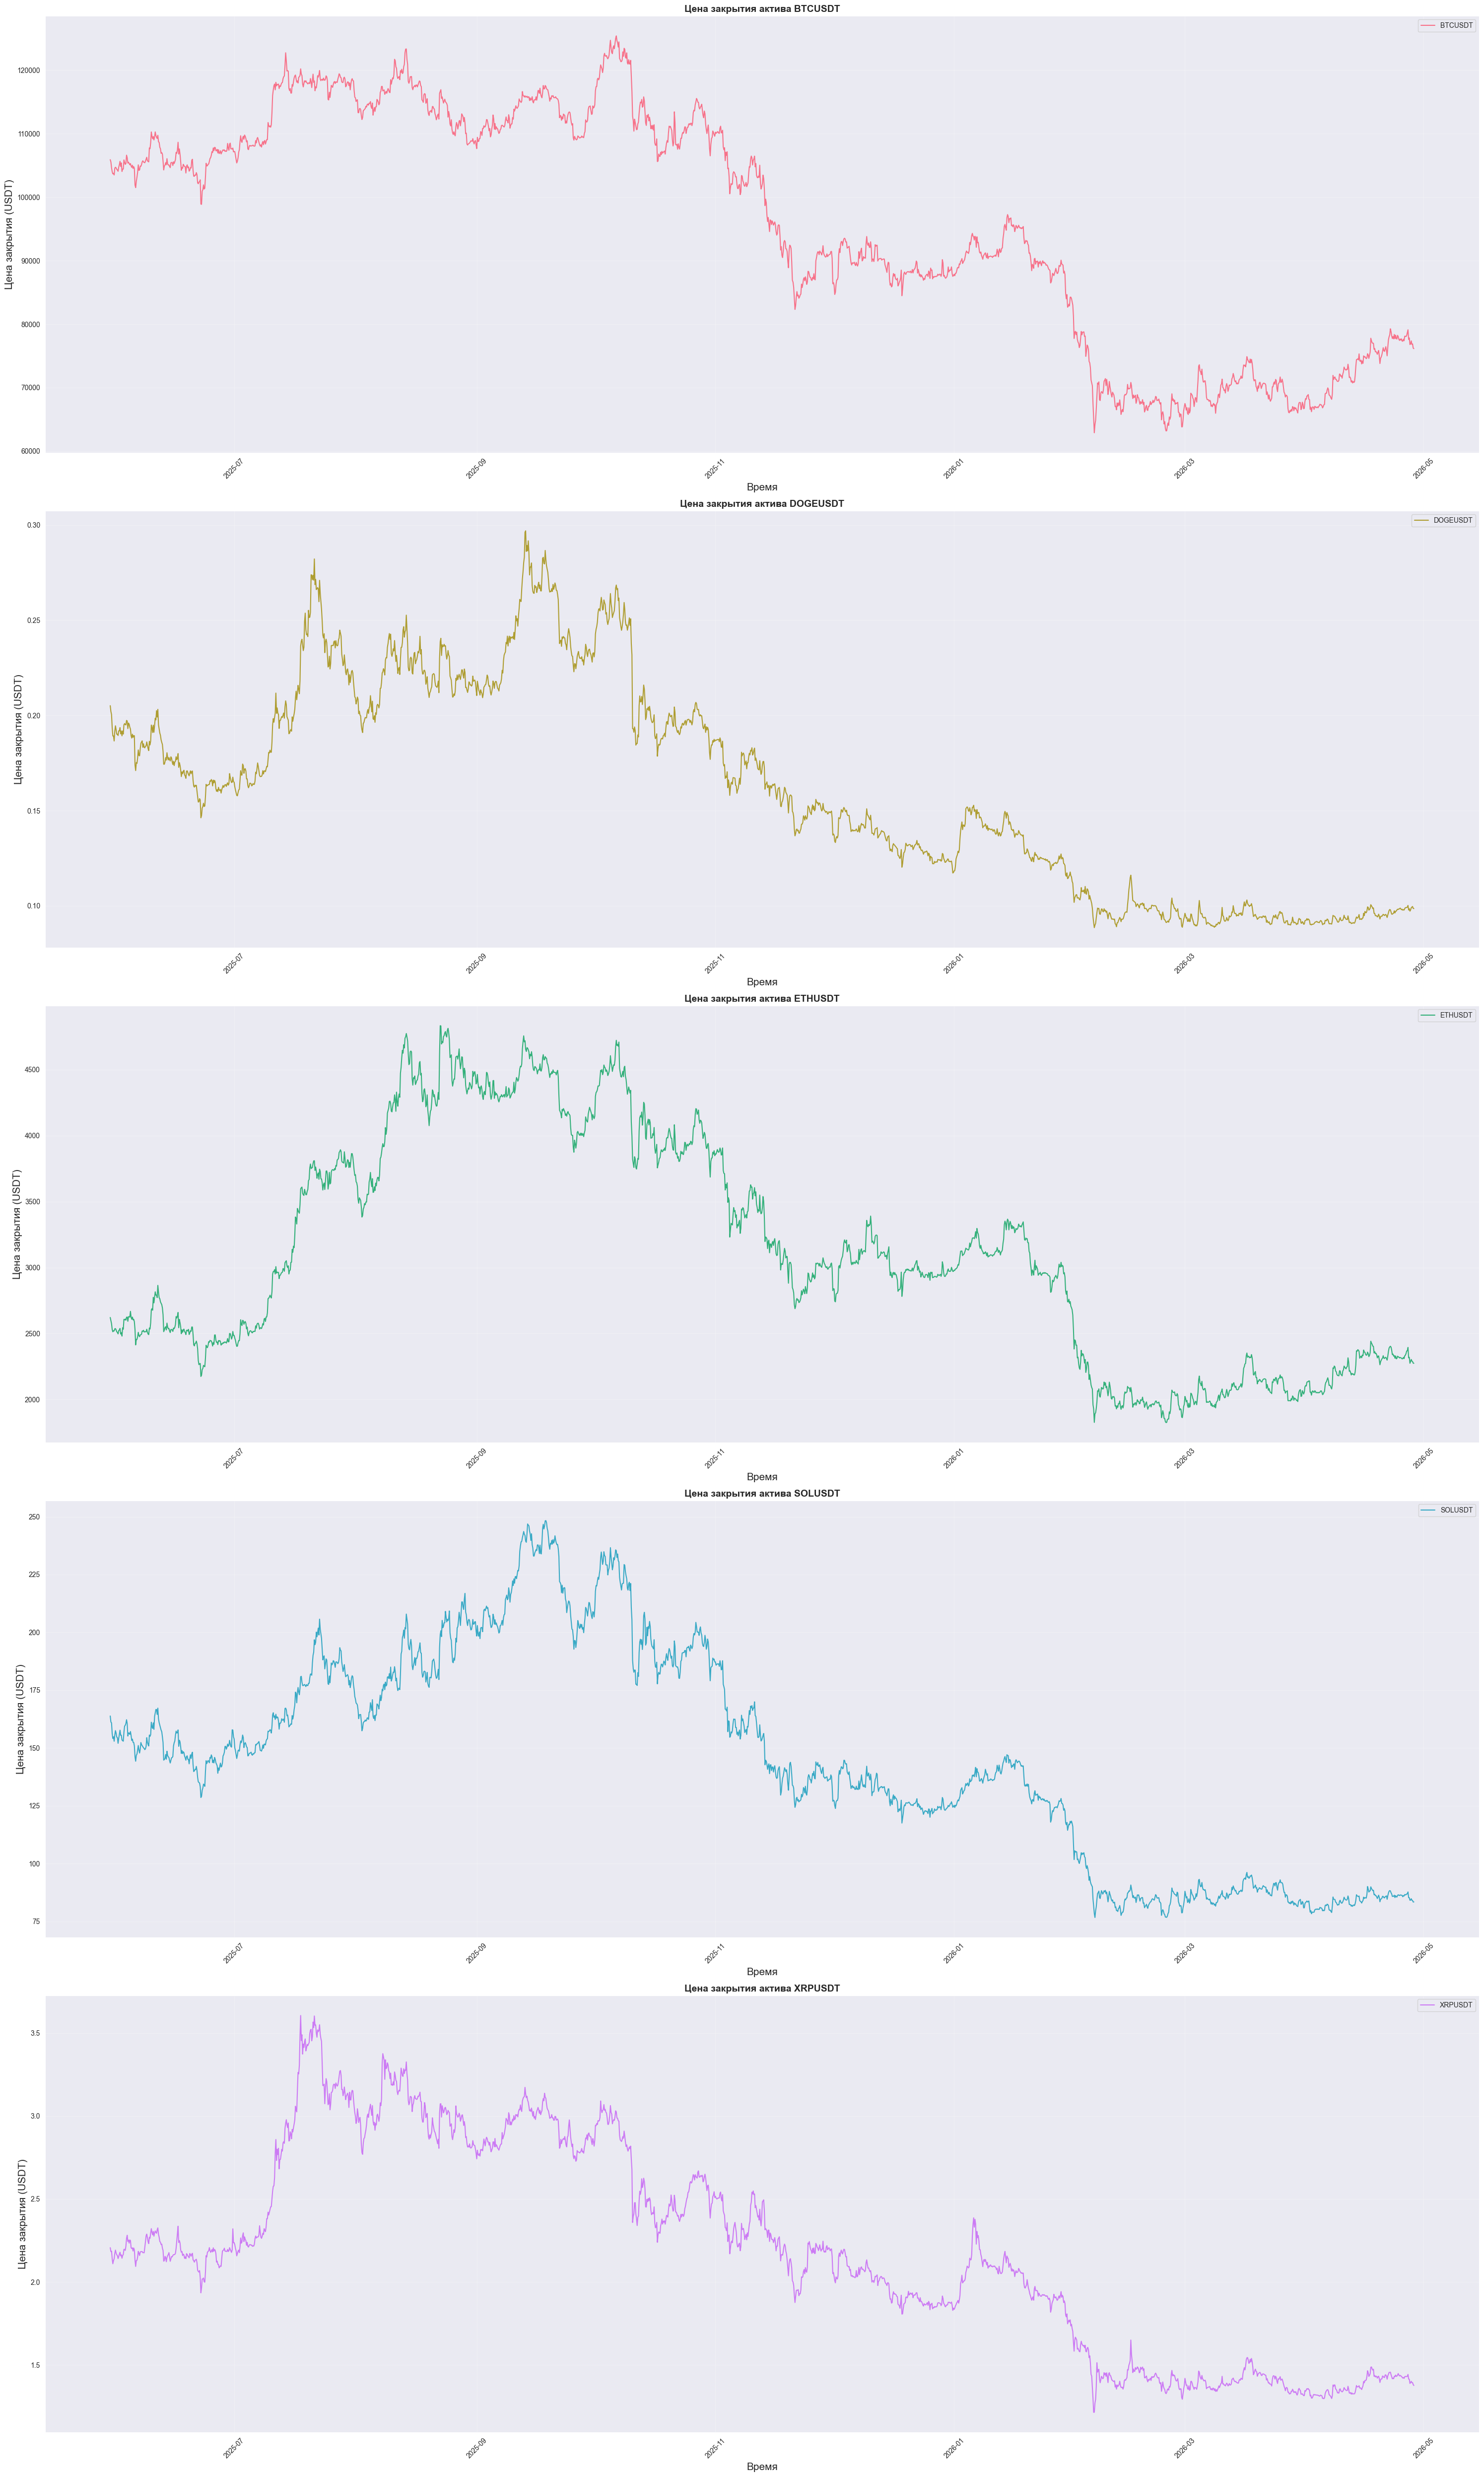

In [5]:
sns.set_style("darkgrid")
colors = sns.color_palette("husl", len(ALL_SYMBOLS))

fig, axes = plt.subplots(len(ALL_SYMBOLS), 1, figsize=(30, len(ALL_SYMBOLS) * 10))

if len(ALL_SYMBOLS) == 1:
    axes = [axes]

for idx, sym in enumerate(ALL_SYMBOLS):
    symbol_data = test_df[test_df["symbol"] == sym].copy()
    symbol_data["timestamp"] = pd.to_datetime(symbol_data["timestamp"])

    sns.lineplot(symbol_data, x='timestamp', y='close', color=colors[idx], ax=axes[idx], label=sym, linewidth=1.5)
    axes[idx].set_title(f'Цена закрытия актива {sym}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Время', fontsize=15)
    axes[idx].set_ylabel('Цена закрытия (USDT)', fontsize=15)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

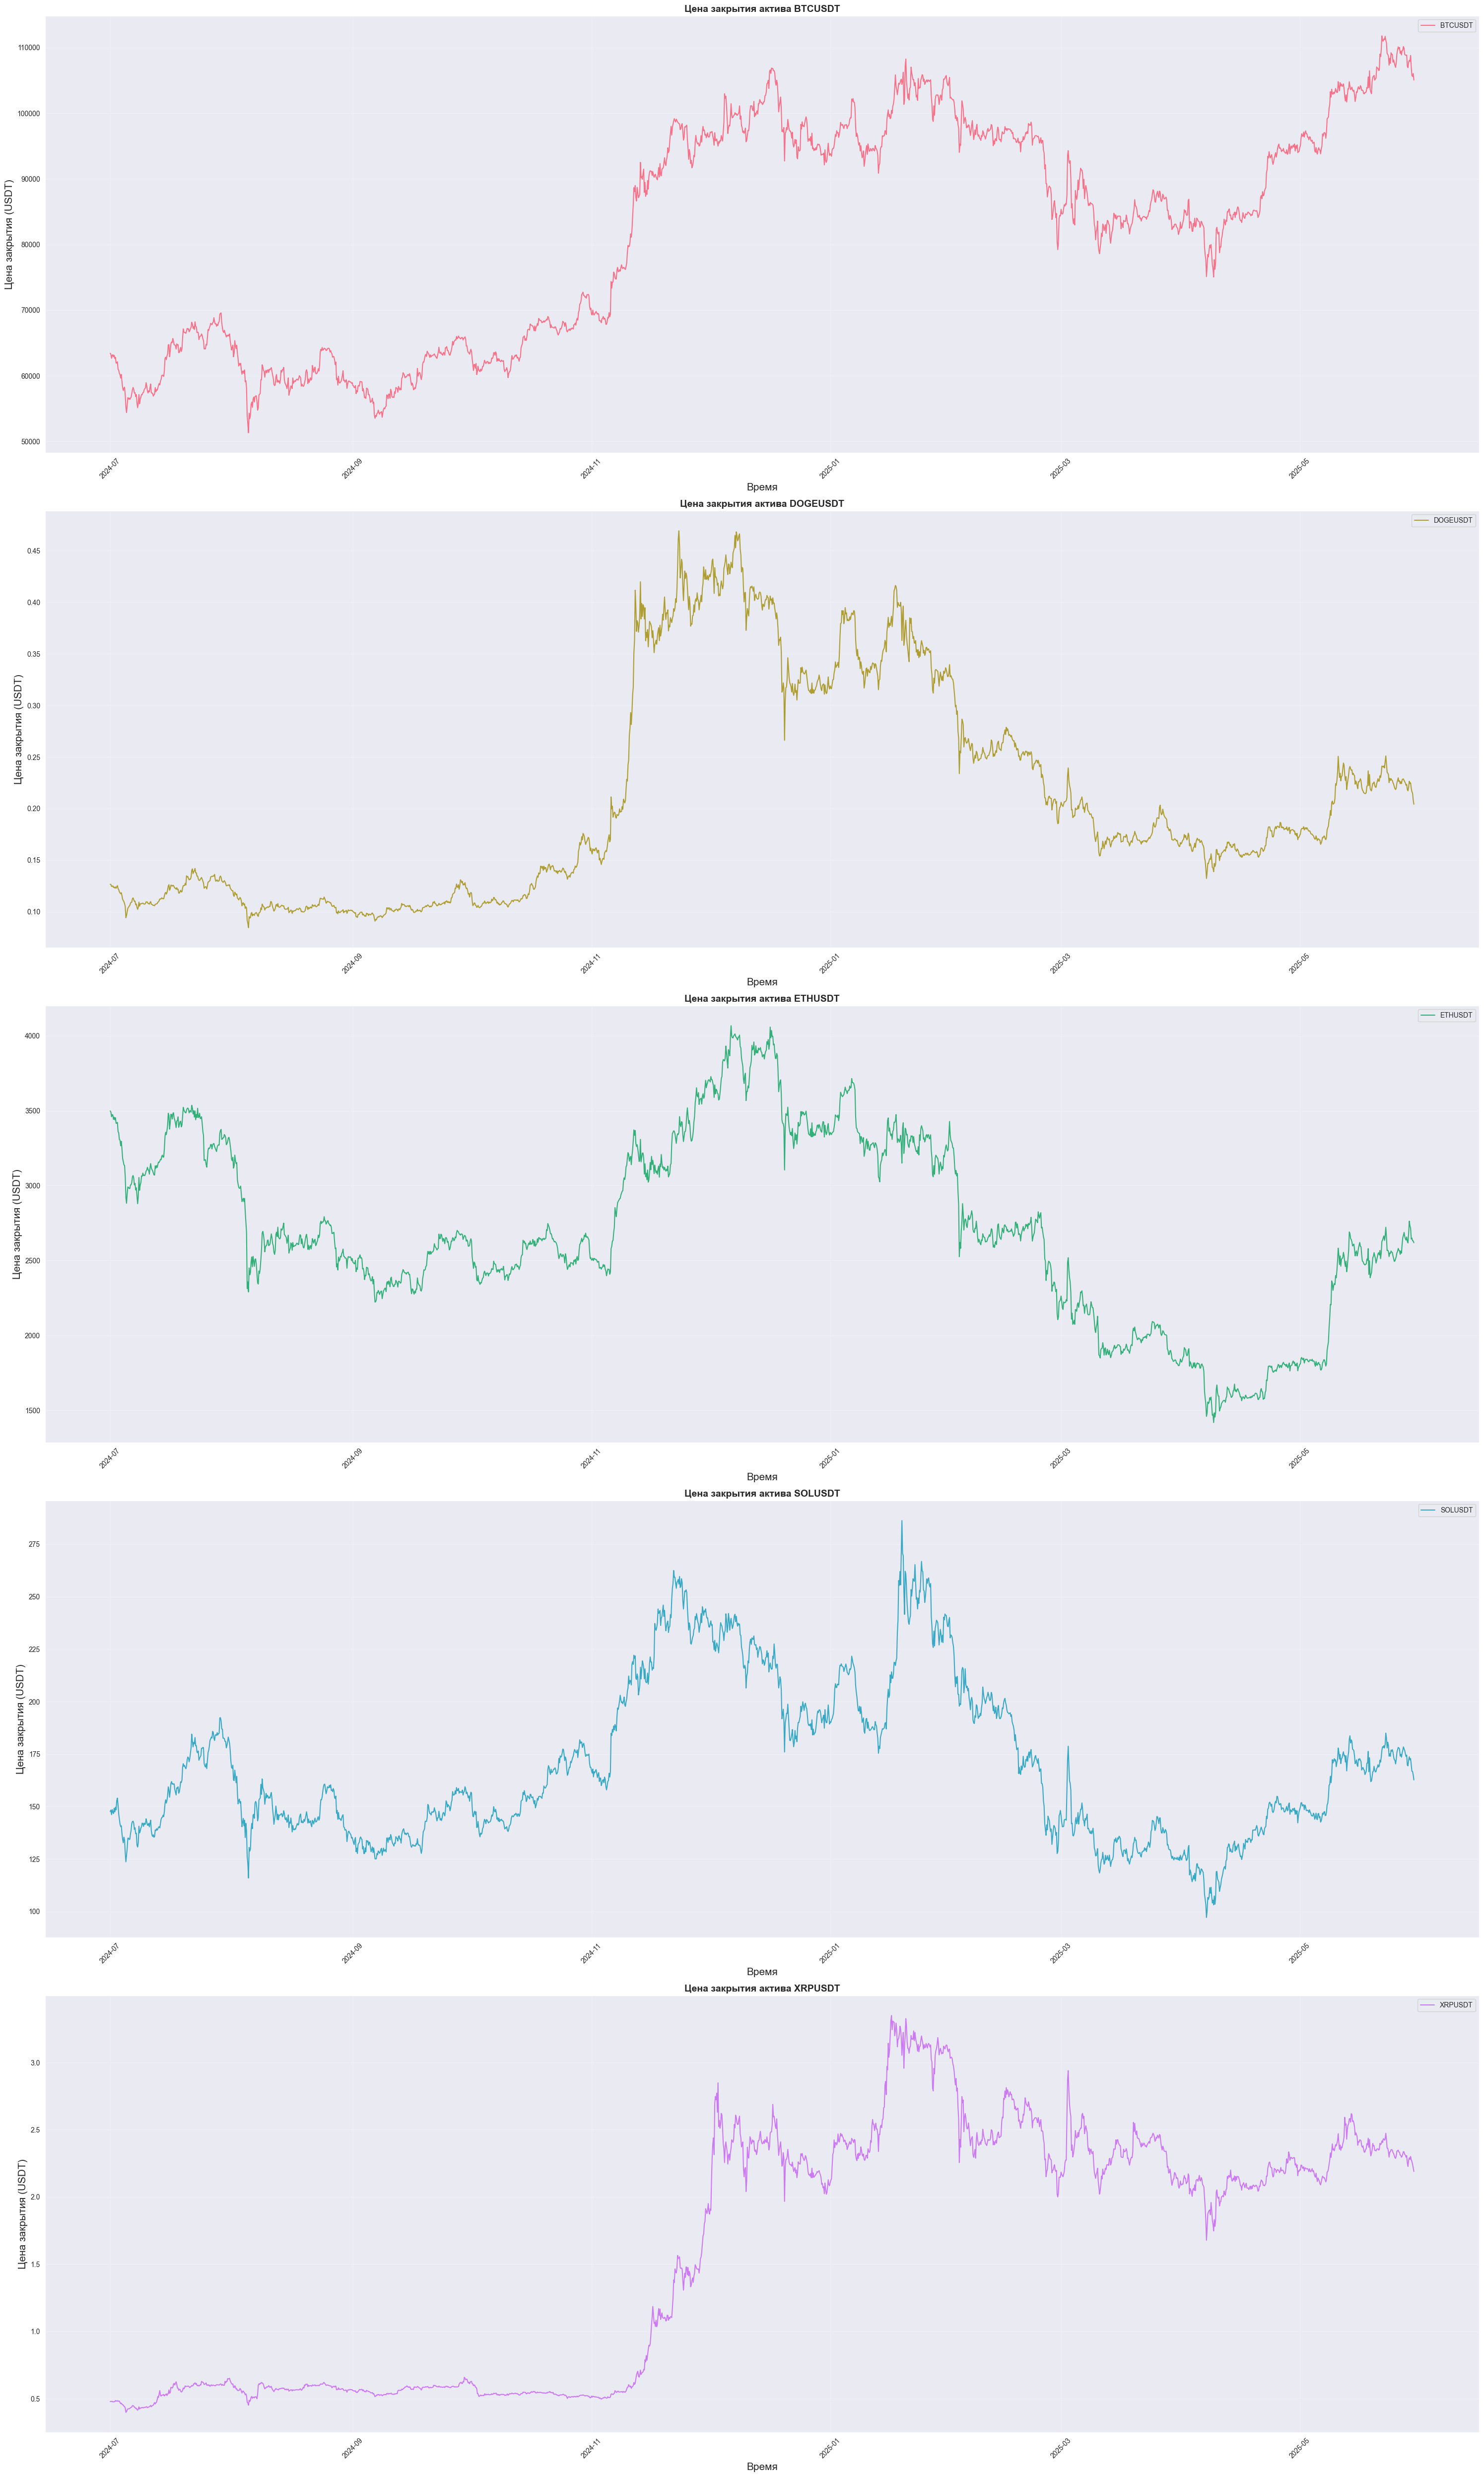

In [6]:
sns.set_style("darkgrid")
colors = sns.color_palette("husl", len(ALL_SYMBOLS))

fig, axes = plt.subplots(len(ALL_SYMBOLS), 1, figsize=(30, len(ALL_SYMBOLS) * 10))

if len(ALL_SYMBOLS) == 1:
    axes = [axes]

for idx, sym in enumerate(ALL_SYMBOLS):
    symbol_data = val_df[val_df["symbol"] == sym].copy()
    symbol_data["timestamp"] = pd.to_datetime(symbol_data["timestamp"])

    sns.lineplot(symbol_data, x='timestamp', y='close', color=colors[idx], ax=axes[idx], label=sym, linewidth=1.5)
    axes[idx].set_title(f'Цена закрытия актива {sym}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Время', fontsize=15)
    axes[idx].set_ylabel('Цена закрытия (USDT)', fontsize=15)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

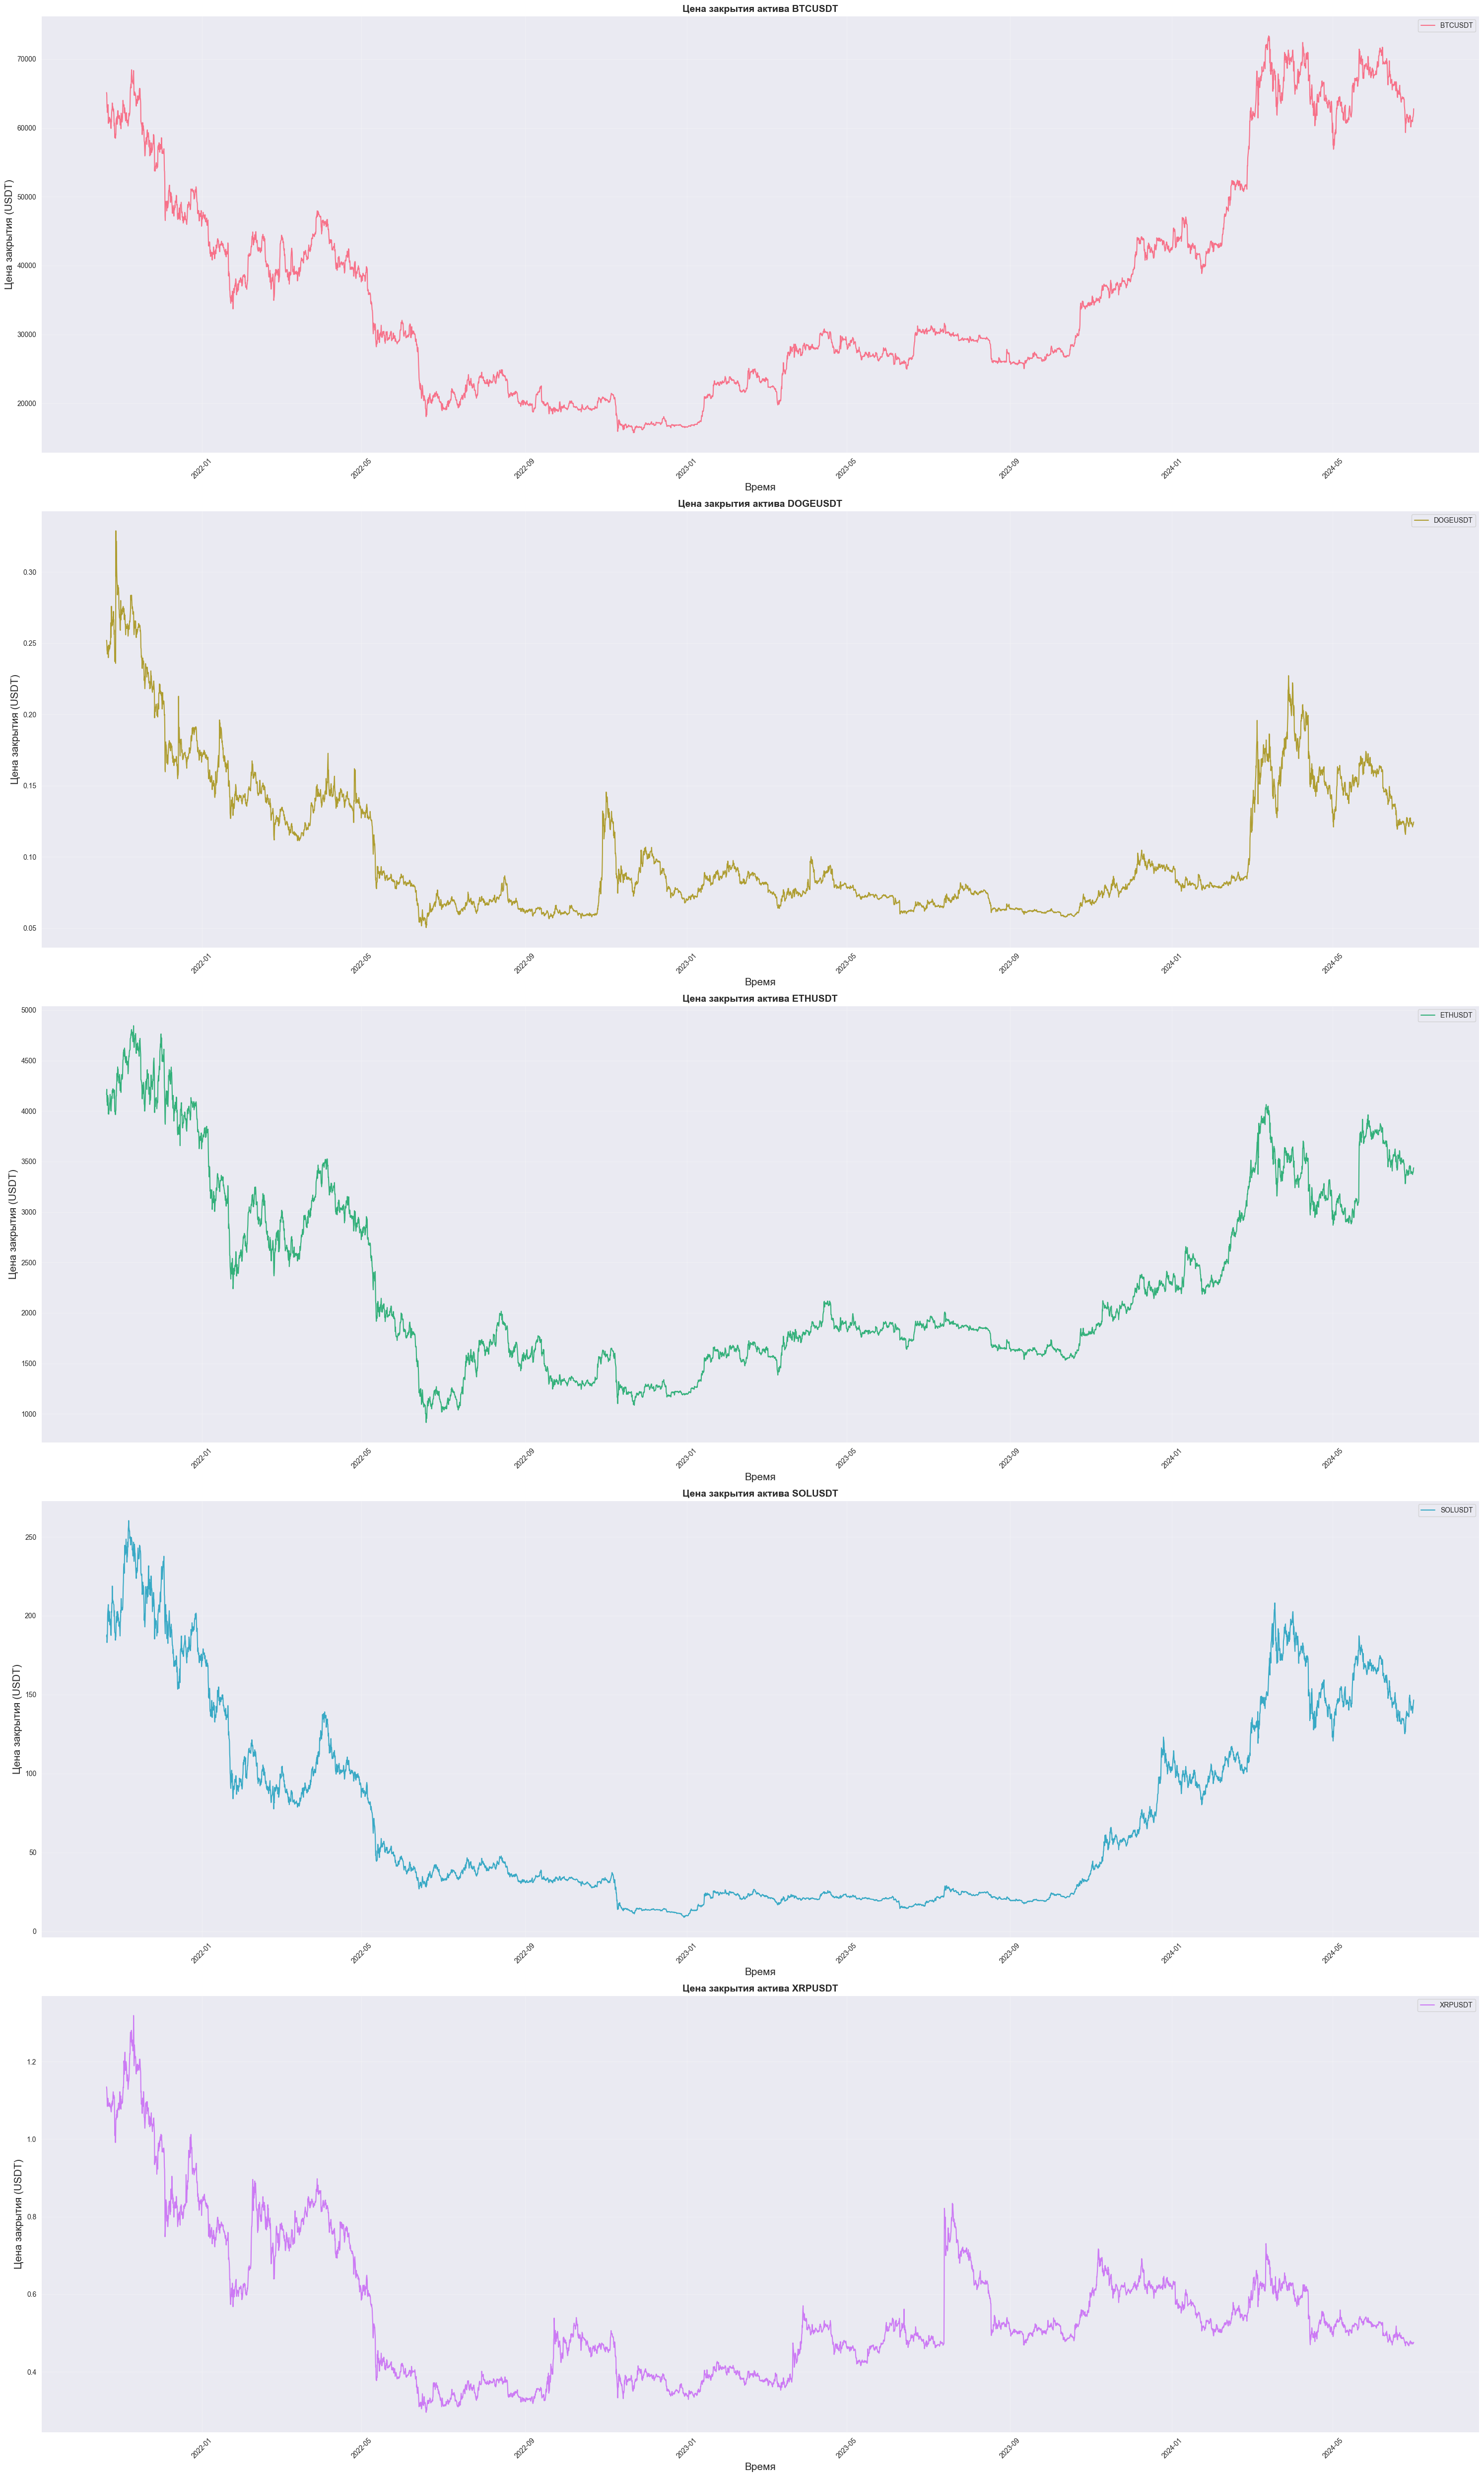

In [7]:
sns.set_style("darkgrid")
colors = sns.color_palette("husl", len(ALL_SYMBOLS))

fig, axes = plt.subplots(len(ALL_SYMBOLS), 1, figsize=(30, len(ALL_SYMBOLS) * 10))

if len(ALL_SYMBOLS) == 1:
    axes = [axes]

for idx, sym in enumerate(ALL_SYMBOLS):
    symbol_data = train_df[train_df["symbol"] == sym].copy()
    symbol_data["timestamp"] = pd.to_datetime(symbol_data["timestamp"])

    sns.lineplot(symbol_data, x='timestamp', y='close', color=colors[idx], ax=axes[idx], label=sym, linewidth=1.5)
    axes[idx].set_title(f'Цена закрытия актива {sym}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Время', fontsize=15)
    axes[idx].set_ylabel('Цена закрытия (USDT)', fontsize=15)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

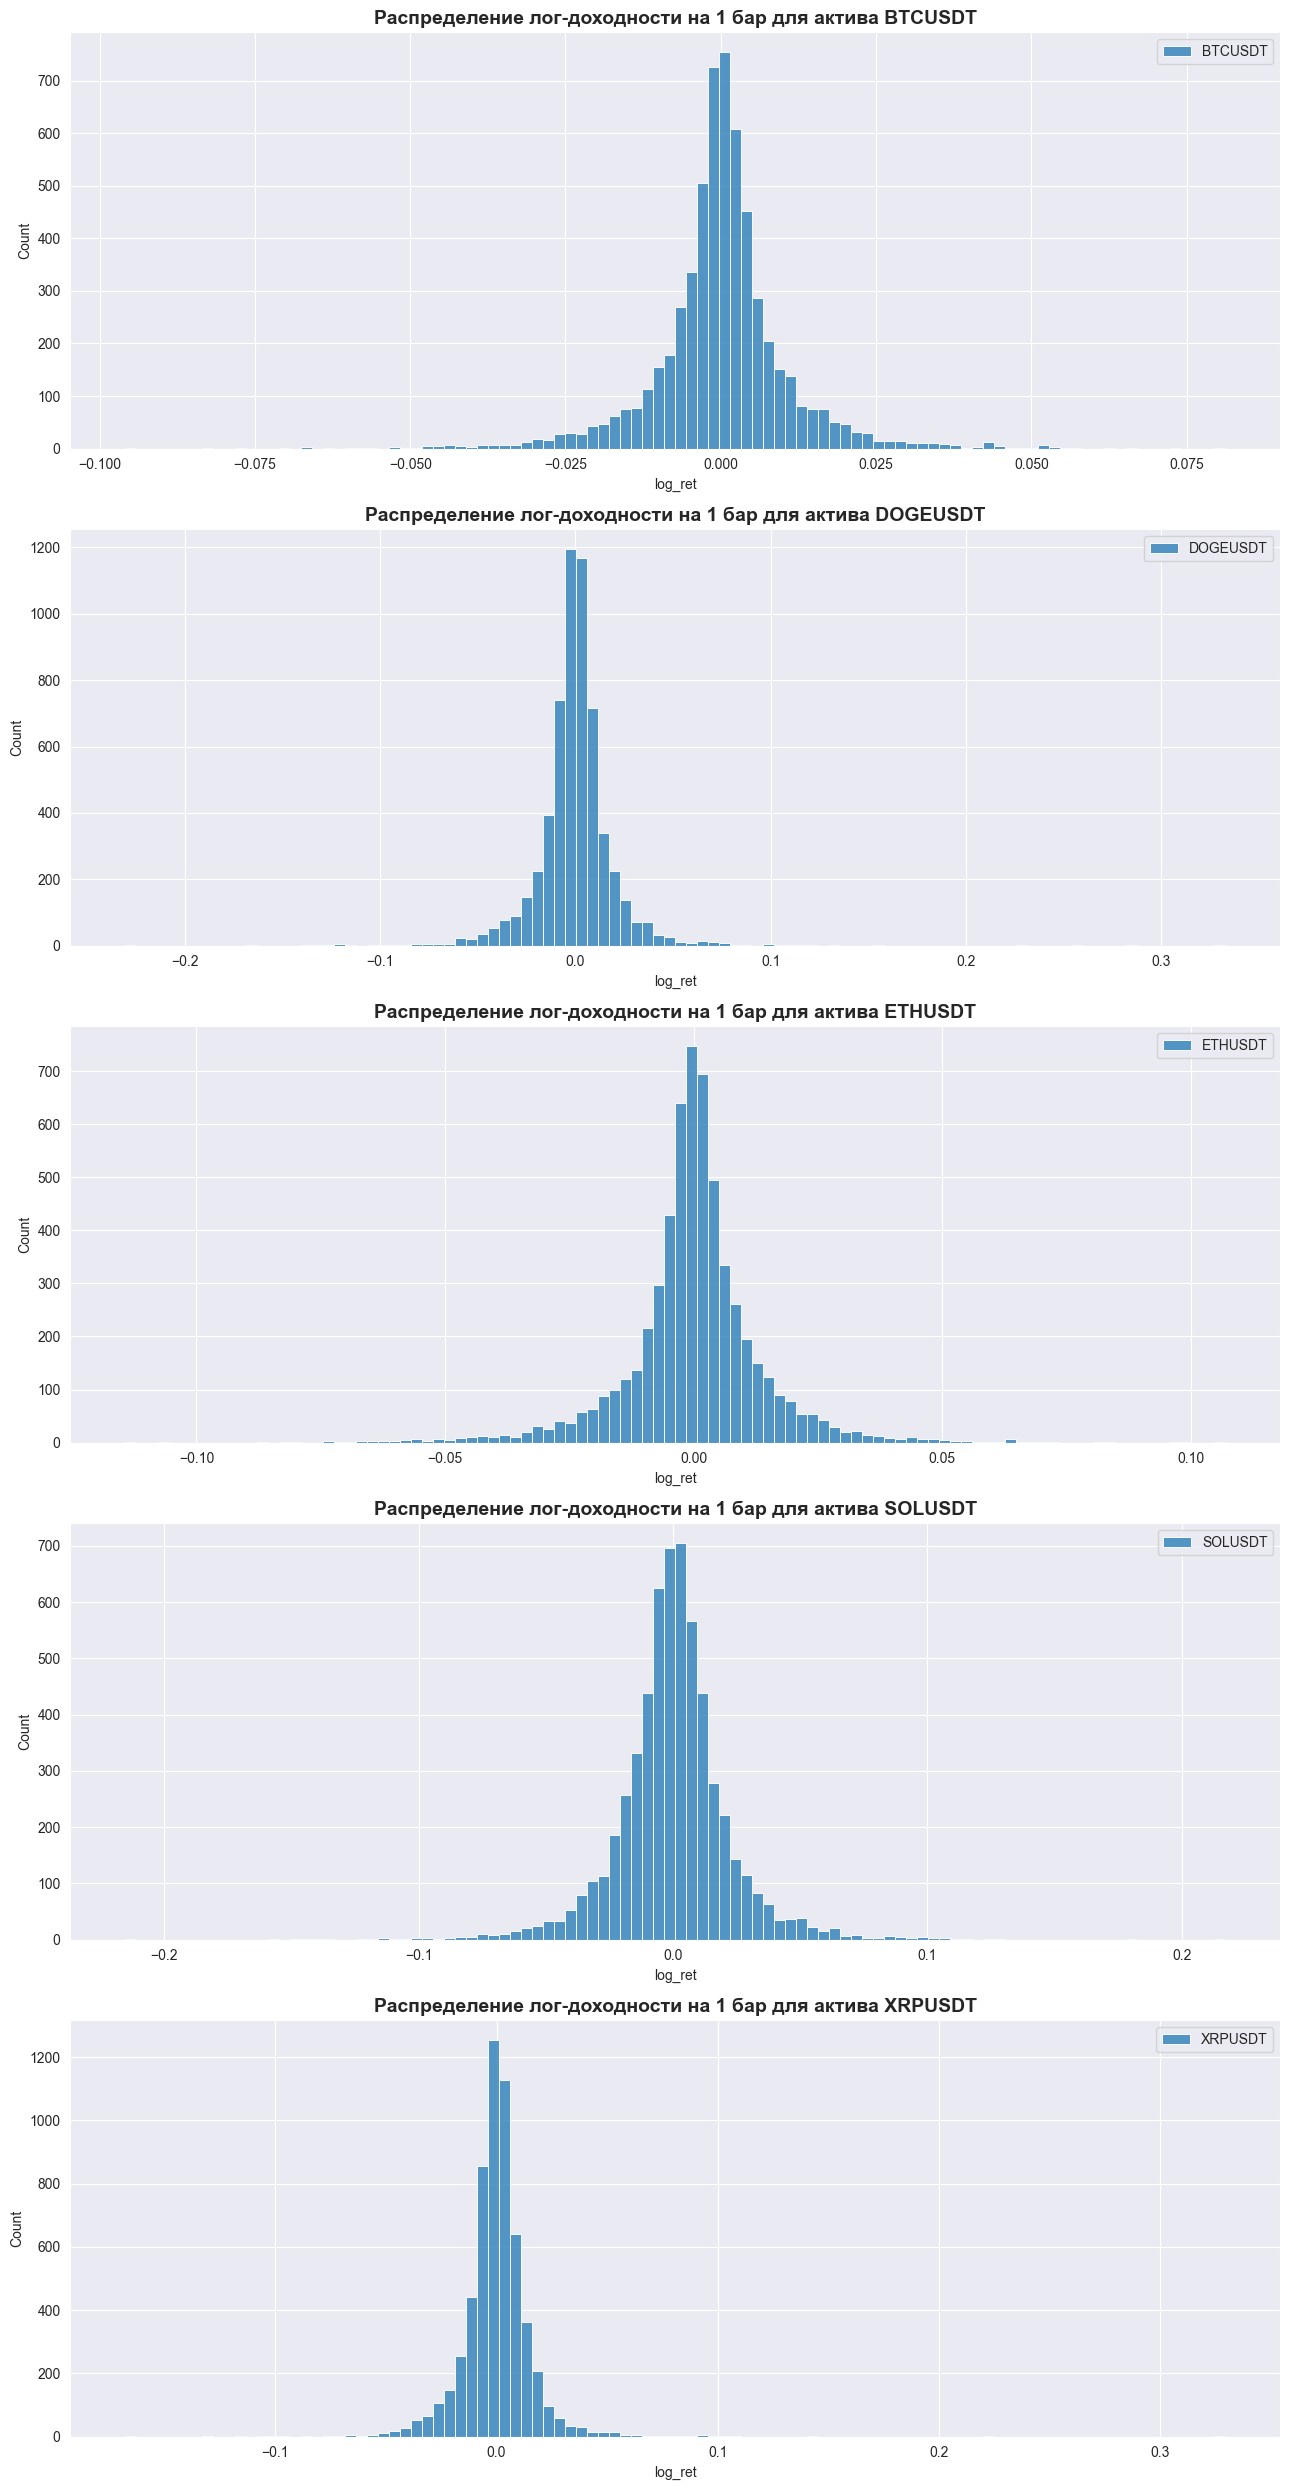

In [34]:
fig, axes = plt.subplots(len(ALL_SYMBOLS), 1, figsize=(13, len(ALL_SYMBOLS) * 5))
if len(ALL_SYMBOLS) == 1:
    axes = [axes]

for idx, sym in enumerate(ALL_SYMBOLS):
    symbol_data = train_df[train_df["symbol"] == sym].copy()
    symbol_data["log_ret"] = np.log(symbol_data["close"].shift(-1) / symbol_data["close"])
    sns.histplot(symbol_data["log_ret"].dropna(), bins=100, ax=axes[idx], label=sym)
    axes[idx].set_title(f"Распределение лог-доходности на 1 бар для актива {sym}", fontsize=14, fontweight="bold")
    axes[idx].legend()

plt.tight_layout()
plt.show()


In [35]:
trade_cost = 0.0025

print("one_side_ratio - какой процент 1-баровых log_ret превышает издержку в одну сторону c")
print("round_trip_ratio - какой процент 1-баровых log_ret превышает старый round-trip порог 2c")

for sym in ALL_SYMBOLS:
    sym_data = train_df[train_df["symbol"] == sym].copy()
    sym_data["log_ret"] = np.log(sym_data["close"].shift(-1) / sym_data["close"])
    sym_data = sym_data.dropna(subset=["log_ret"])

    one_side_threshold = np.log(1.0 / (1.0 - trade_cost))
    round_trip_threshold = np.log(1.0 / ((1.0 - trade_cost) ** 2))

    one_side_possible_entry_bars = (sym_data["log_ret"] > one_side_threshold).sum()
    round_trip_possible_entry_bars = (sym_data["log_ret"] > round_trip_threshold).sum()
    all_bars = len(sym_data)

    print(
        f"Актив {sym}: "
        f"one_side_ratio={one_side_possible_entry_bars / all_bars:.4f}, "
        f"round_trip_ratio={round_trip_possible_entry_bars / all_bars:.4f}"
    )

one_side_ratio - какой процент 1-баровых log_ret превышает издержку в одну сторону c
round_trip_ratio - какой процент 1-баровых log_ret превышает старый round-trip порог 2c
Актив BTCUSDT: one_side_ratio=0.3397, round_trip_ratio=0.2221
Актив DOGEUSDT: one_side_ratio=0.3999, round_trip_ratio=0.3145
Актив ETHUSDT: one_side_ratio=0.3668, round_trip_ratio=0.2667
Актив SOLUSDT: one_side_ratio=0.4321, round_trip_ratio=0.3633
Актив XRPUSDT: one_side_ratio=0.3902, round_trip_ratio=0.2938


In [36]:
trade_cost = 0.0025
horizon = 10

print(f"one_side_ratio - какой процент {horizon}-баровых log_ret превышает издержку в одну сторону c")
print(f"round_trip_ratio - какой процент {horizon}-баровых log_ret превышает старый round-trip порог 2c")

for sym in ALL_SYMBOLS:
    sym_data = train_df[train_df["symbol"] == sym].copy()
    sym_data["log_ret"] = np.log(sym_data["close"].shift(-horizon) / sym_data["close"])
    sym_data = sym_data.dropna(subset=["log_ret"])

    one_side_threshold = np.log(1.0 / (1.0 - trade_cost))
    round_trip_threshold = np.log(1.0 / ((1.0 - trade_cost) ** 2))

    one_side_possible_entry_bars = (sym_data["log_ret"] > one_side_threshold).sum()
    round_trip_possible_entry_bars = (sym_data["log_ret"] > round_trip_threshold).sum()
    all_bars = len(sym_data)

    print(
        f"Актив {sym}: "
        f"one_side_ratio={one_side_possible_entry_bars / all_bars:.4f}, "
        f"round_trip_ratio={round_trip_possible_entry_bars / all_bars:.4f}"
    )

one_side_ratio - какой процент 10-баровых log_ret превышает издержку в одну сторону c
round_trip_ratio - какой процент 10-баровых log_ret превышает старый round-trip порог 2c
Актив BTCUSDT: one_side_ratio=0.4475, round_trip_ratio=0.4044
Актив DOGEUSDT: one_side_ratio=0.4443, round_trip_ratio=0.4159
Актив ETHUSDT: one_side_ratio=0.4549, round_trip_ratio=0.4205
Актив SOLUSDT: one_side_ratio=0.4633, round_trip_ratio=0.4427
Актив XRPUSDT: one_side_ratio=0.4426, round_trip_ratio=0.4079


## Cost-aware target distribution diagnostics

Этот блок показывает, насколько разные горизонты на 4h данных дают движение, достаточное относительно trading cost. Это используется как EDA-обоснование выбора `horizon=10` на 4h барах: движение уже достаточно велико относительно комиссии, но feedback delay ещё не чрезмерный.

In [37]:
target_report_4h = target_distribution_report(
    train_df,
    horizons=(1, 3, 5, 10, 24),
    trade_cost=0.0025,
    interval_minutes=INTERVAL,
)

display(target_report_4h)


,interval_minutes,horizon_bars,horizon_hours,n,mean,std,median,abs_mean,abs_median,abs_p75,abs_p95,positive_ratio,one_side_long_success_ratio,one_side_short_success_ratio,abs_move_gt_one_side_cost_ratio,abs_move_gt_round_trip_cost_ratio,abs_mean_to_one_side_cost,std_to_one_side_cost
0,240,1,4.0,29395,-0.000074,0.017609,0.000000,0.010890,0.006546,0.013945,0.035767,0.499541,0.385508,0.380507,0.766015,0.584181,4.350519,7.034641
1,240,3,12.0,29395,-0.000219,0.030166,-0.000194,0.019293,0.011969,0.025249,0.061372,0.492669,0.427590,0.438476,0.866066,0.747474,7.707461,12.051402
2,240,5,20.0,29395,-0.000350,0.039134,-0.000395,0.025494,0.016439,0.034170,0.078555,0.490628,0.440755,0.455179,0.895935,0.803776,10.184741,15.634119
3,240,10,40.0,29395,-0.000692,0.054260,-0.001029,0.035814,0.023666,0.047882,0.108878,0.484742,0.450689,0.478687,0.929376,0.864127,14.307820,21.676756
4,240,24,96.0,29395,-0.001670,0.085953,-0.001495,0.057992,0.039813,0.077435,0.173273,0.487362,0.466712,0.492533,0.959245,0.920327,23.167854,34.338059


## Optional: same-calendar-horizon comparison for 30m / 1h / 4h data

Чтобы доказать не просто выбор `horizon=10` внутри 4h данных, а сравнить 30m/1h/4h, нужно сравнивать одинаковый календарный горизонт. Для 40 часов это:
- 30m: horizon=80 bars
- 1h: horizon=40 bars
- 4h: horizon=10 bars

Блок ниже пропускает отсутствующие parquet-файлы, поэтому его можно запускать безопасно.

In [38]:
from pathlib import Path
import pandas as pd

# Лучше явно задать корень проекта
PROJECT_ROOT = Path(r"D:\PythonProjects\VKR")
KLINES_DIR = PROJECT_ROOT / "data" / "klines_data"

INTERVAL_COMPARISON = {
    30: {
        "path": KLINES_DIR / "crypto_30m_bybit_TEST.parquet",
        "horizon_bars": 80,   # 40h
    },
    60: {
        "path": KLINES_DIR / "crypto_60m_bybit_TEST.parquet",
        "horizon_bars": 40,   # 40h
    },
    240: {
        "path": KLINES_DIR / "crypto_240m_bybit_TEST.parquet",
        "horizon_bars": 10,   # 40h
    },
}

print("KLINES_DIR:", KLINES_DIR)
print("Available parquet files:")
for p in sorted(KLINES_DIR.glob("*.parquet")):
    print(" -", p.name)

interval_target_rows = []

for interval_minutes, cfg in INTERVAL_COMPARISON.items():
    data_path = Path(cfg["path"])

    if not data_path.exists():
        print(f"Skip interval={interval_minutes}m: file not found -> {data_path}")
        continue

    loader_interval = KlinesDataLoader(symbols=ALL_SYMBOLS)

    df_interval = loader_interval.load_data(
        download_path=str(data_path),
        analyse_data=True,
        cleaning=True,
    )

    df_interval = (
        df_interval
        .sort_values(["symbol", "timestamp"])
        .reset_index(drop=True)
    )

    df_interval = add_chronological_phase_by_symbol(
        df_interval,
        val_bars=VAL_BARS,
        test_bars=TEST_BARS,
        embargo_bars=EMBARGO_BARS,
    )

    train_interval = df_interval[df_interval["phase"].eq("train")].copy()

    report_interval = target_distribution_report(
        train_interval,
        horizons=(cfg["horizon_bars"],),
        trade_cost=0.0025,
        interval_minutes=interval_minutes,
    )

    report_interval["source_file"] = data_path.name
    interval_target_rows.append(report_interval)

if interval_target_rows:
    interval_target_comparison = pd.concat(interval_target_rows, ignore_index=True)
    display(interval_target_comparison)
else:
    interval_target_comparison = pd.DataFrame()
    print("No interval comparison files were found.")

KLINES_DIR: D:\PythonProjects\VKR\data\klines_data
Available parquet files:
 - crypto_240m_bybit_TEST.parquet
 - crypto_30m_bybit_TEST.parquet
 - crypto_60m_bybit_TEST.parquet
			Статистика без фильтрации

Количество строк: 412394
Количество столбцов: 8
Количество пропущенных значений: 0

Название столбцов: timestamp, open, high, low, close, volume, turnover, symbol
Название активов: BTCUSDT, DOGEUSDT, ETHUSDT, SOLUSDT, XRPUSDT

Длина временного ряда актива BTCUSDT: 84186
Длина временного ряда актива DOGEUSDT: 81460
Длина временного ряда актива ETHUSDT: 84186
Длина временного ряда актива SOLUSDT: 79076
Длина временного ряда актива XRPUSDT: 83486

Временные рамки ряда каждого актива:
BTCUSDT: 2021-07-05 12:00:00+00:00 - 2026-04-28 12:30:00+00:00
DOGEUSDT: 2021-08-31 07:00:00+00:00 - 2026-04-28 12:30:00+00:00
ETHUSDT: 2021-07-05 12:00:00+00:00 - 2026-04-28 12:30:00+00:00
SOLUSDT: 2021-10-24 03:00:00+00:00 - 2026-04-28 12:30:00+00:00
XRPUSDT: 2021-07-20 02:00:00+00:00 - 2026-04-28 12:30:0

,interval_minutes,horizon_bars,horizon_hours,n,mean,std,median,abs_mean,abs_median,abs_p75,abs_p95,positive_ratio,one_side_long_success_ratio,one_side_short_success_ratio,abs_move_gt_one_side_cost_ratio,abs_move_gt_round_trip_cost_ratio,abs_mean_to_one_side_cost,std_to_one_side_cost,source_file
0,30,80,40.0,374980,-0.000323,0.054012,-0.000667,0.036310,0.024463,0.048843,0.108288,0.490533,0.457966,0.475591,0.933556,0.870582,14.505770,21.577982,crypto_30m_bybit_TEST.parquet
1,60,40,40.0,177840,0.000124,0.054523,-0.000365,0.036572,0.024596,0.048994,0.109595,0.494484,0.462539,0.471660,0.934199,0.872132,14.610400,21.782029,crypto_60m_bybit_TEST.parquet
2,240,10,40.0,29465,-0.000701,0.054204,-0.001034,0.035765,0.023607,0.047825,0.108755,0.484575,0.450501,0.478737,0.929238,0.863906,14.288286,21.654429,crypto_240m_bybit_TEST.parquet


## Multi-timeframe feature → target correlation by horizons

Этот блок сравнивает предсказательную силу признаков на 30m / 60m / 240m по target horizons `(1, 3, 5, 10, 24)` в барах.  
Важно: `horizon_hours` выводится явно, потому что один и тот же `horizon_bars` означает разные календарные горизонты на разных таймфреймах.


Interval: 30m | horizons: (1, 3, 5, 10, 24) bars
Processing BTCUSDT...
Processing DOGEUSDT...
Processing ETHUSDT...
Processing SOLUSDT...
Processing XRPUSDT...
Interval: 60m | horizons: (1, 3, 5, 10, 24) bars
Processing BTCUSDT...
Processing DOGEUSDT...
Processing ETHUSDT...
Processing SOLUSDT...
Processing XRPUSDT...
Interval: 240m | horizons: (1, 3, 5, 10, 24) bars
Processing BTCUSDT...
Processing DOGEUSDT...
Processing ETHUSDT...
Processing SOLUSDT...
Processing XRPUSDT...

RUN SUMMARY


,interval_minutes,interval_label,symbol,z_window,n_rows_after_targets,n_features,timestamp_min,timestamp_max,max_indicator_period_used
0,30,30m,BTCUSDT,192,45073,54,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,1600
1,30,30m,DOGEUSDT,192,45073,54,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,1600
2,30,30m,ETHUSDT,192,45073,54,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,1600
3,30,30m,SOLUSDT,192,45073,54,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,1600
4,30,30m,XRPUSDT,192,45073,54,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,1600
5,60,60m,BTCUSDT,96,22537,54,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,800
6,60,60m,DOGEUSDT,96,22537,54,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,800
7,60,60m,ETHUSDT,96,22537,54,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,800
8,60,60m,SOLUSDT,96,22537,54,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,800
9,60,60m,XRPUSDT,96,22537,54,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,800



PREDICTIVE STRENGTH SUMMARY ACROSS SYMBOLS


,interval_minutes,interval_label,horizon_bars,horizon_hours,mean_abs_corr_mean,median_abs_corr_mean,max_abs_corr_mean,top5_mean_abs_corr_mean,top10_mean_abs_corr_mean,features_abs_corr_gt_001_mean,features_abs_corr_gt_002_mean,features_abs_corr_gt_005_mean,n_symbols,n_rows_mean,n_features_mean
0,30,30m,1,0.5,0.015047,0.013509,0.062205,0.039780,0.032856,29.4,14.0,1.2,5,45073.0,54.0
1,30,30m,3,1.5,0.019880,0.018175,0.066061,0.045857,0.039507,36.4,21.8,2.6,5,45073.0,54.0
2,30,30m,5,2.5,0.020496,0.019326,0.061148,0.045371,0.039817,36.0,21.6,4.0,5,45073.0,54.0
3,30,30m,10,5.0,0.021417,0.020107,0.053625,0.044811,0.039953,37.6,22.6,4.8,5,45073.0,54.0
4,30,30m,24,12.0,0.022965,0.022290,0.059280,0.049967,0.043542,40.0,23.4,5.0,5,45073.0,54.0
5,60,60m,1,1.0,0.019085,0.015984,0.056797,0.044201,0.038728,34.2,22.4,2.0,5,22537.0,54.0
6,60,60m,3,3.0,0.020999,0.019834,0.049332,0.042947,0.038418,39.8,23.4,3.4,5,22537.0,54.0
7,60,60m,5,5.0,0.020944,0.020012,0.049124,0.042681,0.038751,37.0,23.2,3.8,5,22537.0,54.0
8,60,60m,10,10.0,0.021809,0.021481,0.057759,0.047579,0.041561,38.6,22.8,4.0,5,22537.0,54.0
9,60,60m,24,24.0,0.027848,0.026285,0.071436,0.061241,0.054187,45.0,31.6,7.8,5,22537.0,54.0



TOP FEATURE ↔ TARGET CORRELATIONS


,interval_minutes,interval_label,symbol,z_window,use_calendar_scaled_indicators,feature,target,horizon_bars,horizon_hours,corr_method,raw_corr,abs_corr,n_rows,n_features
0,30,30m,BTCUSDT,192,True,bb_pos_20_norm,target_log_ret_horizon_1,1,0.5,spearman,-0.064828,0.064828,45073,54
1,30,30m,BTCUSDT,192,True,MACD_hist_pct_z,target_log_ret_horizon_1,1,0.5,spearman,-0.036791,0.036791,45073,54
2,30,30m,BTCUSDT,192,True,dist_ema_72_z,target_log_ret_horizon_1,1,0.5,spearman,-0.030282,0.030282,45073,54
3,30,30m,BTCUSDT,192,True,dist_to_high_576_sqrt_z,target_log_ret_horizon_1,1,0.5,spearman,0.022384,0.022384,45073,54
4,30,30m,BTCUSDT,192,True,dist_to_high_192_sqrt_z,target_log_ret_horizon_1,1,0.5,spearman,0.022077,0.022077,45073,54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,30,30m,DOGEUSDT,192,True,MACD_hist_pct_z,target_log_ret_horizon_3,3,1.5,spearman,-0.046391,0.046391,45073,54
96,30,30m,DOGEUSDT,192,True,dist_to_high_192_sqrt_z,target_log_ret_horizon_3,3,1.5,spearman,0.043480,0.043480,45073,54
97,30,30m,DOGEUSDT,192,True,dist_ema_400_z,target_log_ret_horizon_3,3,1.5,spearman,-0.042581,0.042581,45073,54
98,30,30m,DOGEUSDT,192,True,dist_to_low_576_sqrt_z,target_log_ret_horizon_3,3,1.5,spearman,-0.042242,0.042242,45073,54


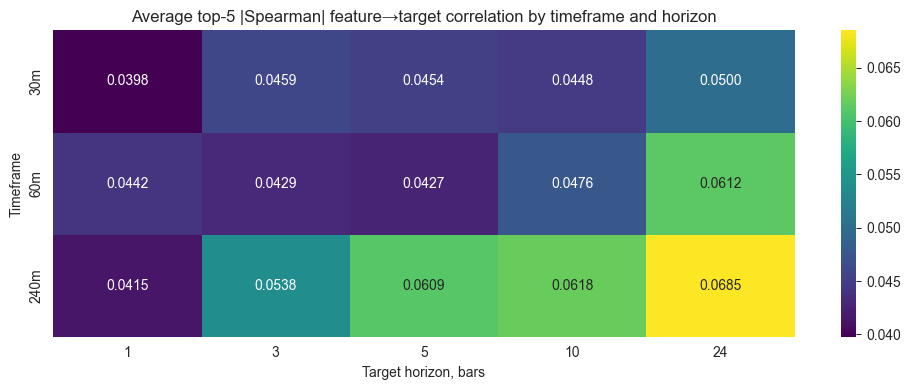

Saved MTF correlation artifacts to: D:\PythonProjects\VKR\eda\eda_multitimeframe_artifacts_common_range


In [39]:
# =====================================================================
# Multi-timeframe feature -> target Spearman correlation
# =====================================================================
# Run after the helper functions add_chronological_phase_by_symbol(),
# add_targets_grouped(), stream_TA_lib(), transform_indicators_df(),
# rolling_z_score_clip_df() and meta_cols are available.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

INTERVALS_FOR_MTF_CORR = (30, 60, 240)
HORIZONS_FOR_MTF_CORR = (1, 3, 5, 10, 24)
CORR_METHOD_MTF = "spearman"
CLIP_VALUE_MTF = 5.0
HIGH_CORR_DISPLAY_TOP_N = 15

# Base 4h indicator design from the main EDA block.
# If USE_CALENDAR_SCALED_INDICATORS=True, periods are rescaled so that
# indicator lookback has approximately the same calendar length across TFs.
BASE_INTERVAL_MINUTES = 240
BASE_CONFIG_FOR_INDICATORS_MTF = {
    "ema_periods": [9, 21, 50, 100, 200],
    "momentum_indicators_periods": [14, 30, 72],
    "return_indicators_periods": [6, 24, 72, 168],
    "volatility_indicators_periods": [24, 72, 168],
    "level_periods": [24, 72, 168],
    "vol_ma_period": [24, 72, 168],
    "range_ma_period": [24, 72, 168],
}
BASE_Z_WINDOW_MTF = 24
USE_CALENDAR_SCALED_INDICATORS = True


# Common decision-timestamp range for fair MTF comparison.
# Derived from previous mtf_corr_run_summary intersection and aligned to 4h grid.
USE_COMMON_DATE_RANGE_MTF = True
COMMON_START_MTF = pd.Timestamp("2021-11-30 16:00:00+00:00")
COMMON_END_MTF = pd.Timestamp("2024-06-26 16:00:00+00:00")


def filter_common_mtf_decision_range(df, start=COMMON_START_MTF, end=COMMON_END_MTF):
    """Keep only common decision timestamps across 30m/60m/240m EDA samples."""
    out = df.copy()
    out["timestamp"] = pd.to_datetime(out["timestamp"], utc=True)
    return (
        out.loc[out["timestamp"].between(start, end, inclusive="both")]
        .sort_values(["symbol", "timestamp"])
        .reset_index(drop=True)
    )

# Portable path logic: keep your Windows project path if it exists,
# otherwise use current notebook working directory.
PROJECT_ROOT_MTF = Path(r"D:\PythonProjects\VKR")
if not PROJECT_ROOT_MTF.exists():
    PROJECT_ROOT_MTF = Path.cwd()

DATA_FILES_BY_INTERVAL_MTF = {
    interval: PROJECT_ROOT_MTF / "data" / "klines_data" / f"crypto_{interval}m_bybit_TEST.parquet"
    for interval in INTERVALS_FOR_MTF_CORR
}


def _scale_periods_to_interval(periods, interval_minutes, base_interval_minutes=BASE_INTERVAL_MINUTES):
    """Convert base 4h bar periods to approximately equal calendar lookbacks."""
    if isinstance(periods, int):
        periods = [periods]
    factor = base_interval_minutes / interval_minutes
    return sorted({max(2, int(round(int(p) * factor))) for p in periods})


def indicator_config_for_interval(interval_minutes, use_calendar_scaled=True):
    if not use_calendar_scaled:
        return {k: list(v) for k, v in BASE_CONFIG_FOR_INDICATORS_MTF.items()}
    return {
        k: _scale_periods_to_interval(v, interval_minutes)
        for k, v in BASE_CONFIG_FOR_INDICATORS_MTF.items()
    }


def z_window_for_interval(interval_minutes, use_calendar_scaled=True):
    if not use_calendar_scaled:
        return BASE_Z_WINDOW_MTF
    return _scale_periods_to_interval([BASE_Z_WINDOW_MTF], interval_minutes)[0]


def load_interval_ohlcv(interval_minutes):
    path = DATA_FILES_BY_INTERVAL_MTF[interval_minutes]

    # KlinesDataLoader supports absolute paths on Windows because Path(project_root) / absolute_path == absolute_path.
    # If the absolute path is not present, fall back to project-relative path used by the original notebook.
    if path.exists():
        download_path = str(path)
    else:
        download_path = f"data/klines_data/crypto_{interval_minutes}m_bybit_TEST.parquet"

    loader_interval = KlinesDataLoader(symbols=ALL_SYMBOLS)
    df = loader_interval.load_data(
        download_path=download_path,
        analyse_data=False,
        cleaning=True,
    )

    df = df.sort_values(["symbol", "timestamp"]).reset_index(drop=True)

    # Keep compatibility with meta_cols from the original notebook.
    if "future_close_price" not in df.columns:
        df["future_close_price"] = df.groupby("symbol")["close"].shift(-1)

    return df


def safe_feature_cols_mtf(df, meta_cols, target_cols):
    """Feature columns after fixed stream/transform logic, with an additional safety net."""
    ema_level_cols = [
        col for col in df.columns
        if col.startswith("ema_") and not col.startswith(("ema_slope", "ema_spread"))
    ]

    forbidden_cols = [
        col for col in df.columns
        if col.startswith(("vol_ma_", "range_ma_"))
        or (col.startswith("MOM_") and not col.startswith("MOM_pct"))
        or col == "MACD_hist"
    ]

    non_feature_cols = set(meta_cols) | {"phase"}

    return [
        col for col in df.columns
        if col not in non_feature_cols
        and col not in target_cols
        and col not in ema_level_cols
        and col not in forbidden_cols
    ]


def build_zscore_features_for_interval_symbol(
    df_interval,
    symbol,
    interval_minutes,
    meta_cols,
    clip_value=CLIP_VALUE_MTF,
    use_calendar_scaled=USE_CALENDAR_SCALED_INDICATORS,
):
    df_symbol = (
        df_interval[df_interval["symbol"].eq(symbol)]
        .sort_values("timestamp")
        .reset_index(drop=True)
        .copy()
    )

    config = indicator_config_for_interval(interval_minutes, use_calendar_scaled=use_calendar_scaled)
    z_window = z_window_for_interval(interval_minutes, use_calendar_scaled=use_calendar_scaled)

    indicators = stream_TA_lib(
        df=df_symbol,
        meta_cols=meta_cols,
        **config,
    )

    indicators = (
        indicators
        .dropna()
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    transformed = transform_indicators_df(indicators, meta_cols=meta_cols)

    zscored = rolling_z_score_clip_df(
        transformed,
        meta_cols=meta_cols,
        window=z_window,
        clip_value=clip_value,
        shift_by_one=True,
    )

    zscored = (
        zscored
        .dropna()
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    return zscored, config, z_window


feature_target_corr_rows_mtf = []
target_power_rows_mtf = []
run_summary_rows_mtf = []

for interval_minutes in INTERVALS_FOR_MTF_CORR:
    print("=" * 100)
    print(f"Interval: {interval_minutes}m | horizons: {HORIZONS_FOR_MTF_CORR} bars")
    print("=" * 100)

    df_interval_raw = load_interval_ohlcv(interval_minutes)

    for sym in ALL_SYMBOLS:
        print(f"Processing {sym}...")

        df_z, used_config, used_z_window = build_zscore_features_for_interval_symbol(
            df_interval=df_interval_raw,
            symbol=sym,
            interval_minutes=interval_minutes,
            meta_cols=meta_cols,
        )

        # Split after feature engineering/dropna, matching the export block logic.
        df_z = add_chronological_phase_by_symbol(
            df_z,
            val_bars=VAL_BARS,
            test_bars=TEST_BARS,
            embargo_bars=EMBARGO_BARS,
        )

        df_train_z = df_z[df_z["phase"].eq("train")].copy()

        # Targets are built only inside train rows, avoiding train->val leakage.
        df_corr_mtf = add_targets_grouped(
            df_train_z,
            horizons=HORIZONS_FOR_MTF_CORR,
        )

        target_cols_mtf = [f"target_log_ret_horizon_{h}" for h in HORIZONS_FOR_MTF_CORR]

        if USE_COMMON_DATE_RANGE_MTF:
            df_corr_mtf = filter_common_mtf_decision_range(df_corr_mtf)

        # Use the same decision rows for every target horizon in the common-range run.
        # This removes the last max(horizon) rows where the longest target is not available.
        df_corr_mtf = df_corr_mtf.dropna(subset=target_cols_mtf).reset_index(drop=True)

        feature_cols_mtf = safe_feature_cols_mtf(df_corr_mtf, meta_cols, target_cols_mtf)

        if not feature_cols_mtf:
            print(f"Skip {sym}, {interval_minutes}m: no feature columns")
            continue

        corr_full_mtf = df_corr_mtf[feature_cols_mtf + target_cols_mtf].corr(method=CORR_METHOD_MTF)
        target_corr_mtf = corr_full_mtf.loc[feature_cols_mtf, target_cols_mtf]

        for feature in feature_cols_mtf:
            for h, target in zip(HORIZONS_FOR_MTF_CORR, target_cols_mtf):
                raw_corr = target_corr_mtf.loc[feature, target]
                feature_target_corr_rows_mtf.append({
                    "interval_minutes": interval_minutes,
                    "interval_label": f"{interval_minutes}m",
                    "symbol": sym,
                    "z_window": used_z_window,
                    "use_calendar_scaled_indicators": USE_CALENDAR_SCALED_INDICATORS,
                    "feature": feature,
                    "target": target,
                    "horizon_bars": h,
                    "horizon_hours": h * interval_minutes / 60.0,
                    "corr_method": CORR_METHOD_MTF,
                    "raw_corr": float(raw_corr) if pd.notna(raw_corr) else np.nan,
                    "abs_corr": abs(float(raw_corr)) if pd.notna(raw_corr) else np.nan,
                    "n_rows": len(df_corr_mtf),
                    "n_features": len(feature_cols_mtf),
                })

        for h, target in zip(HORIZONS_FOR_MTF_CORR, target_cols_mtf):
            abs_s = target_corr_mtf[target].abs().dropna().sort_values(ascending=False)
            target_power_rows_mtf.append({
                "interval_minutes": interval_minutes,
                "interval_label": f"{interval_minutes}m",
                "symbol": sym,
                "z_window": used_z_window,
                "use_calendar_scaled_indicators": USE_CALENDAR_SCALED_INDICATORS,
                "target": target,
                "horizon_bars": h,
                "horizon_hours": h * interval_minutes / 60.0,
                "mean_abs_corr": float(abs_s.mean()) if len(abs_s) else np.nan,
                "median_abs_corr": float(abs_s.median()) if len(abs_s) else np.nan,
                "max_abs_corr": float(abs_s.max()) if len(abs_s) else np.nan,
                "top5_mean_abs_corr": float(abs_s.head(5).mean()) if len(abs_s) else np.nan,
                "top10_mean_abs_corr": float(abs_s.head(10).mean()) if len(abs_s) else np.nan,
                "features_abs_corr_gt_001": int((abs_s > 0.01).sum()),
                "features_abs_corr_gt_002": int((abs_s > 0.02).sum()),
                "features_abs_corr_gt_005": int((abs_s > 0.05).sum()),
                "n_rows": len(df_corr_mtf),
                "n_features": len(feature_cols_mtf),
                "timestamp_min": df_corr_mtf["timestamp"].min(),
                "timestamp_max": df_corr_mtf["timestamp"].max(),
            })

        run_summary_rows_mtf.append({
            "interval_minutes": interval_minutes,
            "interval_label": f"{interval_minutes}m",
            "symbol": sym,
            "z_window": used_z_window,
            "n_rows_after_targets": len(df_corr_mtf),
            "n_features": len(feature_cols_mtf),
            "timestamp_min": df_corr_mtf["timestamp"].min(),
            "timestamp_max": df_corr_mtf["timestamp"].max(),
            "max_indicator_period_used": max(max(v) for v in used_config.values()),
        })

feature_target_corr_long_mtf = pd.DataFrame(feature_target_corr_rows_mtf)
target_power_mtf = pd.DataFrame(target_power_rows_mtf)
mtf_corr_run_summary = pd.DataFrame(run_summary_rows_mtf)

# Aggregate across symbols: this is the main table for timeframe/horizon comparison.
target_power_mtf_summary = (
    target_power_mtf
    .groupby(["interval_minutes", "interval_label", "horizon_bars", "horizon_hours"], as_index=False)
    .agg(
        mean_abs_corr_mean=("mean_abs_corr", "mean"),
        median_abs_corr_mean=("median_abs_corr", "mean"),
        max_abs_corr_mean=("max_abs_corr", "mean"),
        top5_mean_abs_corr_mean=("top5_mean_abs_corr", "mean"),
        top10_mean_abs_corr_mean=("top10_mean_abs_corr", "mean"),
        features_abs_corr_gt_001_mean=("features_abs_corr_gt_001", "mean"),
        features_abs_corr_gt_002_mean=("features_abs_corr_gt_002", "mean"),
        features_abs_corr_gt_005_mean=("features_abs_corr_gt_005", "mean"),
        n_symbols=("symbol", "nunique"),
        n_rows_mean=("n_rows", "mean"),
        n_features_mean=("n_features", "mean"),
    )
    .sort_values(["interval_minutes", "horizon_bars"])
    .reset_index(drop=True)
)

# Top features by symbol/interval/horizon.
top_features_mtf = (
    feature_target_corr_long_mtf
    .dropna(subset=["abs_corr"])
    .sort_values(["interval_minutes", "symbol", "horizon_bars", "abs_corr"], ascending=[True, True, True, False])
    .groupby(["interval_minutes", "symbol", "horizon_bars"], as_index=False, group_keys=False)
    .head(HIGH_CORR_DISPLAY_TOP_N)
    .reset_index(drop=True)
)

print("\nRUN SUMMARY")
display(mtf_corr_run_summary)

print("\nPREDICTIVE STRENGTH SUMMARY ACROSS SYMBOLS")
display(target_power_mtf_summary)

print("\nTOP FEATURE ↔ TARGET CORRELATIONS")
display(top_features_mtf.head(100))

# Heatmap: use top5_mean_abs_corr because mean over all features can dilute signal too much.
heat = target_power_mtf_summary.pivot(
    index="interval_label",
    columns="horizon_bars",
    values="top5_mean_abs_corr_mean",
).reindex([f"{x}m" for x in INTERVALS_FOR_MTF_CORR])

plt.figure(figsize=(10, 4))
sns.heatmap(heat, annot=True, fmt=".4f", cmap="viridis")
plt.title("Average top-5 |Spearman| feature→target correlation by timeframe and horizon")
plt.xlabel("Target horizon, bars")
plt.ylabel("Timeframe")
plt.tight_layout()
plt.show()

# Optional export for thesis tables.
MTF_OUTPUT_DIR = Path("eda_multitimeframe_artifacts_common_range")
MTF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
feature_target_corr_long_mtf.to_csv(MTF_OUTPUT_DIR / "mtf_feature_target_corr_long.csv", index=False)
target_power_mtf.to_csv(MTF_OUTPUT_DIR / "mtf_target_power_by_symbol.csv", index=False)
target_power_mtf_summary.to_csv(MTF_OUTPUT_DIR / "mtf_target_power_summary.csv", index=False)
top_features_mtf.to_csv(MTF_OUTPUT_DIR / "mtf_top_feature_target_corr.csv", index=False)
mtf_corr_run_summary.to_csv(MTF_OUTPUT_DIR / "mtf_corr_run_summary.csv", index=False)

print("Saved MTF correlation artifacts to:", MTF_OUTPUT_DIR.resolve())


In [40]:
target_power_mtf_summary[['interval_minutes', 'interval_label', 'horizon_bars', 'horizon_hours', 'top5_mean_abs_corr_mean']]

,interval_minutes,interval_label,horizon_bars,horizon_hours,top5_mean_abs_corr_mean
0,30,30m,1,0.5,0.039780
1,30,30m,3,1.5,0.045857
2,30,30m,5,2.5,0.045371
3,30,30m,10,5.0,0.044811
4,30,30m,24,12.0,0.049967
5,60,60m,1,1.0,0.044201
6,60,60m,3,3.0,0.042947
7,60,60m,5,5.0,0.042681
8,60,60m,10,10.0,0.047579
9,60,60m,24,24.0,0.061241


## Multi-timeframe target distribution by horizons

Этот блок показывает, как меняется распределение `target_log_ret_horizon_{h}` на каждом таймфрейме и каждом горизонте `(1, 3, 5, 10, 24)`.  
В отличие от старого 40h sanity-check, здесь горизонты заданы в барах, поэтому `horizon_hours` различается между 30m / 60m / 240m.


COMMON RANGE USED: 2021-11-30 16:00:00+00:00 -> 2024-06-26 16:00:00+00:00
TARGET DISTRIBUTION RUN SUMMARY


,interval_minutes,interval_label,n_rows_common_all_symbols,n_rows_common_per_symbol_mean,timestamp_min,timestamp_max
0,30,30m,225365,45073.0,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00
1,60,60m,112685,22537.0,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00
2,240,240m,28175,5635.0,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00


TARGET DISTRIBUTION — ALL SYMBOLS POOLED


,interval_minutes,interval_label,horizon_bars,horizon_hours,target,n,mean,std,min,p01,...,positive_ratio,one_side_long_success_ratio,one_side_short_success_ratio,abs_move_gt_one_side_cost_ratio,abs_move_gt_round_trip_cost_ratio,abs_mean_to_one_side_cost,std_to_one_side_cost,timestamp_min,timestamp_max,source_file
0,30,30m,1,0.5,target_log_ret_horizon_1,225365,-0.000009,0.006521,-0.265382,-0.018437,...,0.498591,0.236403,0.233546,0.469949,0.232321,1.527992,2.604946,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,crypto_30m_bybit_TEST.parquet
1,30,30m,3,1.5,target_log_ret_horizon_3,225365,-0.000027,0.011082,-0.304855,-0.032027,...,0.500206,0.321399,0.316176,0.637575,0.410033,2.618360,4.427153,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,crypto_30m_bybit_TEST.parquet
2,30,30m,5,2.5,target_log_ret_horizon_5,225365,-0.000045,0.014178,-0.342779,-0.040825,...,0.501342,0.355521,0.349500,0.705021,0.496488,3.378349,5.663915,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,crypto_30m_bybit_TEST.parquet
3,30,30m,10,5.0,target_log_ret_horizon_10,225365,-0.000090,0.019746,-0.350405,-0.057305,...,0.498360,0.391787,0.391223,0.783010,0.612198,4.821112,7.888714,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,crypto_30m_bybit_TEST.parquet
4,30,30m,24,12.0,target_log_ret_horizon_24,225365,-0.000215,0.030171,-0.391379,-0.085442,...,0.492135,0.423482,0.436323,0.859805,0.739800,7.631581,12.053359,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,crypto_30m_bybit_TEST.parquet
5,60,60m,1,1.0,target_log_ret_horizon_1,112685,-0.000017,0.008970,-0.213217,-0.026329,...,0.501078,0.295035,0.289506,0.584541,0.343639,2.142915,3.583500,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,crypto_60m_bybit_TEST.parquet
6,60,60m,3,3.0,target_log_ret_horizon_3,112685,-0.000054,0.015393,-0.284856,-0.044852,...,0.501060,0.368603,0.361681,0.730284,0.529591,3.713312,6.149482,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,crypto_60m_bybit_TEST.parquet
7,60,60m,5,5.0,target_log_ret_horizon_5,112685,-0.000089,0.019681,-0.314529,-0.057181,...,0.498443,0.391445,0.390673,0.782118,0.613915,4.822347,7.862380,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,crypto_60m_bybit_TEST.parquet
8,60,60m,10,10.0,target_log_ret_horizon_10,112685,-0.000179,0.027560,-0.436970,-0.078779,...,0.492293,0.416000,0.427484,0.843484,0.713981,6.924620,11.010186,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,crypto_60m_bybit_TEST.parquet
9,60,60m,24,24.0,target_log_ret_horizon_24,112685,-0.000431,0.043003,-0.623234,-0.118306,...,0.490536,0.444363,0.462280,0.906642,0.820180,11.188092,17.179678,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,crypto_60m_bybit_TEST.parquet


TARGET DISTRIBUTION — BY SYMBOL


,interval_minutes,interval_label,target,horizon_bars,horizon_hours,n,mean,std,min,p01,...,one_side_long_success_ratio,one_side_short_success_ratio,abs_move_gt_one_side_cost_ratio,abs_move_gt_round_trip_cost_ratio,abs_mean_to_one_side_cost,std_to_one_side_cost,timestamp_min,timestamp_max,symbol,source_file
0,30,30m,target_log_ret_horizon_1,1,0.5,45073,0.000001,0.004169,-0.098263,-0.012531,...,0.162137,0.160096,0.322233,0.125241,1.008673,1.665418,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,BTCUSDT,crypto_30m_bybit_TEST.parquet
1,30,30m,target_log_ret_horizon_3,3,1.5,45073,0.000005,0.007160,-0.131023,-0.021576,...,0.255985,0.250394,0.506379,0.271271,1.734463,2.860266,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,BTCUSDT,crypto_30m_bybit_TEST.parquet
2,30,30m,target_log_ret_horizon_5,5,2.5,45073,0.000007,0.009173,-0.152015,-0.027695,...,0.297251,0.288443,0.585694,0.353981,2.242681,3.664534,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,BTCUSDT,crypto_30m_bybit_TEST.parquet
3,30,30m,target_log_ret_horizon_10,10,5.0,45073,0.000013,0.012888,-0.159685,-0.041080,...,0.344796,0.337741,0.682537,0.472522,3.216853,5.148680,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,BTCUSDT,crypto_30m_bybit_TEST.parquet
4,30,30m,target_log_ret_horizon_24,24,12.0,45073,0.000033,0.019968,-0.184738,-0.061920,...,0.392963,0.396623,0.789586,0.629756,5.177974,7.977284,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,BTCUSDT,crypto_30m_bybit_TEST.parquet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,240,240m,target_log_ret_horizon_1,1,4.0,5635,-0.000135,0.016527,-0.167876,-0.043379,...,0.387755,0.389352,0.777107,0.585980,4.048955,6.602607,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,XRPUSDT,crypto_240m_bybit_TEST.parquet
71,240,240m,target_log_ret_horizon_3,3,12.0,5635,-0.000406,0.029086,-0.214879,-0.082407,...,0.425022,0.444720,0.869743,0.746229,7.111314,11.619760,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,XRPUSDT,crypto_240m_bybit_TEST.parquet
72,240,240m,target_log_ret_horizon_5,5,20.0,5635,-0.000675,0.037069,-0.273574,-0.100335,...,0.436202,0.458563,0.894765,0.795918,9.242595,14.809193,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,XRPUSDT,crypto_240m_bybit_TEST.parquet
73,240,240m,target_log_ret_horizon_10,10,40.0,5635,-0.001322,0.050145,-0.320676,-0.135822,...,0.443123,0.494055,0.937178,0.867791,12.924044,20.033058,2021-11-30 16:00:00+00:00,2024-06-26 16:00:00+00:00,XRPUSDT,crypto_240m_bybit_TEST.parquet


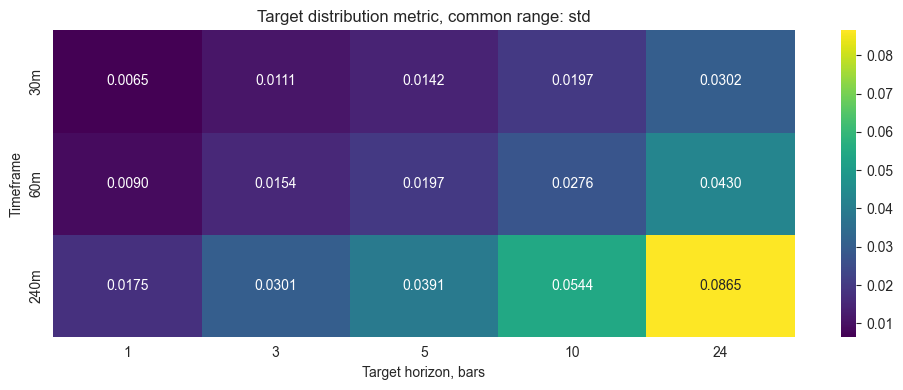

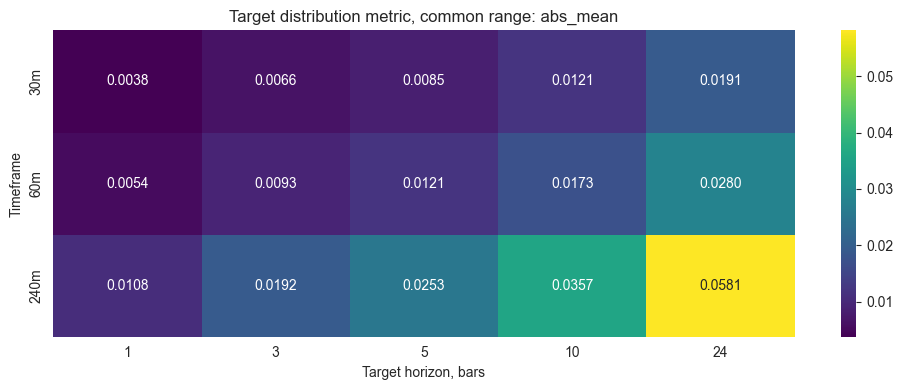

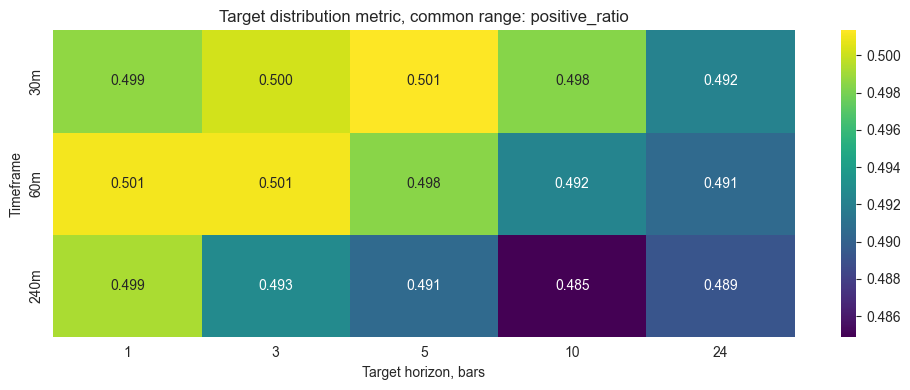

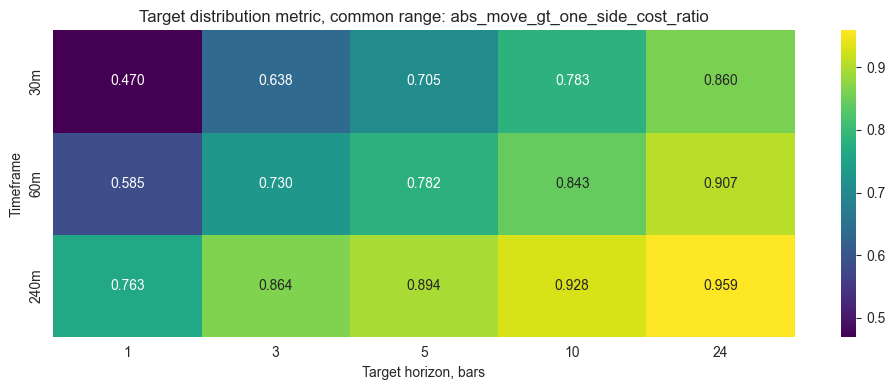

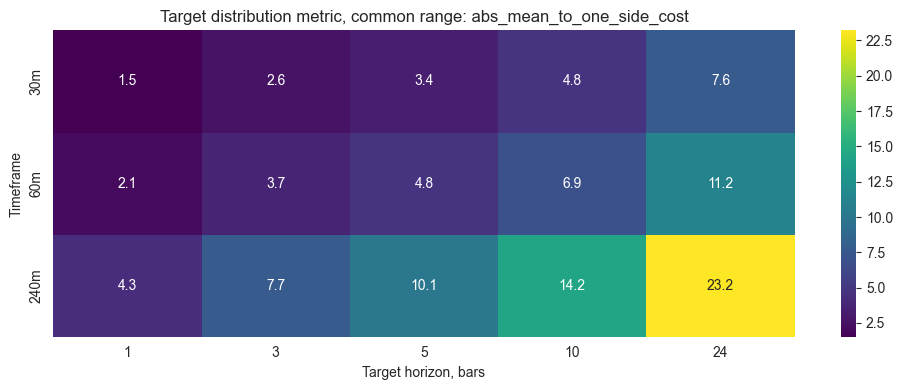

Saved common-range MTF target distribution artifacts to: D:\PythonProjects\VKR\eda\eda_multitimeframe_artifacts_common_range


In [41]:
# =====================================================================
# Multi-timeframe target distribution for horizons 1, 3, 5, 10, 24
# Common decision-timestamp range version
# =====================================================================
# This block builds targets on the full train sample first, then filters decision
# timestamps to the same common range as the MTF correlation block.

INTERVALS_FOR_MTF_TARGET_DIST = (30, 60, 240)
HORIZONS_FOR_MTF_TARGET_DIST = (1, 3, 5, 10, 24)
TRADE_COST_FOR_MTF_TARGET_DIST = 0.0025

# Fallback if this cell is run without the previous MTF-correlation cell.
if "USE_COMMON_DATE_RANGE_MTF" not in globals():
    USE_COMMON_DATE_RANGE_MTF = True
if "COMMON_START_MTF" not in globals():
    COMMON_START_MTF = pd.Timestamp("2021-11-30 16:00:00+00:00")
if "COMMON_END_MTF" not in globals():
    COMMON_END_MTF = pd.Timestamp("2024-06-26 16:00:00+00:00")
if "filter_common_mtf_decision_range" not in globals():
    def filter_common_mtf_decision_range(df, start=COMMON_START_MTF, end=COMMON_END_MTF):
        out = df.copy()
        out["timestamp"] = pd.to_datetime(out["timestamp"], utc=True)
        return (
            out.loc[out["timestamp"].between(start, end, inclusive="both")]
            .sort_values(["symbol", "timestamp"])
            .reset_index(drop=True)
        )


def _target_distribution_rows_from_target_df(
    target_df,
    horizons=(1, 3, 5, 10, 24),
    trade_cost=0.0025,
    interval_minutes=240,
    by_symbol=False,
):
    one_side_cost_log = np.log(1.0 / (1.0 - trade_cost))
    round_trip_cost_log = np.log(1.0 / ((1.0 - trade_cost) ** 2))

    rows = []
    group_iter = target_df.groupby("symbol", sort=True) if by_symbol else [(None, target_df)]

    for sym, g in group_iter:
        for h in horizons:
            target = f"target_log_ret_horizon_{h}"
            x = g[target].dropna()

            row = {
                "interval_minutes": interval_minutes,
                "interval_label": f"{interval_minutes}m",
                "target": target,
                "horizon_bars": h,
                "horizon_hours": h * interval_minutes / 60.0,
                "n": int(len(x)),
                "mean": float(x.mean()),
                "std": float(x.std()),
                "min": float(x.min()),
                "p01": float(x.quantile(0.01)),
                "p05": float(x.quantile(0.05)),
                "p25": float(x.quantile(0.25)),
                "median": float(x.median()),
                "p75": float(x.quantile(0.75)),
                "p95": float(x.quantile(0.95)),
                "p99": float(x.quantile(0.99)),
                "max": float(x.max()),
                "abs_mean": float(x.abs().mean()),
                "abs_median": float(x.abs().median()),
                "abs_p75": float(x.abs().quantile(0.75)),
                "abs_p95": float(x.abs().quantile(0.95)),
                "positive_ratio": float((x > 0).mean()),
                "one_side_long_success_ratio": float((x > one_side_cost_log).mean()),
                "one_side_short_success_ratio": float((x < -one_side_cost_log).mean()),
                "abs_move_gt_one_side_cost_ratio": float((x.abs() > one_side_cost_log).mean()),
                "abs_move_gt_round_trip_cost_ratio": float((x.abs() > round_trip_cost_log).mean()),
                "abs_mean_to_one_side_cost": float(x.abs().mean() / one_side_cost_log),
                "std_to_one_side_cost": float(x.std() / one_side_cost_log),
                "timestamp_min": g["timestamp"].min(),
                "timestamp_max": g["timestamp"].max(),
            }
            if by_symbol:
                row["symbol"] = sym
            rows.append(row)

    return pd.DataFrame(rows)


mtf_target_distribution_rows = []
mtf_target_distribution_by_symbol_rows = []
mtf_target_distribution_run_summary_rows = []

for interval_minutes in INTERVALS_FOR_MTF_TARGET_DIST:
    df_interval_raw = load_interval_ohlcv(interval_minutes)

    df_interval_phase = add_chronological_phase_by_symbol(
        df_interval_raw,
        val_bars=VAL_BARS,
        test_bars=TEST_BARS,
        embargo_bars=EMBARGO_BARS,
    )

    train_interval_raw = df_interval_phase[df_interval_phase["phase"].eq("train")].copy()

    # Build targets first, then filter decision timestamps to avoid losing future bars
    # needed to label decisions near COMMON_END_MTF.
    target_df_interval = add_targets_grouped(
        train_interval_raw,
        horizons=HORIZONS_FOR_MTF_TARGET_DIST,
    )

    if USE_COMMON_DATE_RANGE_MTF:
        target_df_interval = filter_common_mtf_decision_range(target_df_interval)

    target_cols_dist = [f"target_log_ret_horizon_{h}" for h in HORIZONS_FOR_MTF_TARGET_DIST]
    target_df_interval = target_df_interval.dropna(subset=target_cols_dist).reset_index(drop=True)

    report_interval = _target_distribution_rows_from_target_df(
        target_df_interval,
        horizons=HORIZONS_FOR_MTF_TARGET_DIST,
        trade_cost=TRADE_COST_FOR_MTF_TARGET_DIST,
        interval_minutes=interval_minutes,
        by_symbol=False,
    )
    report_interval["source_file"] = f"crypto_{interval_minutes}m_bybit_TEST.parquet"
    mtf_target_distribution_rows.append(report_interval)

    by_symbol_interval = _target_distribution_rows_from_target_df(
        target_df_interval,
        horizons=HORIZONS_FOR_MTF_TARGET_DIST,
        trade_cost=TRADE_COST_FOR_MTF_TARGET_DIST,
        interval_minutes=interval_minutes,
        by_symbol=True,
    )
    by_symbol_interval["source_file"] = f"crypto_{interval_minutes}m_bybit_TEST.parquet"
    mtf_target_distribution_by_symbol_rows.append(by_symbol_interval)

    mtf_target_distribution_run_summary_rows.append({
        "interval_minutes": interval_minutes,
        "interval_label": f"{interval_minutes}m",
        "n_rows_common_all_symbols": int(len(target_df_interval)),
        "n_rows_common_per_symbol_mean": float(target_df_interval.groupby("symbol").size().mean()),
        "timestamp_min": target_df_interval["timestamp"].min(),
        "timestamp_max": target_df_interval["timestamp"].max(),
    })

mtf_target_distribution = pd.concat(mtf_target_distribution_rows, ignore_index=True)
mtf_target_distribution_by_symbol = pd.concat(mtf_target_distribution_by_symbol_rows, ignore_index=True)
mtf_target_distribution_run_summary = pd.DataFrame(mtf_target_distribution_run_summary_rows)

# Column order for readability.
first_cols = [
    "interval_minutes", "interval_label", "horizon_bars", "horizon_hours", "target", "n",
]
other_cols = [c for c in mtf_target_distribution.columns if c not in first_cols]
mtf_target_distribution = mtf_target_distribution[first_cols + other_cols]

print("COMMON RANGE USED:", COMMON_START_MTF, "->", COMMON_END_MTF)
print("TARGET DISTRIBUTION RUN SUMMARY")
display(mtf_target_distribution_run_summary)

print("TARGET DISTRIBUTION — ALL SYMBOLS POOLED")
display(mtf_target_distribution.sort_values(["interval_minutes", "horizon_bars"]))

print("TARGET DISTRIBUTION — BY SYMBOL")
display(mtf_target_distribution_by_symbol.sort_values(["interval_minutes", "symbol", "horizon_bars"]).head(100))

# Heatmaps for thesis discussion.
for metric, fmt in [
    ("std", ".4f"),
    ("abs_mean", ".4f"),
    ("positive_ratio", ".3f"),
    ("abs_move_gt_one_side_cost_ratio", ".3f"),
    ("abs_mean_to_one_side_cost", ".1f"),
]:
    heat = mtf_target_distribution.pivot(
        index="interval_label",
        columns="horizon_bars",
        values=metric,
    ).reindex([f"{x}m" for x in INTERVALS_FOR_MTF_TARGET_DIST])

    plt.figure(figsize=(10, 4))
    sns.heatmap(heat, annot=True, fmt=fmt, cmap="viridis")
    plt.title(f"Target distribution metric, common range: {metric}")
    plt.xlabel("Target horizon, bars")
    plt.ylabel("Timeframe")
    plt.tight_layout()
    plt.show()

# Optional export.
MTF_OUTPUT_DIR = Path("eda_multitimeframe_artifacts_common_range")
MTF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
mtf_target_distribution.to_csv(MTF_OUTPUT_DIR / "mtf_target_distribution_pooled_common_range.csv", index=False)
mtf_target_distribution_by_symbol.to_csv(MTF_OUTPUT_DIR / "mtf_target_distribution_by_symbol_common_range.csv", index=False)
mtf_target_distribution_run_summary.to_csv(MTF_OUTPUT_DIR / "mtf_target_distribution_run_summary_common_range.csv", index=False)

print("Saved common-range MTF target distribution artifacts to:", MTF_OUTPUT_DIR.resolve())


In [42]:
calendar_check = (
    mtf_target_distribution
    .loc[
        (
            ((mtf_target_distribution["interval_minutes"] == 30) & (mtf_target_distribution["horizon_bars"] == 10)) |
            ((mtf_target_distribution["interval_minutes"] == 60) & (mtf_target_distribution["horizon_bars"] == 5)) |
            ((mtf_target_distribution["interval_minutes"] == 30) & (mtf_target_distribution["horizon_bars"] == 24)) |
            ((mtf_target_distribution["interval_minutes"] == 240) & (mtf_target_distribution["horizon_bars"] == 3))
        ),
        [
            "horizon_hours",
            "interval_label",
            "horizon_bars",
            "std",
            "abs_mean",
            "abs_move_gt_one_side_cost_ratio",
        ]
    ]
    .copy()
)

calendar_check["Calendar horizon"] = calendar_check["horizon_hours"].astype(str) + "h"
calendar_check["TF / bars"] = (
    calendar_check["interval_label"].astype(str)
    + " h="
    + calendar_check["horizon_bars"].astype(str)
)

calendar_check = (
    calendar_check[
        [
            "Calendar horizon",
            "TF / bars",
            "std",
            "abs_mean",
            "abs_move_gt_one_side_cost_ratio",
        ]
    ]
    .sort_values(["Calendar horizon", "TF / bars"])
    .reset_index(drop=True)
)

calendar_check

,Calendar horizon,TF / bars,std,abs_mean,abs_move_gt_one_side_cost_ratio
0,12.0h,240m h=3,0.030085,0.019187,0.864206
1,12.0h,30m h=24,0.030171,0.019103,0.859805
2,5.0h,30m h=10,0.019746,0.012068,0.783010
3,5.0h,60m h=5,0.019681,0.012071,0.782118


In [43]:
calendar_corr_check = (
    target_power_mtf_summary
    .loc[
        (
            ((target_power_mtf_summary["interval_minutes"] == 30) & (target_power_mtf_summary["horizon_bars"] == 24)) |
            ((target_power_mtf_summary["interval_minutes"] == 240) & (target_power_mtf_summary["horizon_bars"] == 3))
        ),
        [
            "horizon_hours",
            "interval_label",
            "horizon_bars",
            "top5_mean_abs_corr_mean",
        ]
    ]
    .copy()
)

calendar_corr_check["Calendar horizon"] = (
    calendar_corr_check["horizon_hours"].astype(str) + "h"
)

calendar_corr_check["TF / bars"] = (
    calendar_corr_check["interval_label"].astype(str)
    + " h="
    + calendar_corr_check["horizon_bars"].astype(str)
)

calendar_corr_check = (
    calendar_corr_check[
        [
            "Calendar horizon",
            "TF / bars",
            "top5_mean_abs_corr_mean",
        ]
    ]
    .rename(columns={
        "top5_mean_abs_corr_mean": "top-5 mean abs corr"
    })
    .sort_values(["Calendar horizon", "TF / bars"])
    .reset_index(drop=True)
)

with pd.option_context("display.float_format", lambda x: str(x)):
    display(calendar_corr_check)

,Calendar horizon,TF / bars,top-5 mean abs corr
0,12.0h,240m h=3,0.05384292058577302
1,12.0h,30m h=24,0.04996655950276777


In [44]:
mtf_target_distribution[['interval_minutes', 'interval_label', 'horizon_bars', 'horizon_hours', 'positive_ratio']]

,interval_minutes,interval_label,horizon_bars,horizon_hours,positive_ratio
0,30,30m,1,0.5,0.498591
1,30,30m,3,1.5,0.500206
2,30,30m,5,2.5,0.501342
3,30,30m,10,5.0,0.498360
4,30,30m,24,12.0,0.492135
5,60,60m,1,1.0,0.501078
6,60,60m,3,3.0,0.501060
7,60,60m,5,5.0,0.498443
8,60,60m,10,10.0,0.492293
9,60,60m,24,24.0,0.490536


In [45]:
mtf_target_distribution[['interval_minutes', 'interval_label', 'horizon_bars', 'horizon_hours', 'abs_move_gt_one_side_cost_ratio', 'abs_move_gt_round_trip_cost_ratio']]

,interval_minutes,interval_label,horizon_bars,horizon_hours,abs_move_gt_one_side_cost_ratio,abs_move_gt_round_trip_cost_ratio
0,30,30m,1,0.5,0.469949,0.232321
1,30,30m,3,1.5,0.637575,0.410033
2,30,30m,5,2.5,0.705021,0.496488
3,30,30m,10,5.0,0.783010,0.612198
4,30,30m,24,12.0,0.859805,0.739800
5,60,60m,1,1.0,0.584541,0.343639
6,60,60m,3,3.0,0.730284,0.529591
7,60,60m,5,5.0,0.782118,0.613915
8,60,60m,10,10.0,0.843484,0.713981
9,60,60m,24,24.0,0.906642,0.820180


In [46]:
def plot_feature_distributions(dataframe, symbol):
    '''
    Строит графики распределения по признакам для актива
    '''
    if symbol not in ALL_SYMBOLS:
        raise ValueError(
            f"Актив {symbol} отсутствует. Список доступных активов: {ALL_SYMBOLS}"
        )

    df_asset = dataframe[dataframe['symbol'] == symbol]

    columns = df_asset.columns.difference(meta_cols)

    if columns.empty:
        raise ValueError(
            f"В переданном датафрейме нет колонок признаков. Только мета-колонки."
        )

    num_cols = len(columns)
    cols_per_row = 5
    rows = (num_cols + cols_per_row - 1) // cols_per_row

    fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4), constrained_layout=True)
    axes = axes.flatten()

    for i, col in enumerate(columns):
        sns.histplot(data=df_asset, x=col, ax=axes[i])
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=45)

    # Удаляем лишние пустые графики (если признаки закончились)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Графики распределений признаков для актива {symbol}", fontsize=16)
    plt.show()

In [47]:
from data_processing.functions.transform_indicators import map_indicator_category

symbol = ALL_SYMBOLS[0]

CONFIG_FOR_INDICATORS = {
    "ema_periods": [9, 21, 50, 100, 200],
    "momentum_indicators_periods": [14, 30, 72],
    "return_indicators_periods": [6, 24, 72, 168],
    "volatility_indicators_periods": [24, 72, 168],
    "level_periods": [24, 72, 168],
    "vol_ma_period": [24, 72, 168],
    "range_ma_period": [24, 72, 168],
}

Z_SCORE_WINDOW_FOR_EDA = 24
CLIP_VALUE = 5.0


df_asset = train_df[train_df["symbol"] == symbol].copy()

indicators_asset = stream_TA_lib(
    df=df_asset,
    meta_cols=meta_cols,
    **CONFIG_FOR_INDICATORS,
)

indicators_asset = (
    indicators_asset
    .dropna()
    .sort_values(["symbol", "timestamp"])
    .reset_index(drop=True)
)

df_asset_with_indicators = (
    indicators_asset
    .sort_values("timestamp")
    .reset_index(drop=True)
)

df_transform_indicators_asset = transform_indicators_df(
    df_asset_with_indicators,
    meta_cols=meta_cols,
)

df_z_score_indicators_asset = rolling_z_score_clip_df(
    df_transform_indicators_asset,
    meta_cols=meta_cols,
    window=Z_SCORE_WINDOW_FOR_EDA,
    clip_value=CLIP_VALUE,
    shift_by_one=True,
)

df_z_score_indicators_asset_clean = (
    df_z_score_indicators_asset
    .dropna()
    .reset_index(drop=True)
)

# Проверки новой fixed-логики: эти признаки НЕ должны попасть в transformed/z-score feature space.
forbidden_transformed_prefixes = (
    "ema_",       # raw EMA-levels; ema_slope / ema_spread разрешены ниже отдельной проверкой
    "vol_ma_",    # absolute volume moving average
    "range_ma_",  # absolute range moving average
    "MOM_",       # old absolute MOM
)

bad_cols = []

for col in df_transform_indicators_asset.columns:
    if col in meta_cols:
        continue

    cat = map_indicator_category(col)

    if cat == "skip":
        bad_cols.append(col)

if bad_cols:
    raise ValueError(
        f"В transformed indicators остались признаки, которые должны были быть skipped: {bad_cols}"
    )

if bad_cols:
    raise ValueError(f"В transformed indicators остались запрещённые absolute/non-stationary признаки: {bad_cols}")

expected_new_cols = [
    col for col in df_transform_indicators_asset.columns
    if col.startswith(("MOM_pct", "MACD_hist_pct"))
]
print("New percentage momentum columns:", expected_new_cols)

print("Raw indicators columns:", len(indicators_asset.columns))
print("Transformed feature columns:", len([c for c in df_transform_indicators_asset.columns if c not in meta_cols]))
print("Z-score feature columns:", len([c for c in df_z_score_indicators_asset_clean.columns if c not in meta_cols]))

display(indicators_asset.head())
display(df_transform_indicators_asset.head())
display(df_z_score_indicators_asset_clean.head())

print(indicators_asset.shape)
print(df_transform_indicators_asset.shape)
print(df_z_score_indicators_asset.shape)
print(df_z_score_indicators_asset_clean.shape)

New percentage momentum columns: ['MOM_pct_14', 'MOM_pct_30', 'MOM_pct_72', 'MACD_hist_pct']
Raw indicators columns: 73
Transformed feature columns: 54
Z-score feature columns: 54


,timestamp,symbol,open,high,low,close,volume,future_close_price,ema_9,dist_ema_9,...,vol_expansion_168,dist_to_high_24,dist_to_low_24,price_pos_in_range_24,dist_to_high_72,dist_to_low_72,price_pos_in_range_72,dist_to_high_168,dist_to_low_168,price_pos_in_range_168
0,2021-11-24 08:00:00+00:00,BTCUSDT,56513.12,57415.75,56360.00,56632.83,45.388277,56755.10,56858.515641,-0.003969,...,0.967103,0.059456,0.022144,0.271376,0.170583,0.022144,0.114900,0.217796,0.022144,0.092291
1,2021-11-24 12:00:00+00:00,BTCUSDT,56632.83,57150.00,55904.28,56755.10,87.868030,56845.23,56837.832513,-0.001456,...,1.137623,0.057174,0.024251,0.297834,0.168061,0.024251,0.126103,0.215172,0.024251,0.101289
2,2021-11-24 16:00:00+00:00,BTCUSDT,56755.10,57123.90,56500.00,56845.23,99.815091,57165.63,56839.312010,0.000104,...,0.569951,0.055498,0.025798,0.317337,0.166209,0.025798,0.134360,0.213245,0.025798,0.107922
3,2021-11-24 20:00:00+00:00,BTCUSDT,56845.23,57470.00,56742.02,57165.63,121.127979,57720.00,56904.575608,0.004588,...,0.662637,0.049582,0.031258,0.386669,0.159673,0.031258,0.163715,0.206445,0.031258,0.131501
4,2021-11-25 00:00:00+00:00,BTCUSDT,57165.63,58281.84,57129.61,57720.00,125.438034,57643.99,57067.660487,0.011431,...,1.037837,0.039501,0.040563,0.506629,0.148534,0.040563,0.214507,0.194858,0.040563,0.172298


,timestamp,symbol,open,high,low,close,volume,future_close_price,dist_ema_9,ema_slope_9,...,vol_expansion_168_log1p,dist_to_high_24_sqrt,dist_to_low_24_sqrt,price_pos_in_range_24_norm,dist_to_high_72_sqrt,dist_to_low_72_sqrt,price_pos_in_range_72_norm,dist_to_high_168_sqrt,dist_to_low_168_sqrt,price_pos_in_range_168_norm
0,2021-11-24 08:00:00+00:00,BTCUSDT,56513.12,57415.75,56360.00,56632.83,45.388277,56755.10,-0.003969,-0.000217,...,0.676562,0.243836,0.148810,-0.228624,0.413017,0.148810,-0.385100,0.466686,0.148810,-0.407709
1,2021-11-24 12:00:00+00:00,BTCUSDT,56632.83,57150.00,55904.28,56755.10,87.868030,56845.23,-0.001456,-0.000681,...,0.759694,0.239110,0.155727,-0.202166,0.409952,0.155727,-0.373897,0.463866,0.155727,-0.398711
2,2021-11-24 16:00:00+00:00,BTCUSDT,56755.10,57123.90,56500.00,56845.23,99.815091,57165.63,0.000104,-0.003993,...,0.451044,0.235579,0.160618,-0.182663,0.407687,0.160618,-0.365640,0.461785,0.160618,-0.392078
3,2021-11-24 20:00:00+00:00,BTCUSDT,56845.23,57470.00,56742.02,57165.63,121.127979,57720.00,0.004588,-0.004609,...,0.508405,0.222670,0.176800,-0.113331,0.399590,0.176800,-0.336285,0.454363,0.176800,-0.368499
4,2021-11-25 00:00:00+00:00,BTCUSDT,57165.63,58281.84,57129.61,57720.00,125.438034,57643.99,0.011431,0.000917,...,0.711889,0.198749,0.201401,0.006629,0.385402,0.201401,-0.285493,0.441427,0.201401,-0.327702


,timestamp,symbol,open,high,low,close,volume,future_close_price,dist_ema_9_z,ema_slope_9_z,...,vol_expansion_168_log1p_z,dist_to_high_24_sqrt_z,dist_to_low_24_sqrt_z,price_pos_in_range_24_norm,dist_to_high_72_sqrt_z,dist_to_low_72_sqrt_z,price_pos_in_range_72_norm,dist_to_high_168_sqrt_z,dist_to_low_168_sqrt_z,price_pos_in_range_168_norm
0,2021-11-28 08:00:00+00:00,BTCUSDT,54525.20,54931.00,54141.40,54486.00,58.940078,54286.08,0.158559,0.110174,...,-0.402723,0.795736,-0.460328,-0.332277,-1.278021,-0.460328,-0.374968,0.861796,-0.460328,-0.436252
1,2021-11-28 12:00:00+00:00,BTCUSDT,54486.00,54626.64,54048.19,54286.08,72.092704,54614.86,0.039798,0.078114,...,-0.939916,0.846587,-0.712138,-0.366284,-1.208085,-0.712138,-0.396822,0.909534,-0.712138,-0.449178
2,2021-11-28 16:00:00+00:00,BTCUSDT,54286.08,54950.00,53272.61,54614.86,169.768599,57276.97,0.368134,0.109721,...,1.468101,0.641826,-0.005057,-0.280180,-1.332209,-0.005057,-0.328927,0.669858,-0.005057,-0.414477
3,2021-11-28 20:00:00+00:00,BTCUSDT,54614.86,57419.85,54614.86,57276.97,240.918256,57330.88,2.424521,0.634533,...,2.692896,-0.842317,1.984710,0.155795,-3.195369,1.984710,0.026634,-0.804831,1.984710,-0.244857
4,2021-11-29 00:00:00+00:00,BTCUSDT,57276.97,58228.96,57131.12,57330.88,150.271409,57495.03,1.767992,1.151238,...,0.011158,-0.850115,1.807944,0.164623,-2.602494,1.807944,0.033724,-0.829972,1.807944,-0.241423


(5698, 73)
(5698, 62)
(5698, 62)
(5674, 62)


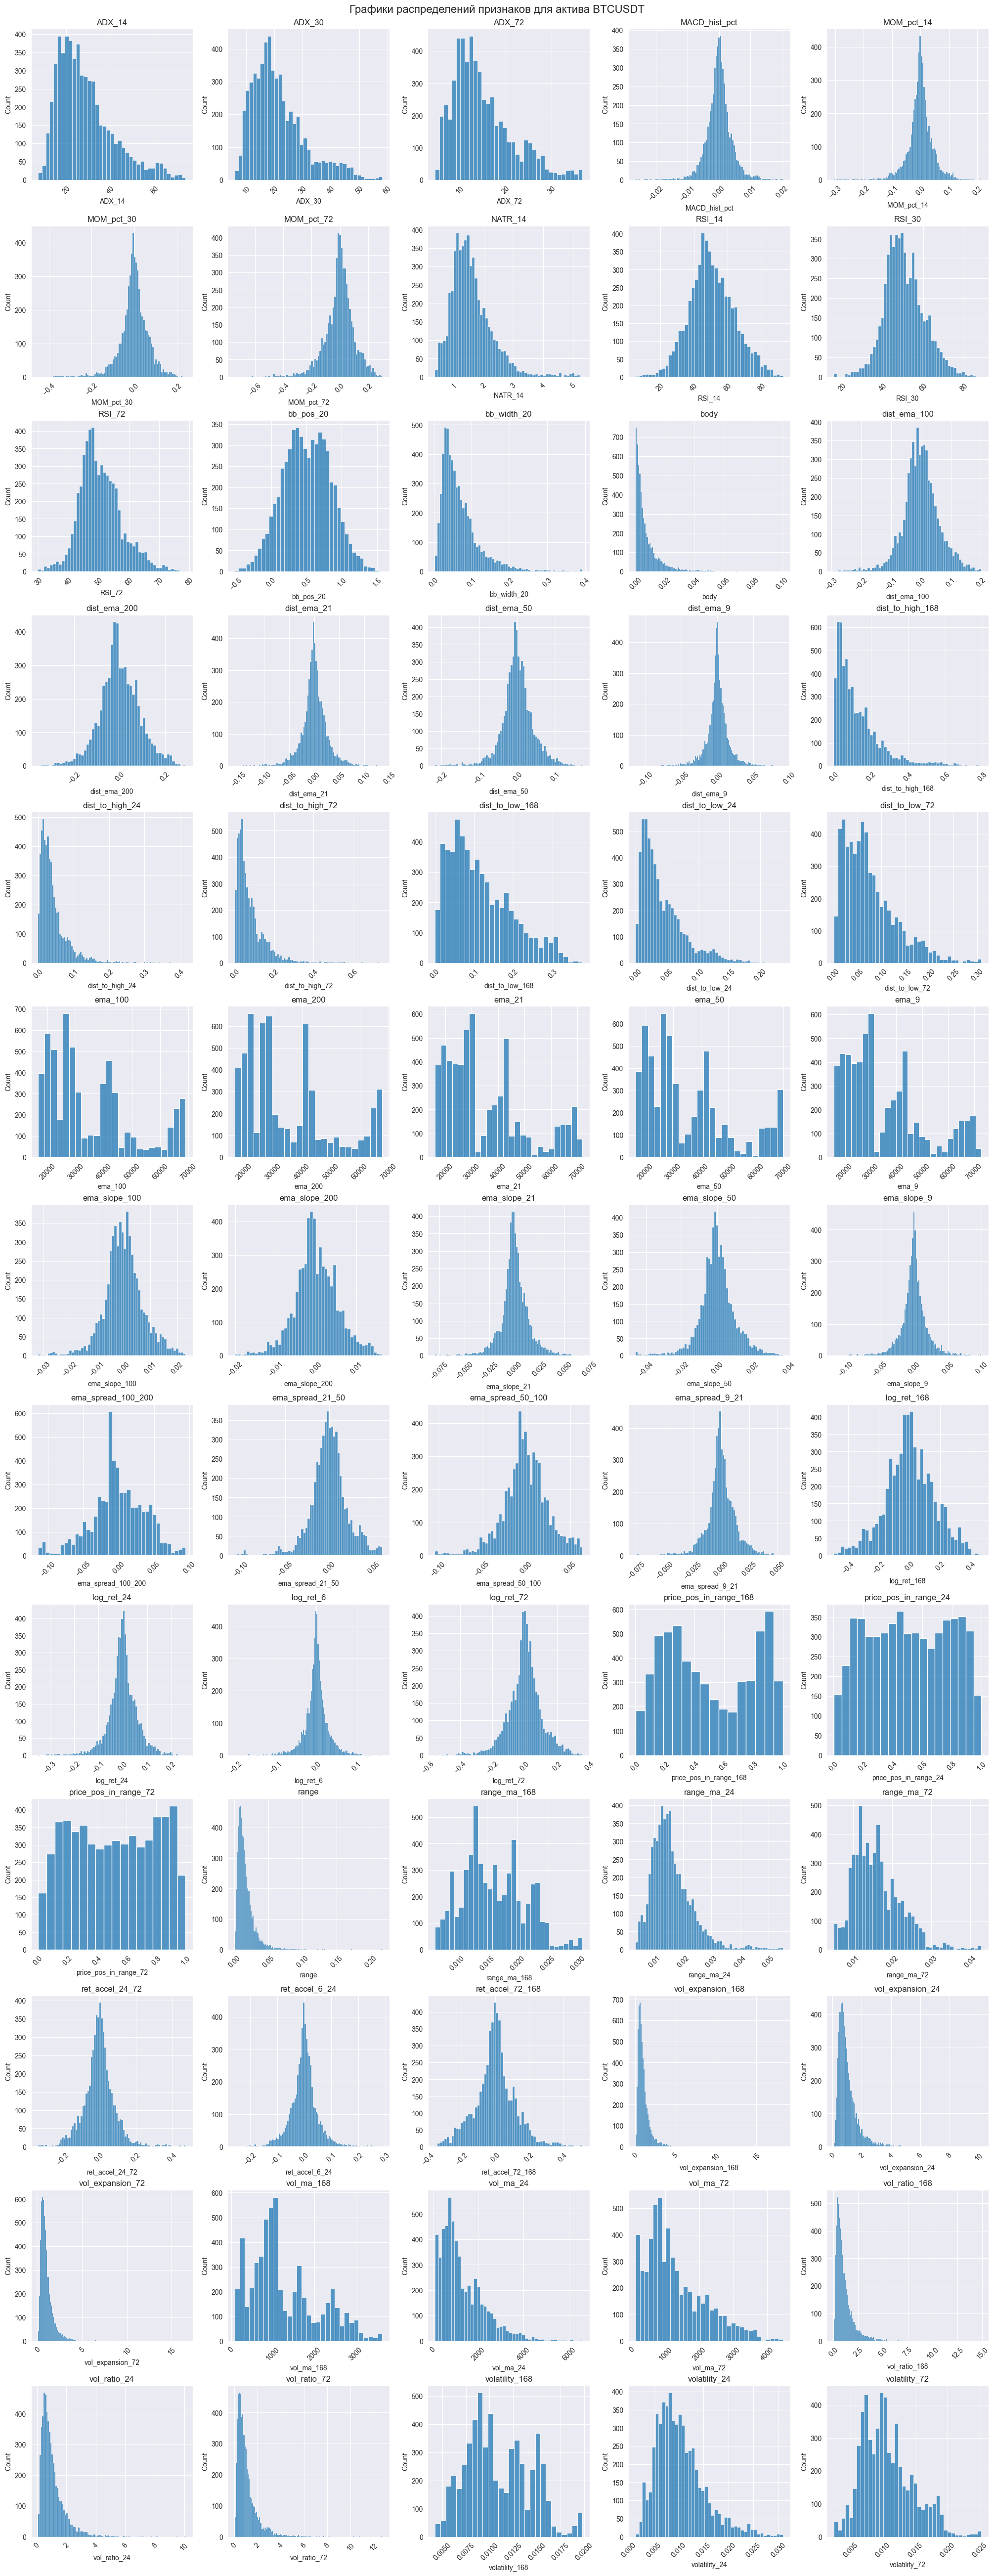

In [48]:
plot_feature_distributions(dataframe=df_asset_with_indicators, symbol=symbol)

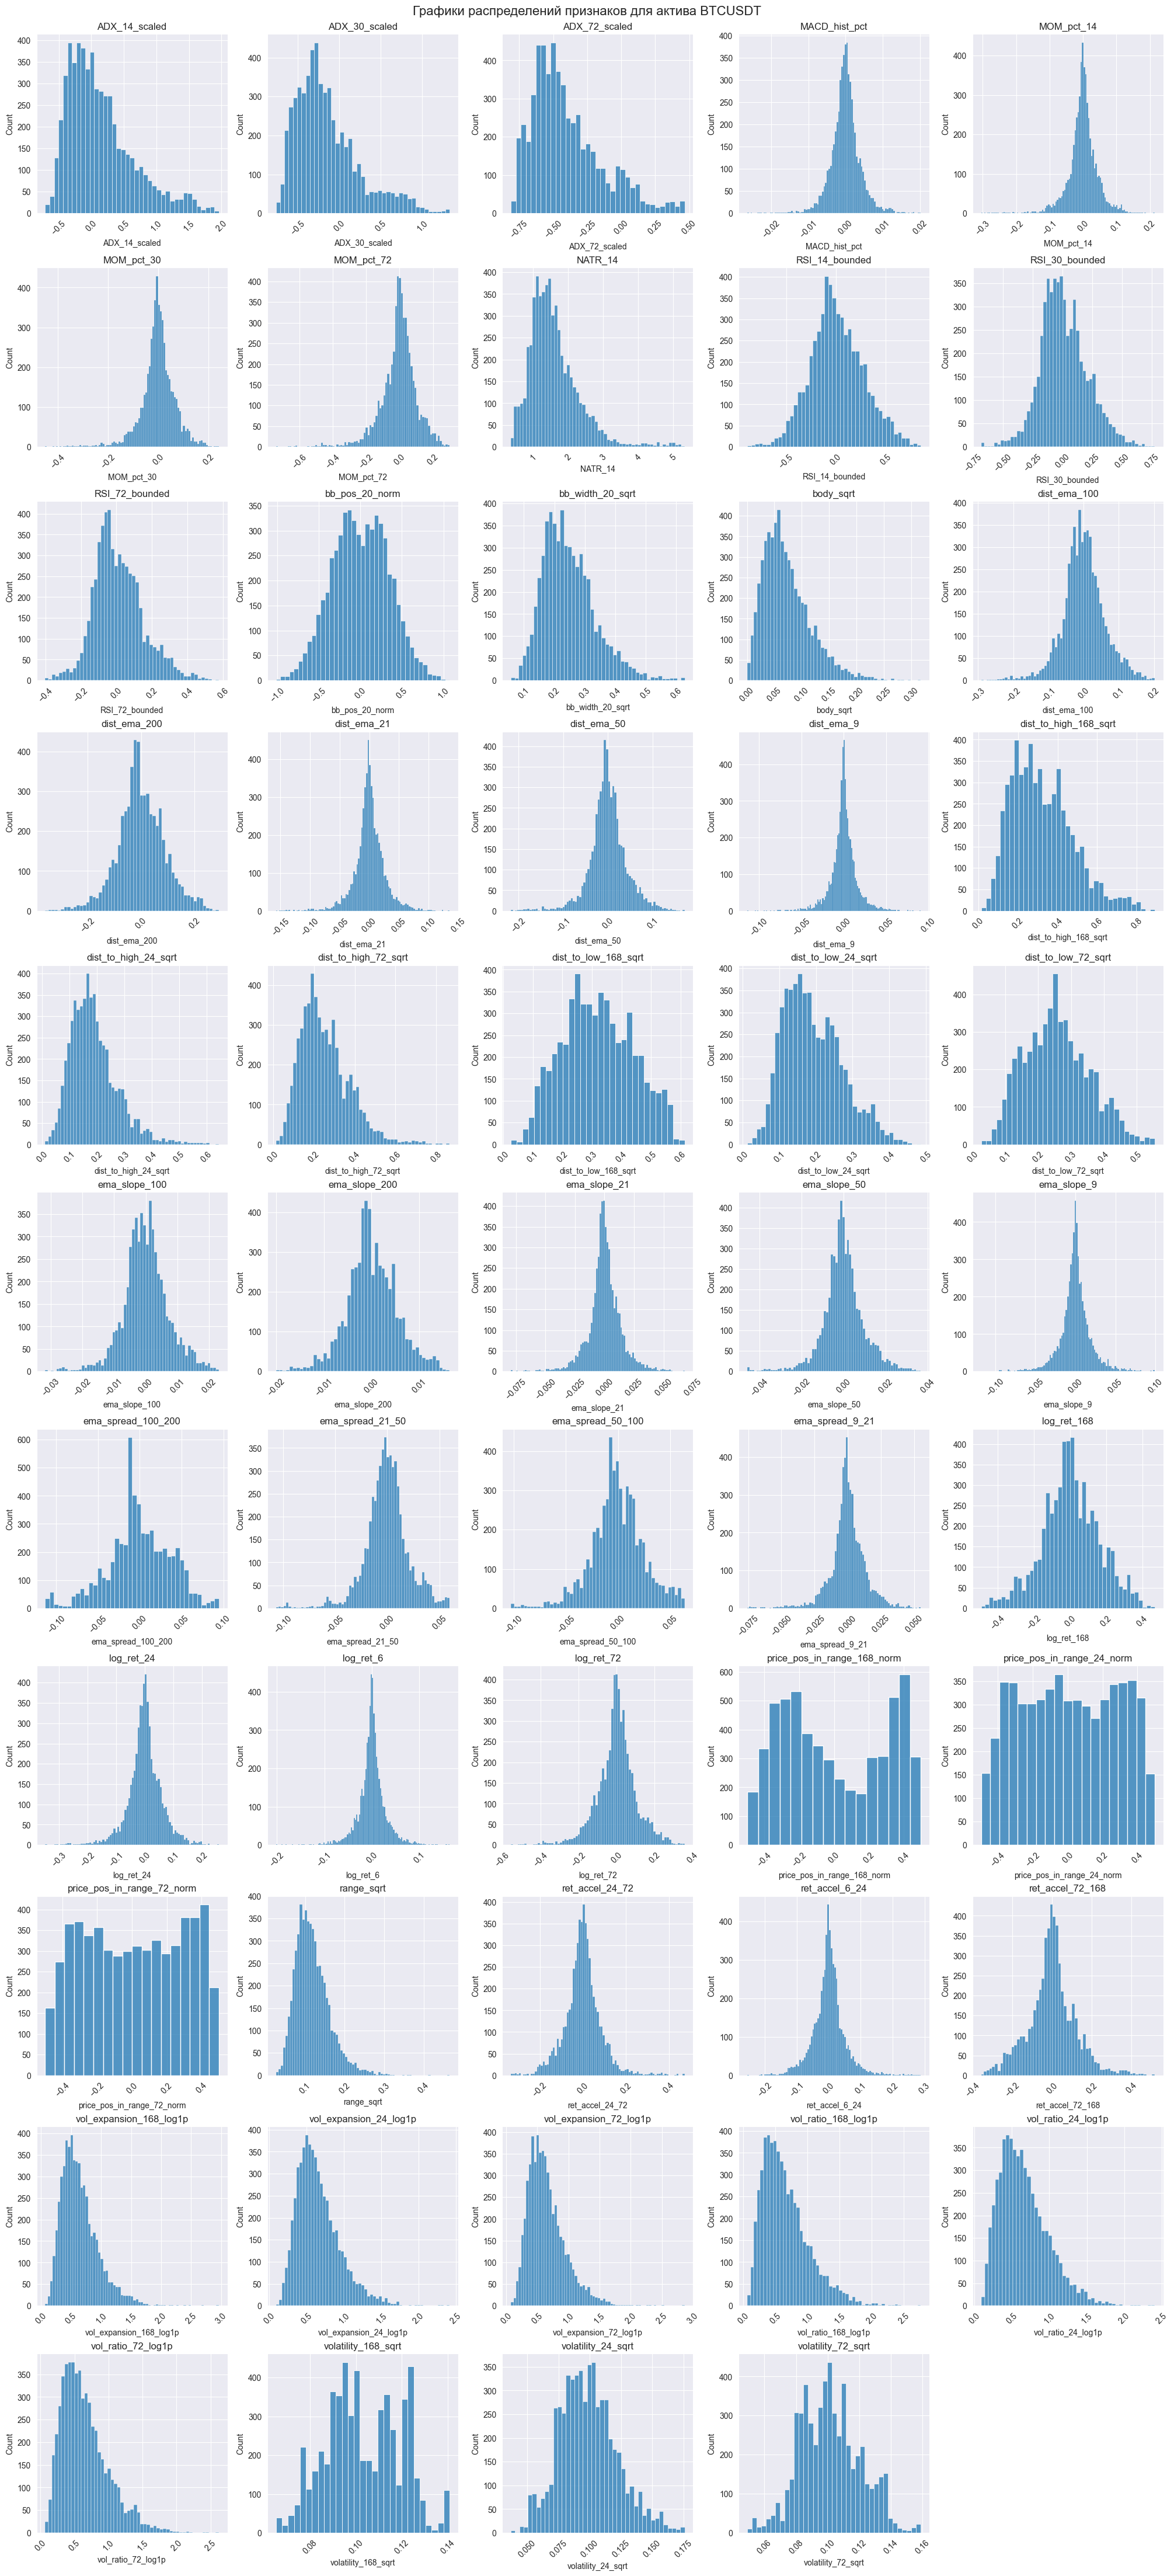

In [49]:
plot_feature_distributions(dataframe=df_transform_indicators_asset, symbol=symbol)

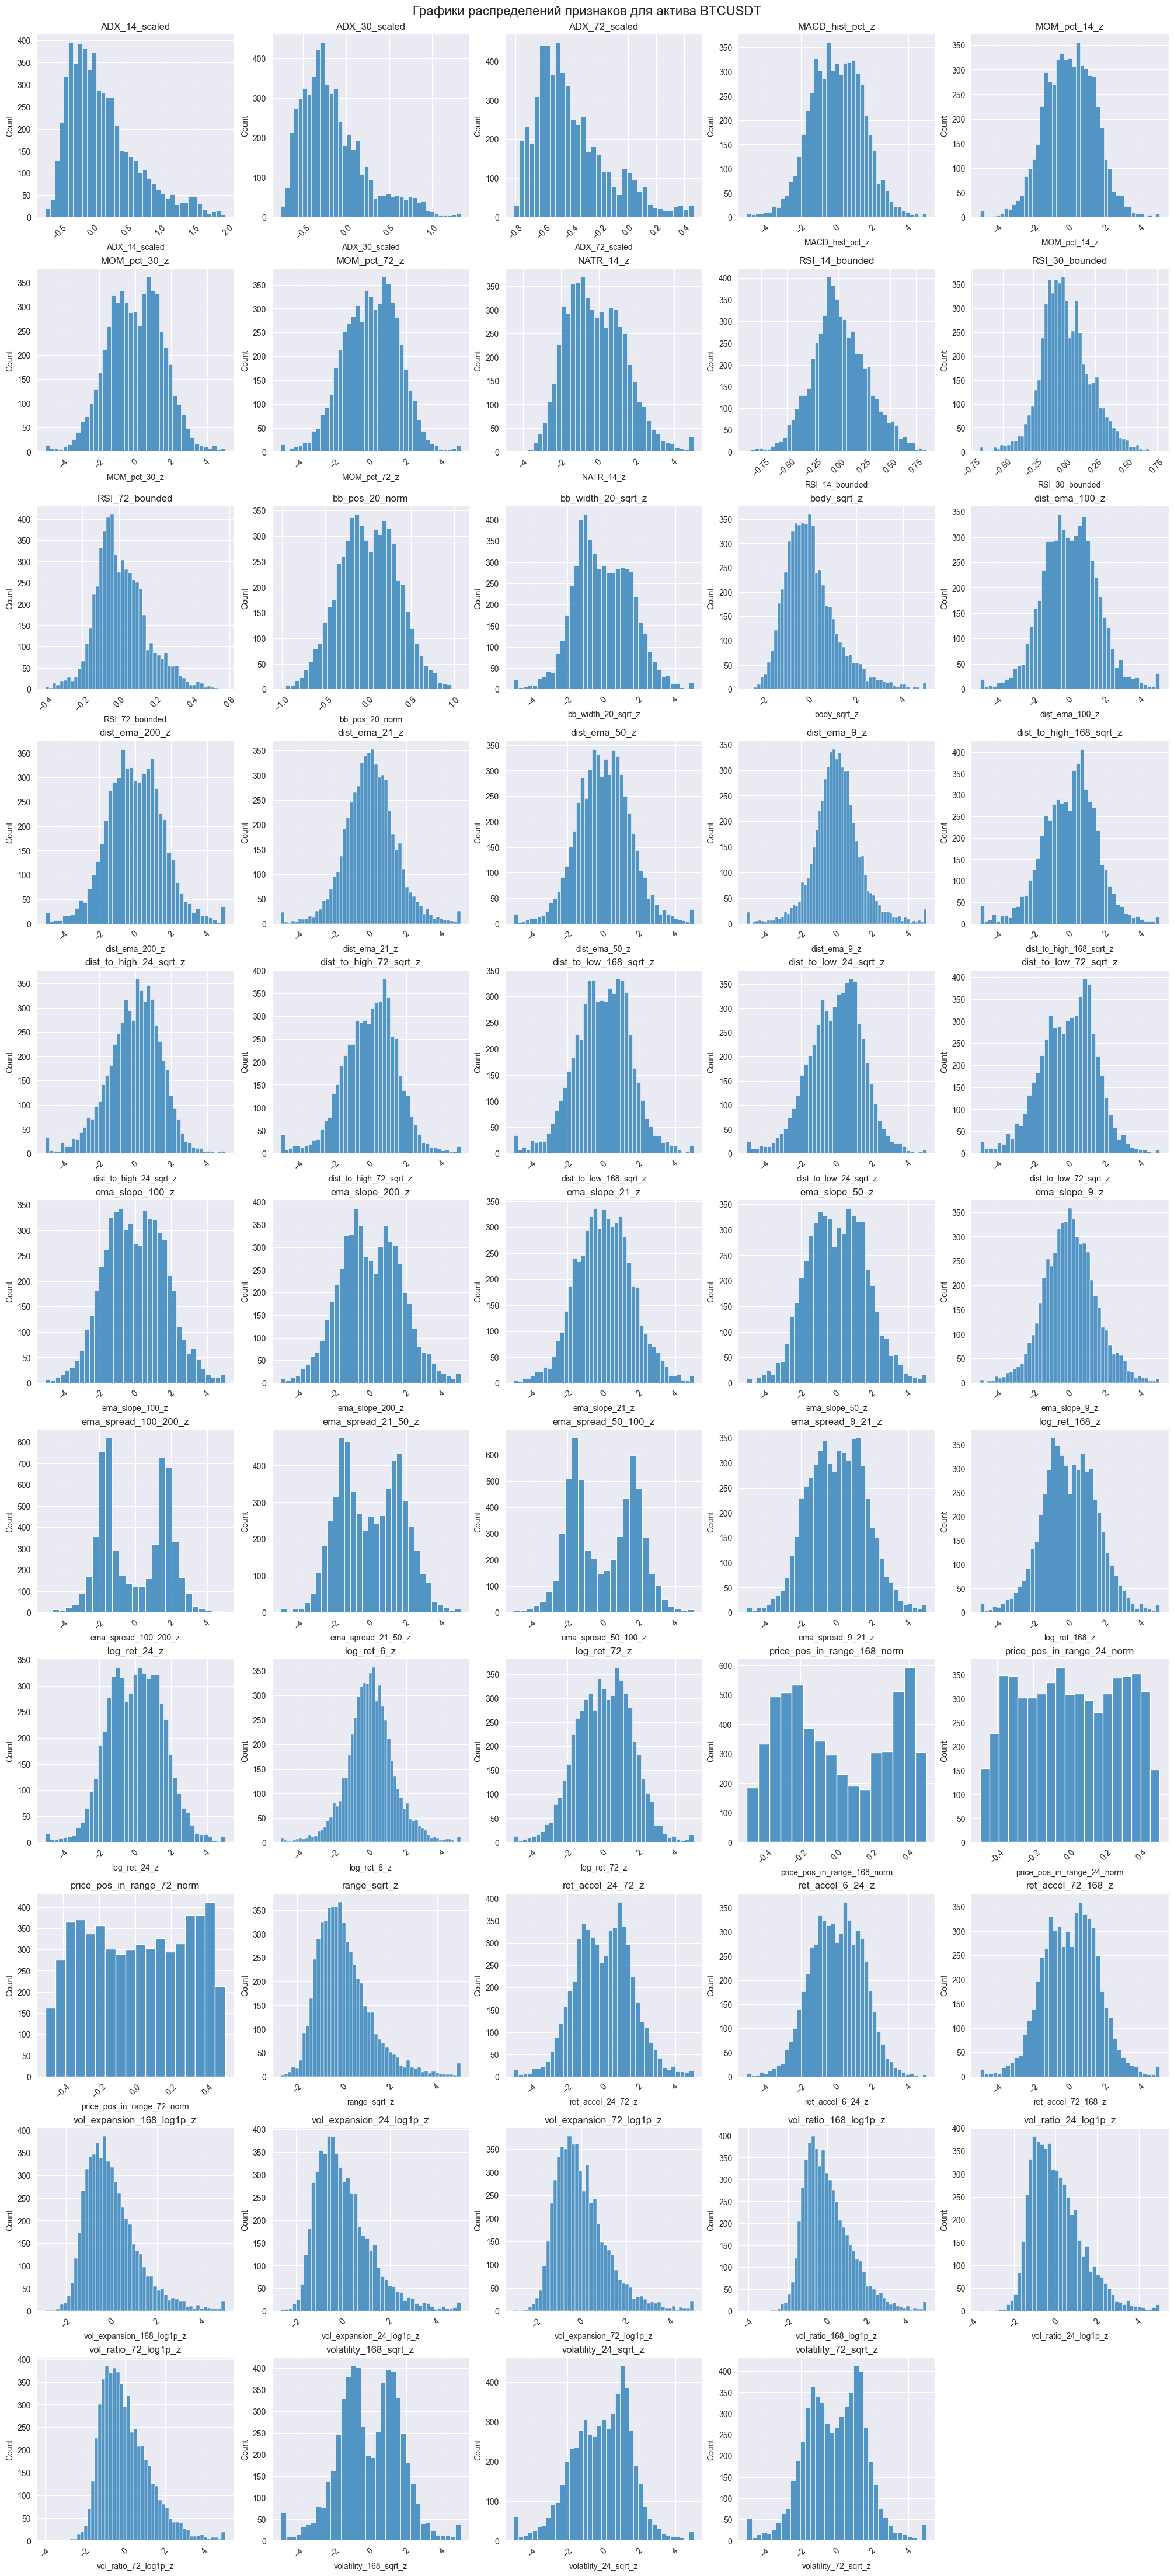

In [50]:
plot_feature_distributions(dataframe=df_z_score_indicators_asset, symbol=symbol)

**Матрица корреляций**

In [51]:
HORIZONS_FOR_TARGET_CORR = (1, 3, 5, 10, 24)

# Данные уже z-score transformed и очищены от NaN выше.
df_corr = (
    df_z_score_indicators_asset_clean
    .sort_values(["symbol", "timestamp"])
    .reset_index(drop=True)
    .copy()
)

# Строим все target горизонты внутри каждого symbol.
# Для одного актива это тоже полезно: логика полностью совпадает с multi-symbol pipeline.
df_corr = add_targets_grouped(
    df_corr,
    horizons=HORIZONS_FOR_TARGET_CORR,
)

target_cols = [
    f"target_log_ret_horizon_{h}"
    for h in HORIZONS_FOR_TARGET_CORR
]

print("Target horizons:", HORIZONS_FOR_TARGET_CORR)
print("Target columns:", target_cols)
print("df_corr shape:", df_corr.shape)


Target horizons: (1, 3, 5, 10, 24)
Target columns: ['target_log_ret_horizon_1', 'target_log_ret_horizon_3', 'target_log_ret_horizon_5', 'target_log_ret_horizon_10', 'target_log_ret_horizon_24']
df_corr shape: (5650, 67)


In [52]:
# Fixed transform уже исключает EMA-levels / vol_ma / range_ma / old MOM / old MACD_hist.
# Фильтр оставлен как safety-net, если notebook случайно будет запущен со старой transform-функцией.
ema_level_cols = [
    col for col in df_corr.columns
    if col.startswith("ema_")
    and not col.startswith(("ema_slope", "ema_spread"))
]

forbidden_cols = [
    col for col in df_corr.columns
    if col.startswith(("vol_ma_", "range_ma_"))
    or (col.startswith("MOM_") and not col.startswith("MOM_pct"))
    or col == "MACD_hist"
]

non_feature_cols = set(meta_cols) | {"phase"}

feature_cols = [
    col for col in df_corr.columns
    if col not in non_feature_cols
    and col not in target_cols
    and col not in ema_level_cols
    and col not in forbidden_cols
]

cols_for_corr = feature_cols + target_cols

print("Features for correlation:", len(feature_cols))
print("Targets for correlation:", len(target_cols))
print("Excluded EMA-level cols:", ema_level_cols)
print("Excluded forbidden cols:", forbidden_cols)


Features for correlation: 54
Targets for correlation: 5
Excluded EMA-level cols: []
Excluded forbidden cols: []


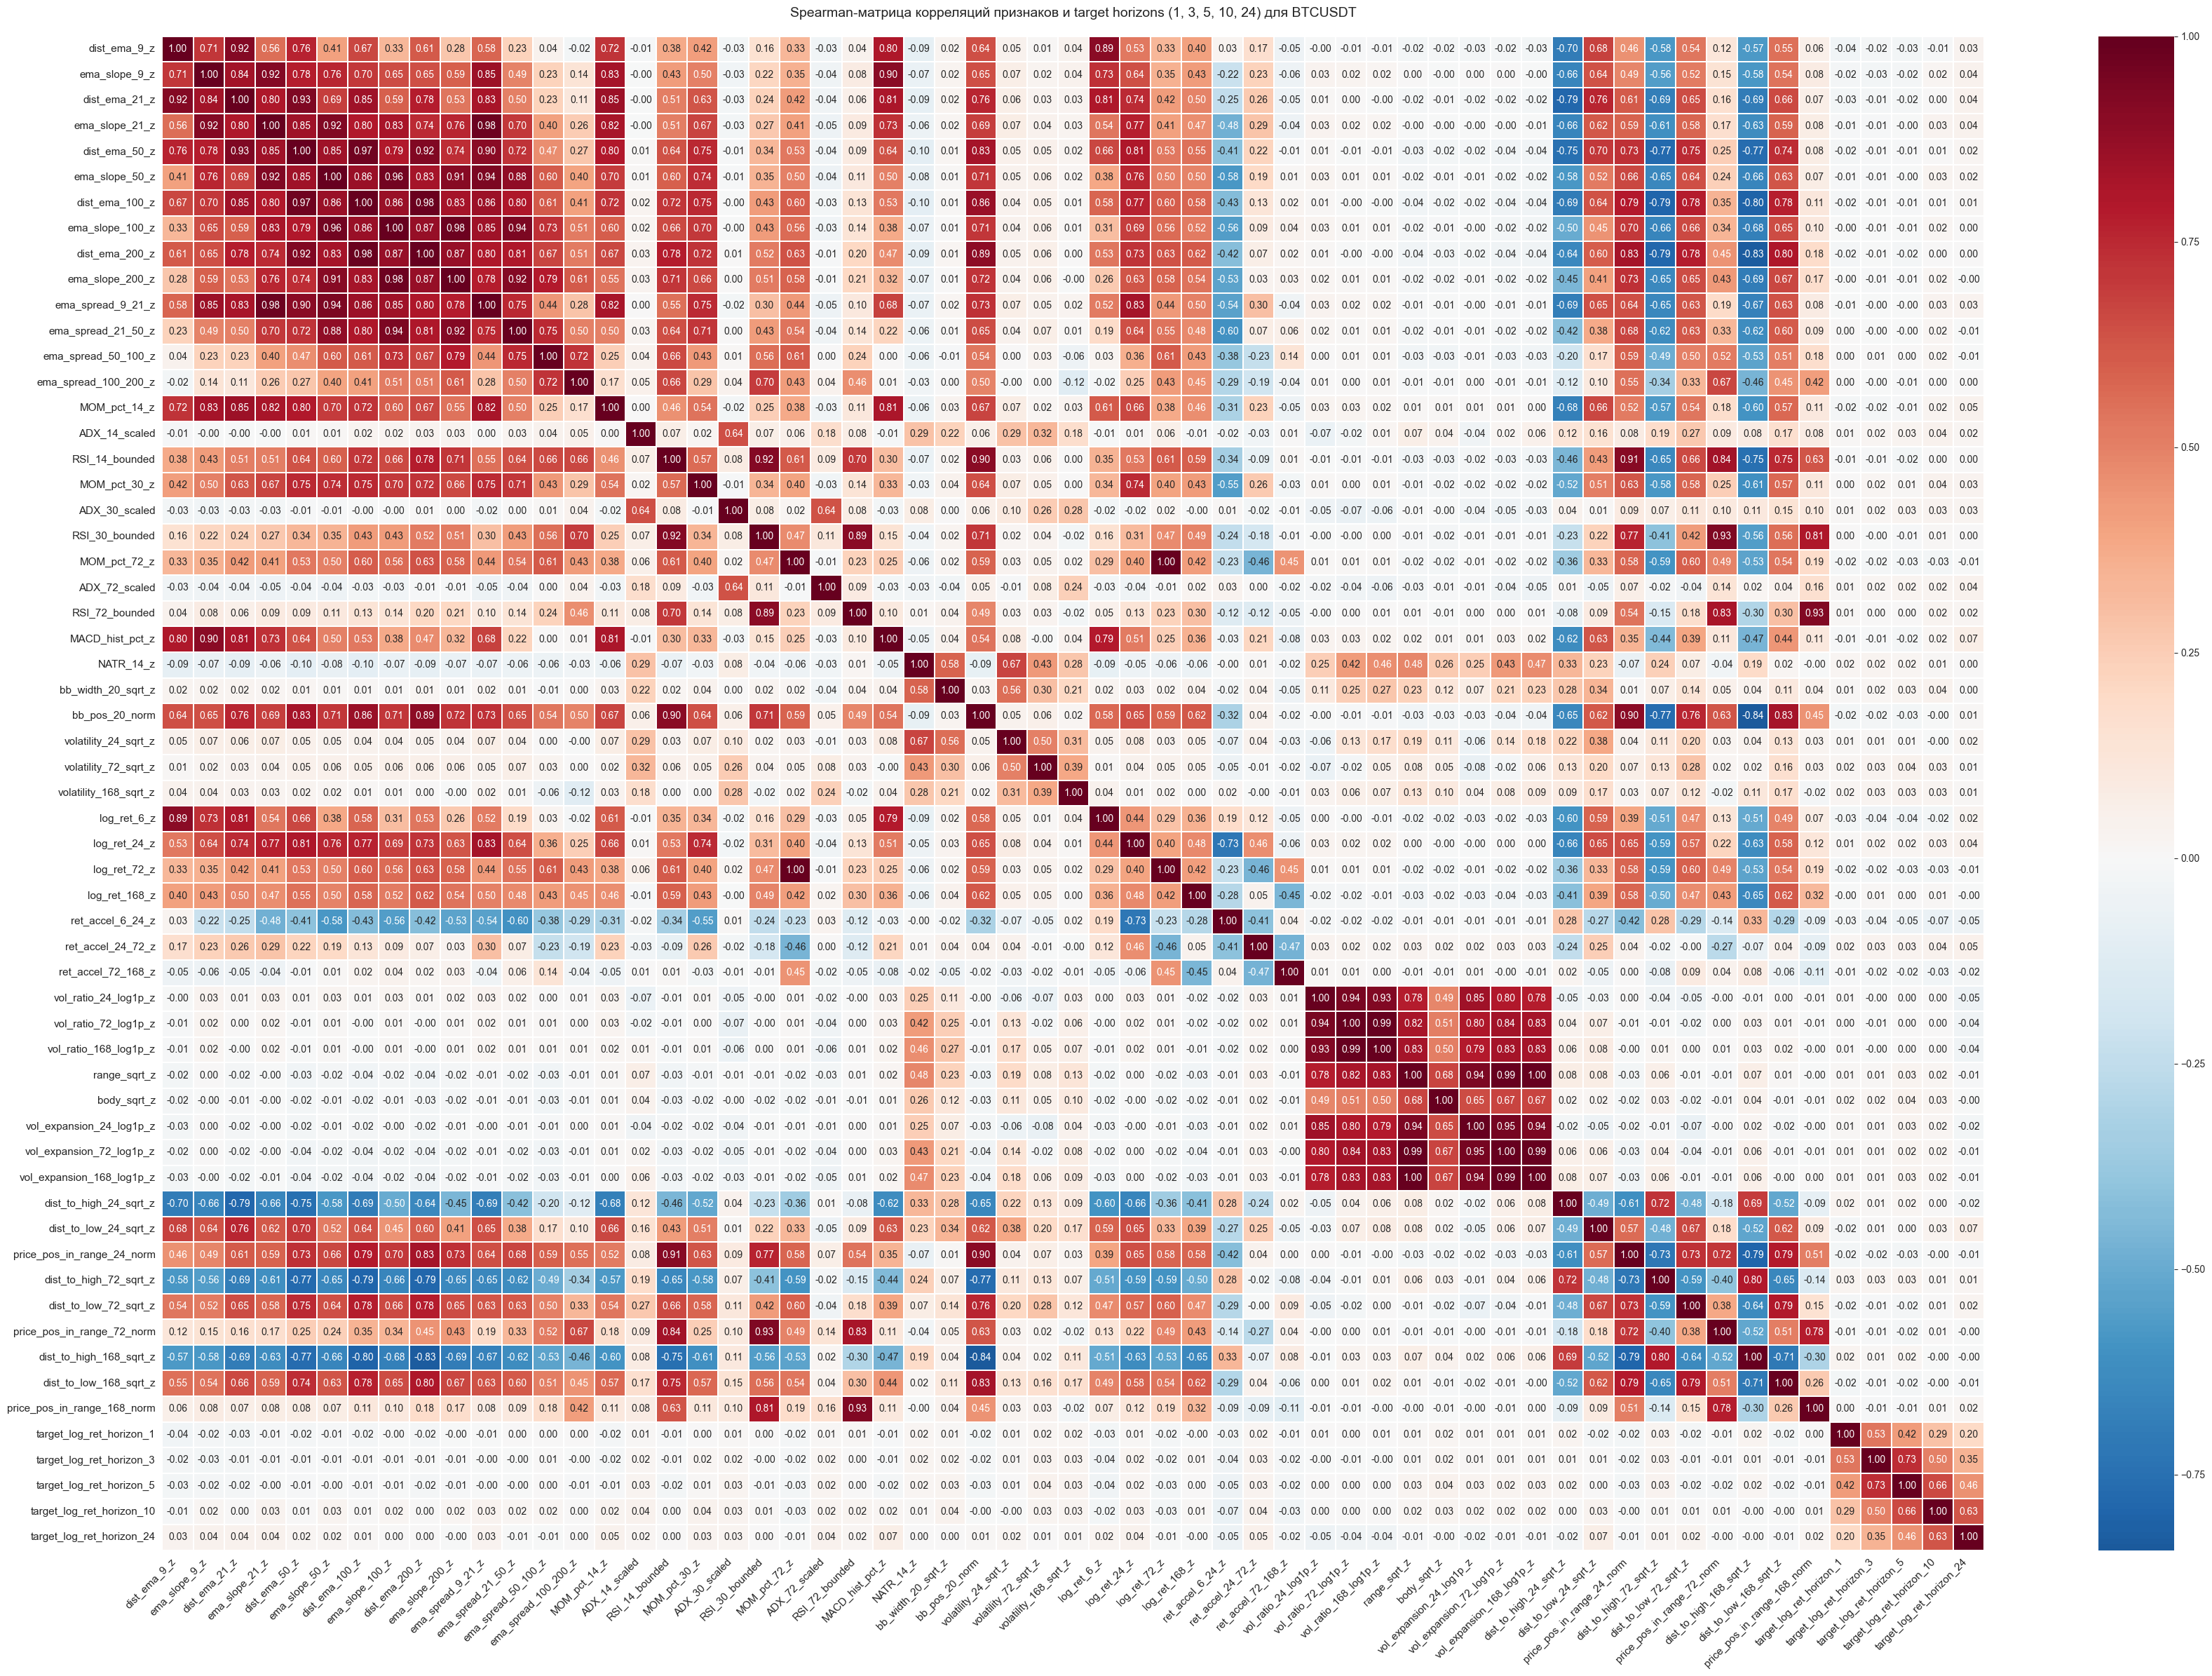

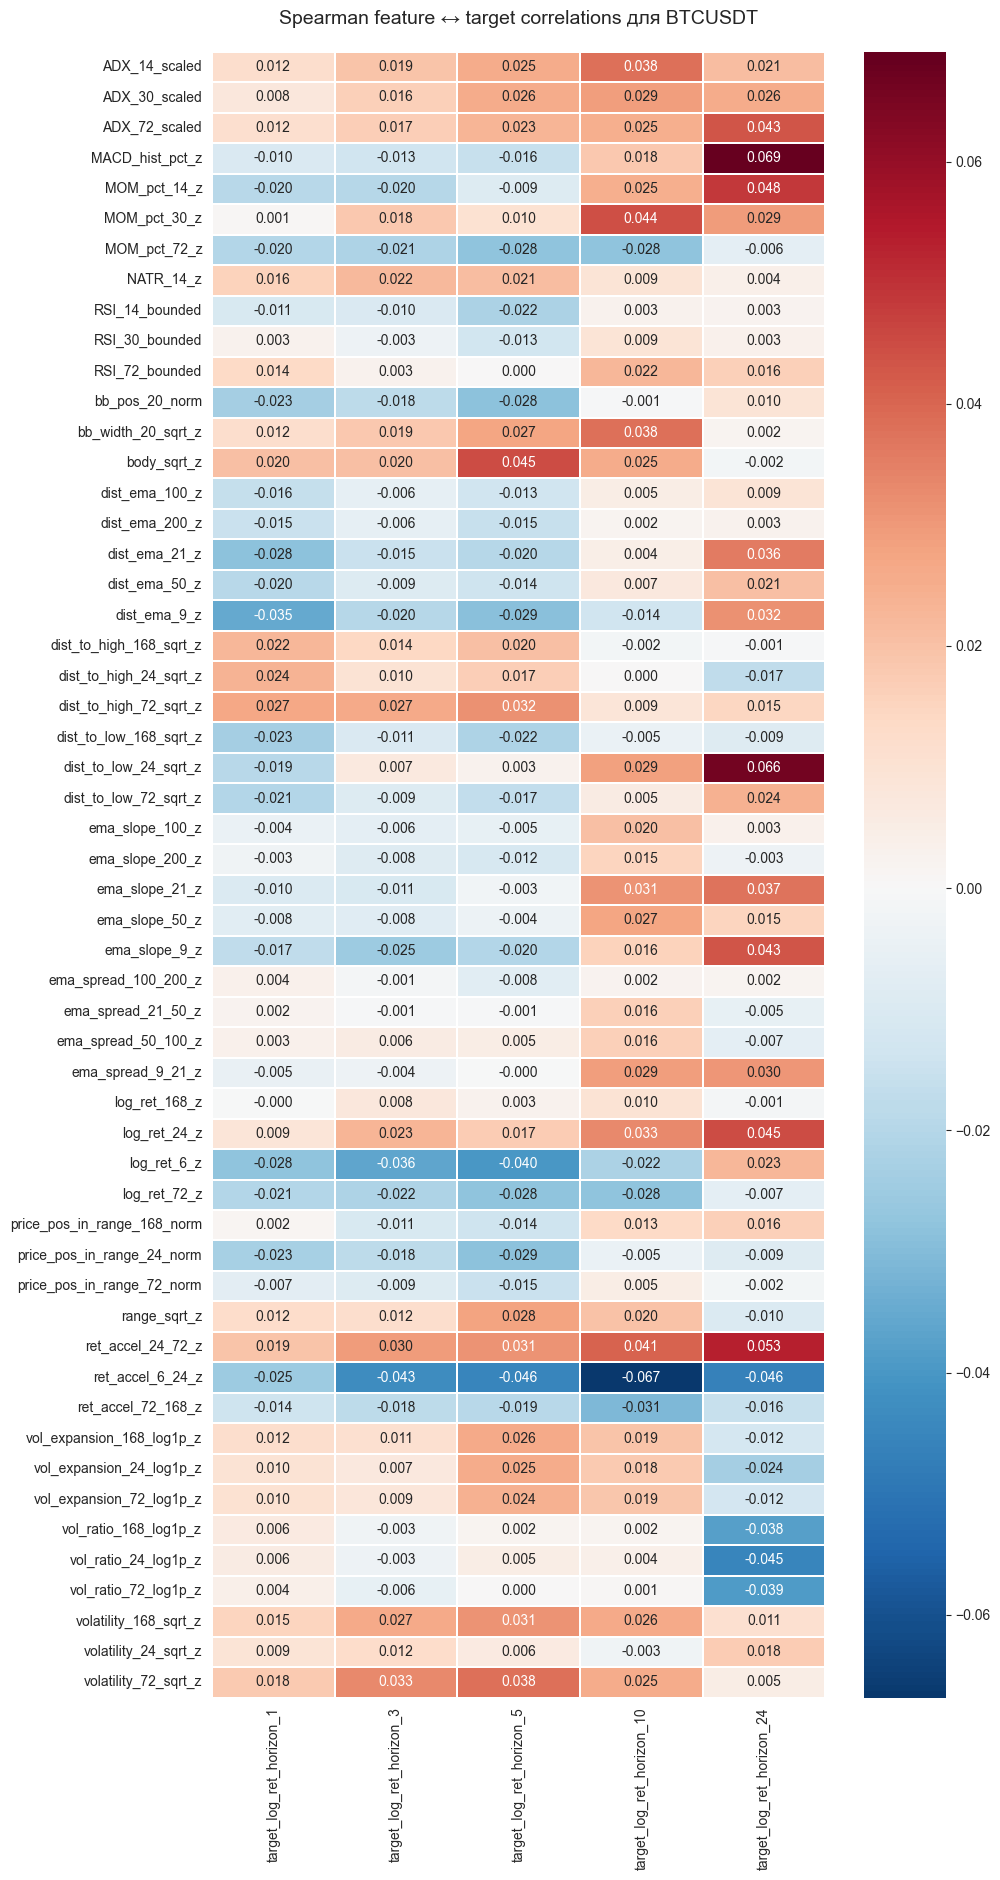

,target_log_ret_horizon_1,target_log_ret_horizon_3,target_log_ret_horizon_5,target_log_ret_horizon_10,target_log_ret_horizon_24,max_abs_corr
MACD_hist_pct_z,-0.010066,-0.013362,-0.015510,0.018235,0.069064,0.069064
ret_accel_6_24_z,-0.025424,-0.043077,-0.045514,-0.066837,-0.046472,0.066837
dist_to_low_24_sqrt_z,-0.019220,0.006527,0.002913,0.028680,0.066119,0.066119
ret_accel_24_72_z,0.019463,0.029636,0.031198,0.040717,0.053500,0.053500
MOM_pct_14_z,-0.019524,-0.019913,-0.009134,0.024680,0.048430,0.048430
vol_ratio_24_log1p_z,0.005775,-0.003267,0.004840,0.004068,-0.045390,0.045390
log_ret_24_z,0.008904,0.023040,0.017053,0.033284,0.044815,0.044815
body_sqrt_z,0.020465,0.020495,0.044798,0.025021,-0.001821,0.044798
MOM_pct_30_z,0.000824,0.018111,0.010177,0.044135,0.029306,0.044135
ema_slope_9_z,-0.017270,-0.025154,-0.020194,0.015666,0.043420,0.043420


In [53]:
corr_matrix = df_corr[cols_for_corr].corr(method="spearman")
target_corr_matrix = corr_matrix.loc[feature_cols, target_cols]

symbol_name = df_corr["symbol"].unique()[0]

# 1) Полная Spearman-матрица: признаки + все target horizons.
plt.figure(figsize=(35, 24))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=False,
    linewidths=0.3,
    linecolor="white",
    cbar=True,
)

plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.title(
    f"Spearman-матрица корреляций признаков и target horizons {HORIZONS_FOR_TARGET_CORR} для {symbol_name}",
    fontsize=14,
    pad=20,
)
plt.tight_layout()
plt.show()

# 2) Более читаемая матрица только feature ↔ target.
plt.figure(figsize=(10, max(8, len(feature_cols) * 0.35)))
sns.heatmap(
    target_corr_matrix.sort_index(),
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.3,
    linecolor="white",
    cbar=True,
)
plt.title(
    f"Spearman feature ↔ target correlations для {symbol_name}",
    fontsize=14,
    pad=20,
)
plt.tight_layout()
plt.show()

# 3) Таблица: признаки с максимальной absolute-correlation хотя бы по одному horizon.
top_target_corr = (
    target_corr_matrix
    .assign(max_abs_corr=target_corr_matrix.abs().max(axis=1))
    .sort_values("max_abs_corr", ascending=False)
)

display(top_target_corr.head(30))


In [54]:
import numpy as np
import pandas as pd


def build_target_columns(df, horizons=(1, 3, 5, 10, 24)):
    """
    Backward-compatible wrapper around train-safe grouped target construction.
    """
    return add_targets_grouped(df, horizons=horizons)


def get_feature_cols(df, meta_cols, target_cols):
    # Safety-net на случай, если EDA случайно запускается со старой transform-функцией.
    ema_level_cols = [
        col for col in df.columns
        if col.startswith("ema_")
        and not col.startswith(("ema_slope", "ema_spread"))
    ]

    forbidden_cols = [
        col for col in df.columns
        if col.startswith(("vol_ma_", "range_ma_", "MOM_"))
        or col == "MACD_hist"
    ]

    non_feature_cols = set(meta_cols) | {"phase"}

    feature_cols = [
        col for col in df.columns
        if col not in non_feature_cols
        and col not in target_cols
        and col not in ema_level_cols
        and col not in forbidden_cols
    ]

    return feature_cols


def feature_quality_report(
    df,
    meta_cols,
    horizons=(1, 3, 5, 10, 24),
    top_n=25,
    high_corr_threshold=0.85,
    corr_method="spearman",
):
    """
    EDA quality report for transformed/z-scored features.

    Uses Spearman correlation by default, matching the final feature-selection
    pipeline:
      - feature-target ranking uses Spearman correlation;
      - redundancy/pruning uses absolute Spearman correlation.
    """
    df = build_target_columns(df, horizons=horizons)

    target_cols = [f"target_log_ret_horizon_{h}" for h in horizons]
    feature_cols = get_feature_cols(df, meta_cols, target_cols)

    print("=" * 100)
    print("DATASET SUMMARY")
    print("=" * 100)
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")
    print(f"Features used: {len(feature_cols)}")
    print(f"Targets: {target_cols}")
    print(f"Correlation method: {corr_method}")
    print(f"Symbol: {df['symbol'].unique() if 'symbol' in df.columns else 'unknown'}")
    print(f"Time range: {df['timestamp'].min()} -> {df['timestamp'].max()}")

    print("\n" + "=" * 100)
    print("TARGET DISTRIBUTION")
    print("=" * 100)

    target_stats = df[target_cols].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    ).T

    target_stats["positive_ratio"] = (df[target_cols] > 0).mean()
    target_stats["abs_mean"] = df[target_cols].abs().mean()

    display(target_stats)

    print("\n" + "=" * 100)
    print("FEATURE BASIC QUALITY")
    print("=" * 100)

    feature_stats = pd.DataFrame(index=feature_cols)
    feature_stats["missing_ratio"] = df[feature_cols].isna().mean()
    feature_stats["inf_count"] = np.isinf(df[feature_cols].to_numpy()).sum(axis=0)
    feature_stats["mean"] = df[feature_cols].mean()
    feature_stats["std"] = df[feature_cols].std()
    feature_stats["min"] = df[feature_cols].min()
    feature_stats["p01"] = df[feature_cols].quantile(0.01)
    feature_stats["p50"] = df[feature_cols].quantile(0.50)
    feature_stats["p99"] = df[feature_cols].quantile(0.99)
    feature_stats["max"] = df[feature_cols].max()
    feature_stats["zero_std"] = feature_stats["std"] < 1e-12

    display(feature_stats.sort_values("std").head(20))
    display(feature_stats.sort_values("missing_ratio", ascending=False).head(20))

    print("\n" + "=" * 100)
    print("FEATURE ↔ TARGET CORRELATION")
    print("=" * 100)

    corr = df[feature_cols + target_cols].corr(method=corr_method)
    target_corr = corr.loc[feature_cols, target_cols]

    for target in target_cols:
        print(f"\nTop absolute {corr_method} correlations with {target}")
        display(
            target_corr[target]
            .abs()
            .sort_values(ascending=False)
            .head(top_n)
            .to_frame("abs_corr")
            .assign(raw_corr=target_corr[target])
        )

    print("\n" + "=" * 100)
    print("BEST TARGET BY MEAN ABS CORRELATION")
    print("=" * 100)

    target_power = pd.DataFrame({
        "mean_abs_corr": target_corr.abs().mean(),
        "max_abs_corr": target_corr.abs().max(),
        "features_abs_corr_gt_001": (target_corr.abs() > 0.01).sum(),
        "features_abs_corr_gt_002": (target_corr.abs() > 0.02).sum(),
        "features_abs_corr_gt_005": (target_corr.abs() > 0.05).sum(),
    }).sort_values("mean_abs_corr", ascending=False)

    display(target_power)

    print("\n" + "=" * 100)
    print("FEATURE MULTICOLLINEARITY")
    print("=" * 100)

    feature_corr = df[feature_cols].corr(method=corr_method).abs()

    upper = feature_corr.where(
        np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
    )

    high_corr_pairs = (
        upper.stack()
        .sort_values(ascending=False)
        .reset_index()
    )

    high_corr_pairs.columns = ["feature_1", "feature_2", "abs_corr"]
    high_corr_pairs = high_corr_pairs[
        high_corr_pairs["abs_corr"] >= high_corr_threshold
    ]

    print(f"Pairs with abs {corr_method} corr >= {high_corr_threshold}: {len(high_corr_pairs)}")
    display(high_corr_pairs.head(50))

    print("\n" + "=" * 100)
    print("FEATURE REDUNDANCY SCORE")
    print("=" * 100)

    redundancy = pd.DataFrame(index=feature_cols)
    redundancy["mean_abs_corr_with_other_features"] = (
        feature_corr.sum() - 1
    ) / (len(feature_cols) - 1)
    redundancy["max_abs_corr_with_other_feature"] = upper.max().combine(
        upper.T.max(), max
    )

    display(
        redundancy
        .sort_values("mean_abs_corr_with_other_features", ascending=False)
        .head(30)
    )

    print("\n" + "=" * 100)
    print("SUGGESTED FEATURE CANDIDATES")
    print("=" * 100)

    best_target = target_power.index[0]

    candidate_table = pd.DataFrame(index=feature_cols)
    candidate_table["abs_corr_with_best_target"] = target_corr[best_target].abs()
    candidate_table["raw_corr_with_best_target"] = target_corr[best_target]
    candidate_table["mean_abs_corr_with_other_features"] = redundancy[
        "mean_abs_corr_with_other_features"
    ]
    candidate_table["max_abs_corr_with_other_feature"] = redundancy[
        "max_abs_corr_with_other_feature"
    ]

    candidate_table["score"] = (
        candidate_table["abs_corr_with_best_target"]
        / (candidate_table["mean_abs_corr_with_other_features"] + 1e-6)
    )

    display(
        candidate_table
        .sort_values("score", ascending=False)
        .head(40)
    )

    return {
        "df": df,
        "feature_cols": feature_cols,
        "target_cols": target_cols,
        "target_corr": target_corr,
        "target_power": target_power,
        "feature_stats": feature_stats,
        "high_corr_pairs": high_corr_pairs,
        "redundancy": redundancy,
        "candidate_table": candidate_table,
        "corr_method": corr_method,
    }


In [55]:
report = feature_quality_report(
    df=df_z_score_indicators_asset_clean,
    meta_cols=meta_cols,
    horizons=(1, 3, 5, 10, 24),
    top_n=25,
    high_corr_threshold=0.85,
    corr_method="spearman",
)


DATASET SUMMARY
Rows: 5650
Columns: 67
Features used: 51
Targets: ['target_log_ret_horizon_1', 'target_log_ret_horizon_3', 'target_log_ret_horizon_5', 'target_log_ret_horizon_10', 'target_log_ret_horizon_24']
Correlation method: spearman
Symbol: ['BTCUSDT']
Time range: 2021-11-28 08:00:00+00:00 -> 2024-06-26 20:00:00+00:00

TARGET DISTRIBUTION


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,positive_ratio,abs_mean
target_log_ret_horizon_1,5650.0,0.000020,0.011354,-0.095873,-0.034074,-0.017492,-0.004054,0.000097,0.004183,0.017115,0.034831,0.081189,0.508850,0.007181
target_log_ret_horizon_3,5650.0,0.000060,0.019887,-0.142007,-0.061453,-0.031630,-0.007595,0.000031,0.008064,0.031870,0.059534,0.119079,0.501770,0.013001
target_log_ret_horizon_5,5650.0,0.000085,0.026061,-0.187036,-0.077874,-0.040880,-0.011065,0.000017,0.011152,0.042776,0.074676,0.143720,0.501062,0.017481
target_log_ret_horizon_10,5650.0,0.000147,0.036772,-0.220941,-0.105808,-0.057433,-0.015986,-0.000024,0.016422,0.058036,0.105743,0.175761,0.499292,0.025005
target_log_ret_horizon_24,5650.0,0.000316,0.059013,-0.347503,-0.176434,-0.095151,-0.027146,0.000273,0.030498,0.094444,0.151080,0.258201,0.503717,0.041538



FEATURE BASIC QUALITY


,missing_ratio,inf_count,mean,std,min,p01,p50,p99,max,zero_std
RSI_72_bounded,0.0,0,0.012651,0.139212,-0.401301,-0.298168,-0.005738,0.408460,0.576462,False
RSI_30_bounded,0.0,0,0.012895,0.197338,-0.684861,-0.455069,-0.008332,0.518595,0.772468,False
ADX_72_scaled,0.0,0,-0.400466,0.259812,-0.810679,-0.764782,-0.465487,0.376477,0.465758,False
RSI_14_bounded,0.0,0,0.011190,0.268626,-0.890327,-0.592383,-0.008412,0.662983,0.853930,False
price_pos_in_range_24_norm,0.0,0,0.008210,0.271070,-0.496275,-0.465019,-0.000051,0.474524,0.498703,False
price_pos_in_range_72_norm,0.0,0,0.016190,0.280010,-0.498092,-0.468927,0.020254,0.476606,0.498703,False
price_pos_in_range_168_norm,0.0,0,0.005838,0.295218,-0.498198,-0.467691,-0.046809,0.477400,0.498874,False
bb_pos_20_norm,0.0,0,0.001813,0.339042,-1.013551,-0.747033,-0.004078,0.770676,1.074415,False
ADX_30_scaled,0.0,0,-0.147417,0.381691,-0.761598,-0.678704,-0.232793,0.969555,1.328809,False
ADX_14_scaled,0.0,0,0.144196,0.507745,-0.707233,-0.573262,0.026437,1.622221,1.959806,False


,missing_ratio,inf_count,mean,std,min,p01,p50,p99,max,zero_std
dist_ema_9_z,0.0,0,0.004683,1.317754,-5.000000,-3.666999,-0.022586,3.878213,5.000000,False
ema_slope_9_z,0.0,0,0.018475,1.443389,-5.000000,-3.471784,-0.019677,3.579267,5.000000,False
dist_ema_21_z,0.0,0,0.003793,1.413122,-5.000000,-3.648129,-0.017365,3.913565,5.000000,False
ema_slope_21_z,0.0,0,0.020423,1.546420,-5.000000,-3.617895,-0.009010,3.792531,5.000000,False
dist_ema_50_z,0.0,0,-0.000619,1.496469,-5.000000,-3.691492,-0.005462,3.903612,5.000000,False
ema_slope_50_z,0.0,0,0.008465,1.629248,-5.000000,-3.737250,-0.000197,3.786373,5.000000,False
dist_ema_100_z,0.0,0,-0.006887,1.541440,-5.000000,-3.726802,-0.023400,4.037202,5.000000,False
ema_slope_100_z,0.0,0,-0.001581,1.672414,-5.000000,-3.727512,-0.038035,3.867292,5.000000,False
dist_ema_200_z,0.0,0,-0.016849,1.565417,-5.000000,-3.837339,-0.057282,4.109942,5.000000,False
ema_slope_200_z,0.0,0,-0.018851,1.703506,-5.000000,-3.767128,-0.090873,4.050975,5.000000,False


...

,feature_1,feature_2,abs_corr
0,range_sqrt_z,vol_expansion_168_log1p_z,0.997711
1,vol_expansion_72_log1p_z,vol_expansion_168_log1p_z,0.991871
2,range_sqrt_z,vol_expansion_72_log1p_z,0.990246
3,vol_ratio_72_log1p_z,vol_ratio_168_log1p_z,0.990065
4,dist_ema_100_z,dist_ema_200_z,0.982260
5,ema_slope_100_z,ema_slope_200_z,0.978173
6,ema_slope_21_z,ema_spread_9_21_z,0.975958
7,dist_ema_50_z,dist_ema_100_z,0.970530
8,ema_slope_50_z,ema_slope_100_z,0.963638
9,vol_expansion_24_log1p_z,vol_expansion_72_log1p_z,0.952504



FEATURE REDUNDANCY SCORE


,mean_abs_corr_with_other_features,max_abs_corr_with_other_feature
bb_pos_20_norm,0.447810,0.901989
dist_ema_200_z,0.445675,0.982260
dist_ema_100_z,0.442895,0.982260
dist_ema_50_z,0.433685,0.970530
price_pos_in_range_24_norm,0.424431,0.913508
dist_to_high_168_sqrt_z,0.415696,0.841966
ema_spread_9_21_z,0.412283,0.975958
RSI_14_bounded,0.409064,0.918917
ema_slope_50_z,0.405199,0.963638
dist_to_low_168_sqrt_z,0.403734,0.830548



SUGGESTED FEATURE CANDIDATES


,abs_corr_with_best_target,raw_corr_with_best_target,mean_abs_corr_with_other_features,max_abs_corr_with_other_feature,score
ADX_72_scaled,0.043085,0.043085,0.059812,0.639263,0.720322
ret_accel_24_72_z,0.053500,0.053500,0.129199,0.470543,0.414085
ADX_30_scaled,0.025854,0.025854,0.075007,0.641186,0.344684
vol_ratio_24_log1p_z,0.045390,-0.045390,0.135762,0.943818,0.334332
vol_ratio_72_log1p_z,0.039109,-0.039109,0.145068,0.990065,0.269587
vol_ratio_168_log1p_z,0.038050,-0.038050,0.147845,0.990065,0.257362
ret_accel_72_168_z,0.015600,-0.015600,0.061002,0.470543,0.255721
MACD_hist_pct_z,0.069064,0.069064,0.286626,0.904545,0.240954
ADX_14_scaled,0.021023,0.021023,0.087953,0.641186,0.239017
ret_accel_6_24_z,0.046472,-0.046472,0.227461,0.725858,0.204307


In [56]:
# Пример ручного feature-set обновлён под fixed stream/transform:
# MACD_hist -> MACD_hist_pct, старый absolute MOM больше не используется.
FEATURE_SET_240M_V2 = [
    "MACD_hist_pct_z",
    "ADX_72_scaled",
    "dist_to_low_24_sqrt_z",
    "volatility_168_sqrt_z",
    "ret_accel_6_24_z",
    "range_sqrt_z",
    "vol_ratio_24_log1p_z",
]

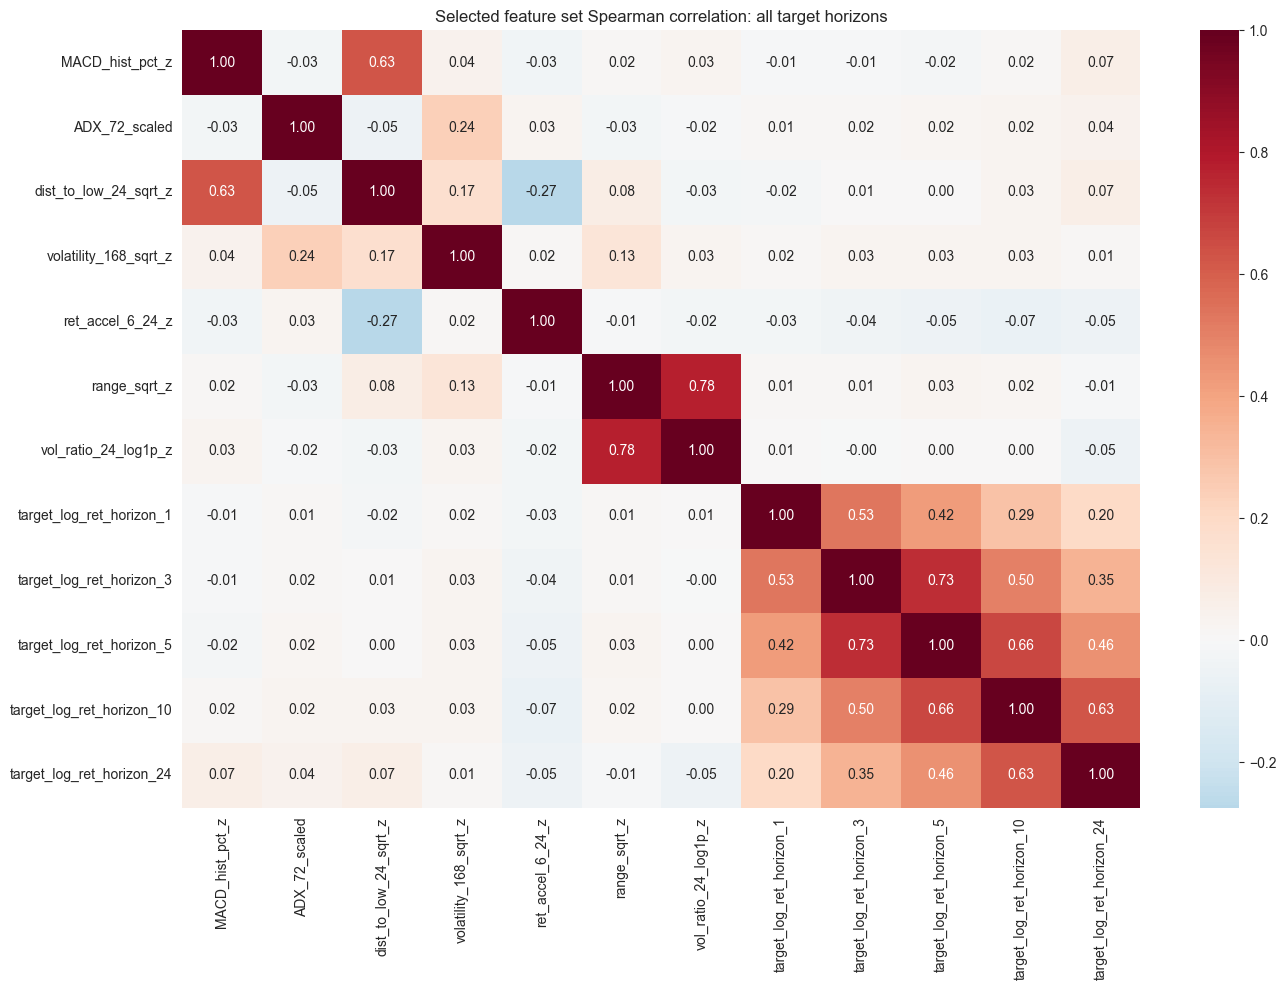

,target_log_ret_horizon_1,target_log_ret_horizon_3,target_log_ret_horizon_5,target_log_ret_horizon_10,target_log_ret_horizon_24
MACD_hist_pct_z,-0.010066,-0.013362,-0.015510,0.018235,0.069064
ADX_72_scaled,0.011722,0.016578,0.022956,0.024662,0.043085
dist_to_low_24_sqrt_z,-0.019220,0.006527,0.002913,0.028680,0.066119
volatility_168_sqrt_z,0.015001,0.026510,0.031252,0.026442,0.011050
ret_accel_6_24_z,-0.025424,-0.043077,-0.045514,-0.066837,-0.046472
range_sqrt_z,0.012266,0.011934,0.027757,0.020143,-0.009661
vol_ratio_24_log1p_z,0.005775,-0.003267,0.004840,0.004068,-0.045390


In [57]:
selected_feature_cols = [
    col for col in FEATURE_SET_240M_V2
    if col in report["df"].columns
]

missing_selected_cols = sorted(set(FEATURE_SET_240M_V2) - set(selected_feature_cols))
if missing_selected_cols:
    print("Missing selected features:", missing_selected_cols)

selected_cols = selected_feature_cols + report["target_cols"]

df_selected_corr = report["df"][selected_cols].corr(method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(
    df_selected_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
)
plt.title("Selected feature set Spearman correlation: all target horizons")
plt.tight_layout()
plt.show()

selected_target_corr = df_selected_corr.loc[selected_feature_cols, report["target_cols"]]
display(selected_target_corr)


## Export correlation artifacts

Следующий блок строит Spearman-корреляции по всем активам и всем `Z_WINDOWS_FOR_CORR`, сохраняет feature-target correlations, пары высоко коррелированных признаков и отдельные feature-feature matrices. Эти файлы можно отправить для анализа.

In [58]:
# =====================================================================
# Export Spearman correlation artifacts for external analysis / review
# =====================================================================
# Important methodology:
#   1. Indicators/z-scores are built on full chronological OHLCV per symbol.
#   2. Chronological phase is added AFTER feature engineering/dropna for each z_window.
#   3. Correlation targets are constructed strictly inside train rows only.
#   4. Spearman correlation is used to match the final feature-selection pipeline.

CORR_OUTPUT_DIR = Path("eda_correlation_artifacts")
CORR_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZONS_FOR_CORR = (1, 3, 5, 10, 24)
Z_WINDOWS_FOR_CORR = [24, 48, 72, 96, 168]
HIGH_CORR_THRESHOLD = 0.85
CORR_METHOD = "spearman"


def build_zscore_indicators_for_symbol(
    ohlcv_data: pd.DataFrame,
    symbol: str,
    z_window: int,
    config: dict,
    meta_cols: list[str],
    clip_value: float = 5.0,
) -> pd.DataFrame:
    df_symbol = (
        ohlcv_data[ohlcv_data["symbol"] == symbol]
        .sort_values("timestamp")
        .reset_index(drop=True)
        .copy()
    )

    indicators = stream_TA_lib(
        df=df_symbol,
        meta_cols=meta_cols,
        **config,
    )

    indicators = (
        indicators
        .dropna()
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    transformed = transform_indicators_df(
        df=indicators,
        meta_cols=meta_cols,
    )

    zscored = rolling_z_score_clip_df(
        df=transformed,
        meta_cols=meta_cols,
        window=z_window,
        clip_value=clip_value,
        shift_by_one=True,
    )

    return (
        zscored
        .dropna()
        .sort_values("timestamp")
        .reset_index(drop=True)
    )


def safe_feature_cols(df: pd.DataFrame, meta_cols: list[str], target_cols: list[str]) -> list[str]:
    ema_level_cols = [
        col for col in df.columns
        if col.startswith("ema_")
        and not col.startswith(("ema_slope", "ema_spread"))
    ]

    forbidden_cols = [
        col for col in df.columns
        if col.startswith(("vol_ma_", "range_ma_"))
        or (col.startswith("MOM_") and not col.startswith("MOM_pct"))
        or col == "MACD_hist"
    ]

    non_feature_cols = set(meta_cols) | {"phase"}

    return [
        col for col in df.columns
        if col not in non_feature_cols
        and col not in target_cols
        and col not in ema_level_cols
        and col not in forbidden_cols
    ]


feature_target_corr_rows = []
high_corr_pair_rows = []
feature_stats_rows = []
summary_rows = []

for z_window in Z_WINDOWS_FOR_CORR:
    print("=" * 100)
    print(f"Building {CORR_METHOD} correlation artifacts for z_window={z_window}")
    print("=" * 100)

    for sym in ALL_SYMBOLS:
        print(f"Processing {sym}...")

        # Build features from the full chronological symbol history, exactly as
        # production feature engineering does. Because rolling_z_score uses
        # shift_by_one=True, each row uses only past values.
        df_z_full = build_zscore_indicators_for_symbol(
            ohlcv_data=ohlcv_data,
            symbol=sym,
            z_window=z_window,
            config=CONFIG_FOR_INDICATORS,
            meta_cols=meta_cols,
            clip_value=CLIP_VALUE,
        )

        # Add train/val/test phase after z-score/dropna so row counts match the
        # actual feature-engineered dataset for this z_window.
        df_z_full = add_chronological_phase_by_symbol(
            df_z_full,
            val_bars=VAL_BARS,
            test_bars=TEST_BARS,
            embargo_bars=EMBARGO_BARS,
        )

        # Strictly train-only correlation analysis.
        df_z_train = df_z_full[df_z_full["phase"].eq("train")].copy()

        # Targets are constructed only inside train rows, so future returns do
        # not cross the train/validation boundary.
        df_corr_export = add_targets_grouped(df_z_train, horizons=HORIZONS_FOR_CORR)

        target_cols_export = [f"target_log_ret_horizon_{h}" for h in HORIZONS_FOR_CORR]
        feature_cols_export = safe_feature_cols(df_corr_export, meta_cols, target_cols_export)

        if not feature_cols_export:
            raise ValueError(f"No feature columns for {sym}, z_window={z_window}")

        corr_full = df_corr_export[feature_cols_export + target_cols_export].corr(method=CORR_METHOD)
        target_corr = corr_full.loc[feature_cols_export, target_cols_export]
        feature_corr = df_corr_export[feature_cols_export].corr(method=CORR_METHOD).abs()

        # Save full feature-feature corr matrix per symbol/z_window.
        matrix_path = CORR_OUTPUT_DIR / f"feature_corr_matrix_{sym}_z{z_window}.csv"
        feature_corr.to_csv(matrix_path)

        # Feature-target long table.
        for feature in feature_cols_export:
            for target in target_cols_export:
                raw_corr = float(target_corr.loc[feature, target])
                feature_target_corr_rows.append({
                    "symbol": sym,
                    "z_window": z_window,
                    "feature": feature,
                    "target": target,
                    "corr_method": CORR_METHOD,
                    "raw_corr": raw_corr,
                    "abs_corr": abs(raw_corr),
                })

        # High feature-feature correlation pairs.
        upper = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
        pairs = upper.stack().reset_index()
        pairs.columns = ["feature_1", "feature_2", "abs_corr"]
        pairs = pairs[pairs["abs_corr"] >= HIGH_CORR_THRESHOLD].sort_values("abs_corr", ascending=False)

        for _, row in pairs.iterrows():
            high_corr_pair_rows.append({
                "symbol": sym,
                "z_window": z_window,
                "feature_1": row["feature_1"],
                "feature_2": row["feature_2"],
                "corr_method": CORR_METHOD,
                "abs_corr": float(row["abs_corr"]),
            })

        # Feature basic stats.
        feature_stats = df_corr_export[feature_cols_export].describe(
            percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
        ).T
        feature_stats["missing_ratio"] = df_corr_export[feature_cols_export].isna().mean()
        feature_stats["zero_std"] = df_corr_export[feature_cols_export].std() < 1e-12
        feature_stats = feature_stats.reset_index().rename(columns={"index": "feature"})
        feature_stats["symbol"] = sym
        feature_stats["z_window"] = z_window
        feature_stats_rows.extend(feature_stats.to_dict("records"))

        stacked_upper = upper.stack()
        summary_rows.append({
            "symbol": sym,
            "z_window": z_window,
            "phase_used": "train",
            "corr_method": CORR_METHOD,
            "n_rows": len(df_corr_export),
            "n_features": len(feature_cols_export),
            "n_high_corr_pairs_ge_085": len(pairs),
            "max_abs_feature_corr": float(stacked_upper.max()) if len(stacked_upper) else np.nan,
            "mean_abs_feature_corr": float(stacked_upper.mean()) if len(stacked_upper) else np.nan,
            "timestamp_min": df_corr_export["timestamp"].min(),
            "timestamp_max": df_corr_export["timestamp"].max(),
        })

feature_target_corr_long = pd.DataFrame(feature_target_corr_rows)
high_corr_pairs_all = pd.DataFrame(high_corr_pair_rows)
feature_stats_all = pd.DataFrame(feature_stats_rows)
corr_export_summary = pd.DataFrame(summary_rows)

# Sort useful tables.
feature_target_corr_long = feature_target_corr_long.sort_values(
    ["z_window", "symbol", "target", "abs_corr"],
    ascending=[True, True, True, False],
).reset_index(drop=True)

high_corr_pairs_all = high_corr_pairs_all.sort_values(
    ["z_window", "symbol", "abs_corr"],
    ascending=[True, True, False],
).reset_index(drop=True)

# Save CSV artifacts.
feature_target_corr_long.to_csv(CORR_OUTPUT_DIR / "feature_target_corr_long.csv", index=False)
high_corr_pairs_all.to_csv(CORR_OUTPUT_DIR / "high_feature_corr_pairs_ge_085.csv", index=False)
feature_stats_all.to_csv(CORR_OUTPUT_DIR / "feature_stats_all.csv", index=False)
corr_export_summary.to_csv(CORR_OUTPUT_DIR / "corr_export_summary.csv", index=False)

def make_excel_safe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Excel/openpyxl не поддерживает timezone-aware datetime.
    Конвертируем такие колонки в timezone-naive UTC.
    """
    out = df.copy()

    for col in out.columns:
        if pd.api.types.is_datetime64_any_dtype(out[col]):
            # Если колонка timezone-aware, убираем timezone
            try:
                if getattr(out[col].dt, "tz", None) is not None:
                    out[col] = out[col].dt.tz_convert(None)
            except TypeError:
                out[col] = out[col].dt.tz_localize(None)

        # На случай object-колонок с Timestamp внутри
        elif out[col].dtype == "object":
            if out[col].map(lambda x: getattr(x, "tzinfo", None) is not None if pd.notna(x) else False).any():
                out[col] = out[col].map(
                    lambda x: x.tz_convert(None) if hasattr(x, "tz_convert") and x.tzinfo is not None else x
                )

    return out


corr_export_summary_excel = make_excel_safe(corr_export_summary)
feature_target_corr_long_excel = make_excel_safe(feature_target_corr_long)
high_corr_pairs_all_excel = make_excel_safe(high_corr_pairs_all)
feature_stats_all_excel = make_excel_safe(feature_stats_all)

# Excel summary file for convenient sharing.
excel_path = CORR_OUTPUT_DIR / "eda_correlation_report.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    corr_export_summary_excel.to_excel(writer, sheet_name="summary", index=False)
    feature_target_corr_long_excel.head(5000).to_excel(writer, sheet_name="feature_target_top", index=False)
    high_corr_pairs_all_excel.head(5000).to_excel(writer, sheet_name="high_corr_pairs", index=False)
    feature_stats_all_excel.head(5000).to_excel(writer, sheet_name="feature_stats", index=False)

print("Saved correlation artifacts to:", CORR_OUTPUT_DIR.resolve())
print("Main files:")
print("-", (CORR_OUTPUT_DIR / "eda_correlation_report.xlsx").resolve())
print("-", (CORR_OUTPUT_DIR / "feature_target_corr_long.csv").resolve())
print("-", (CORR_OUTPUT_DIR / "high_feature_corr_pairs_ge_085.csv").resolve())
print("-", (CORR_OUTPUT_DIR / "corr_export_summary.csv").resolve())

display(corr_export_summary)
display(feature_target_corr_long.head(30))
display(high_corr_pairs_all.head(30))


Building spearman correlation artifacts for z_window=24
Processing BTCUSDT...
Processing DOGEUSDT...
Processing ETHUSDT...
Processing SOLUSDT...
Processing XRPUSDT...
Building spearman correlation artifacts for z_window=48
Processing BTCUSDT...
Processing DOGEUSDT...
Processing ETHUSDT...
Processing SOLUSDT...
Processing XRPUSDT...
Building spearman correlation artifacts for z_window=72
Processing BTCUSDT...
Processing DOGEUSDT...
Processing ETHUSDT...
Processing SOLUSDT...
Processing XRPUSDT...
Building spearman correlation artifacts for z_window=96
Processing BTCUSDT...
Processing DOGEUSDT...
Processing ETHUSDT...
Processing SOLUSDT...
Processing XRPUSDT...
Building spearman correlation artifacts for z_window=168
Processing BTCUSDT...
Processing DOGEUSDT...
Processing ETHUSDT...
Processing SOLUSDT...
Processing XRPUSDT...
Saved correlation artifacts to: D:\PythonProjects\VKR\eda\eda_correlation_artifacts
Main files:
- D:\PythonProjects\VKR\eda\eda_correlation_artifacts\eda_correlatio

,symbol,z_window,phase_used,corr_method,n_rows,n_features,n_high_corr_pairs_ge_085,max_abs_feature_corr,mean_abs_feature_corr,timestamp_min,timestamp_max
0,BTCUSDT,24,train,spearman,5649,54,44,0.999968,0.279023,2021-11-28 08:00:00+00:00,2024-06-26 16:00:00+00:00
1,DOGEUSDT,24,train,spearman,5649,54,49,0.999909,0.288013,2021-11-28 08:00:00+00:00,2024-06-26 16:00:00+00:00
2,ETHUSDT,24,train,spearman,5649,54,52,0.999949,0.287915,2021-11-28 08:00:00+00:00,2024-06-26 16:00:00+00:00
3,SOLUSDT,24,train,spearman,5649,54,51,0.999883,0.287750,2021-11-28 08:00:00+00:00,2024-06-26 16:00:00+00:00
4,XRPUSDT,24,train,spearman,5649,54,46,0.999957,0.285840,2021-11-28 08:00:00+00:00,2024-06-26 16:00:00+00:00
5,BTCUSDT,48,train,spearman,5625,54,59,0.999931,0.292182,2021-12-02 08:00:00+00:00,2024-06-26 16:00:00+00:00
6,DOGEUSDT,48,train,spearman,5625,54,60,0.999856,0.301120,2021-12-02 08:00:00+00:00,2024-06-26 16:00:00+00:00
7,ETHUSDT,48,train,spearman,5625,54,60,0.999910,0.299211,2021-12-02 08:00:00+00:00,2024-06-26 16:00:00+00:00
8,SOLUSDT,48,train,spearman,5625,54,62,0.999771,0.301381,2021-12-02 08:00:00+00:00,2024-06-26 16:00:00+00:00
9,XRPUSDT,48,train,spearman,5625,54,60,0.999902,0.291593,2021-12-02 08:00:00+00:00,2024-06-26 16:00:00+00:00


,symbol,z_window,feature,target,corr_method,raw_corr,abs_corr
0,BTCUSDT,24,dist_ema_9_z,target_log_ret_horizon_1,spearman,-0.035461,0.035461
1,BTCUSDT,24,dist_ema_21_z,target_log_ret_horizon_1,spearman,-0.028191,0.028191
2,BTCUSDT,24,log_ret_6_z,target_log_ret_horizon_1,spearman,-0.027833,0.027833
3,BTCUSDT,24,dist_to_high_72_sqrt_z,target_log_ret_horizon_1,spearman,0.026936,0.026936
4,BTCUSDT,24,ret_accel_6_24_z,target_log_ret_horizon_1,spearman,-0.025470,0.025470
5,BTCUSDT,24,dist_to_high_24_sqrt_z,target_log_ret_horizon_1,spearman,0.023808,0.023808
6,BTCUSDT,24,dist_to_low_168_sqrt_z,target_log_ret_horizon_1,spearman,-0.023560,0.023560
7,BTCUSDT,24,bb_pos_20_norm,target_log_ret_horizon_1,spearman,-0.023359,0.023359
8,BTCUSDT,24,price_pos_in_range_24_norm,target_log_ret_horizon_1,spearman,-0.023045,0.023045
9,BTCUSDT,24,dist_to_high_168_sqrt_z,target_log_ret_horizon_1,spearman,0.022252,0.022252


,symbol,z_window,feature_1,feature_2,corr_method,abs_corr
0,BTCUSDT,24,MOM_pct_72_z,log_ret_72_z,spearman,0.999968
1,BTCUSDT,24,range_sqrt_z,vol_expansion_168_log1p_z,spearman,0.997711
2,BTCUSDT,24,vol_expansion_72_log1p_z,vol_expansion_168_log1p_z,spearman,0.991871
3,BTCUSDT,24,range_sqrt_z,vol_expansion_72_log1p_z,spearman,0.990246
4,BTCUSDT,24,vol_ratio_72_log1p_z,vol_ratio_168_log1p_z,spearman,0.990065
5,BTCUSDT,24,dist_ema_100_z,dist_ema_200_z,spearman,0.982264
6,BTCUSDT,24,ema_slope_100_z,ema_slope_200_z,spearman,0.978178
7,BTCUSDT,24,ema_slope_21_z,ema_spread_9_21_z,spearman,0.975963
8,BTCUSDT,24,dist_ema_50_z,dist_ema_100_z,spearman,0.970535
9,BTCUSDT,24,ema_slope_50_z,ema_slope_100_z,spearman,0.963644
